# 🎨 Generative Models — VAEs, GANs & Diffusion From the Ground Up

> **What you'll learn:** what it means to learn $p(x)$; how an autoencoder becomes a **VAE** (the ELBO, the reparameterization trick, the Gaussian KL, the β trade-off and posterior collapse); how **GANs** play a minimax game, why they are unstable and what **mode collapse** looks like; how **diffusion models** noise and denoise images (DDPM, noise schedules, ε-prediction, the link to score matching); how **DDIM** samples 40× faster and **classifier-free guidance** trades diversity for fidelity; how **latent diffusion** and text encoders power Stable Diffusion, and what flow matching changes; how to **evaluate** generators (FID and its pitfalls, IS, precision/recall); and how to use them **responsibly**. Every idea is measured on real Fashion-MNIST with small models trained on a laptop.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Production Agents: Observability, Reliability & Cost](../16_Agentic_AI/08_Production_Agents_Observability_Reliability_Cost.ipynb) (previous notebook in the study plan) · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) (training loops, `nn.Module`, MPS) · [CNNs and Transfer Learning](../06_Computer_Vision/02_CNNs_and_Transfer_Learning.ipynb) (convolutions, BatchNorm, skip connections) · [Statistics and Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (Gaussians, expectations, KL divergence) |
| **Tested with** | Python 3.12 · torch 2.14 · torchvision 0.29 · diffusers 0.40 · transformers 5.17 · scikit-learn 1.9 · scipy 1.18 · pandas 3.0 · Apple Silicon GPU (MPS) |
| **Interview relevance** | ⭐⭐⭐ High — "VAE vs GAN vs diffusion?", "derive the ELBO", "reparameterization trick", "why are GANs unstable / what is mode collapse?", "how is a diffusion model trained and sampled?", "DDPM vs DDIM", "classifier-free guidance", "why latent diffusion?", "how does text conditioning work?", "FID and its pitfalls", "flow matching", design an image generator |

**🧩 This notebook opens the Multimodal & Generative Models module (3 notebooks):**

| # | Notebook | Focus |
|---|---|---|
| 01 | **Generative Models: VAEs, GANs & Diffusion** (you are here) | how image generators work, trained and measured |
| 02 | [Vision-Language Models & Multimodal RAG](02_Vision_Language_Models_and_Multimodal_RAG.ipynb) | CLIP, small VLMs, searching and answering over images |
| 03 | [Speech AI & Voice Agents](03_Speech_AI_and_Voice_Agents.ipynb) | speech recognition, text-to-speech, voice pipelines |

## 🤔 What Is a Generative Model?

Imagine two art students looking at 60,000 photos of clothes.

- The **critic** learns to answer *"is this a sneaker or a sandal?"*. That is a **discriminative** model: it learns $p(y \mid x)$, the label given the image.
- The **painter** learns to *produce new photos* that look like they came from the same pile. That is a **generative** model: it learns $p(x)$, the distribution of the images themselves, so it can **sample** new ones (and often score how likely an image is).

```
  discriminative:  image ──► [ classifier ] ──► "Sneaker (97%)"          learns p(y | x)
  generative:      noise ──► [ generator  ] ──► a brand-new sneaker image learns p(x)   (or p(x | y="Sneaker"))
```

Painting is much harder than criticising. A 28×28 grayscale image has 784 numbers, and the model must capture how *all of them* move together: where the sole is, how bright the laces are, which shapes never occur.

The families you will build here differ in **how** they learn that distribution:

- **VAE (variational autoencoder):** compress an image to a few numbers (a **latent** code), then decode back, trained so that random codes decode to sensible images.
- **GAN (generative adversarial network):** a generator and a discriminator play forger-versus-detective.
- **Diffusion model:** learn to remove a little noise at a time; start from pure noise and denoise step by step until an image appears.

## 🎯 Why It Matters

- **Image, video, audio and 3-D generation products are built on these ideas.** Stable Diffusion, FLUX, Imagen, Midjourney-style systems and most video generators are diffusion or flow-matching models. They run in a compressed latent space learned by a VAE-like autoencoder, and GAN-style adversarial losses still sharpen those autoencoders and distil fast samplers.
- **AI engineers are asked to ship them, not just call them.** You'll pick a model and a licence, choose steps and guidance scale for a latency budget, fine-tune on product photos, add safety filters and provenance, and measure quality honestly.
- **The maths shows up in unexpected places.** The ELBO powers VAEs and latent-variable models, KL terms appear in RLHF, and "denoise a corrupted input" is also how BERT and masked autoencoders learn.
- **In interviews** generative modelling is a standard ML-breadth topic: *"compare VAEs, GANs and diffusion"*, *"derive the ELBO"*, *"why the reparameterization trick?"*, *"what is mode collapse?"*, *"how does classifier-free guidance work?"*, *"why is latent diffusion cheaper?"*, *"what's wrong with FID?"*, plus system-design rounds such as *"design an on-device image generator"*.

## ✅ By the End You Can

- [ ] Explain generative vs discriminative models, likelihood-based vs implicit models, and the trade-offs of the VAE, GAN, flow and diffusion families
- [ ] Derive the ELBO, implement the reparameterization trick and the Gaussian KL, and diagnose the β trade-off and posterior collapse
- [ ] Train a DCGAN, explain the minimax and non-saturating losses, and demonstrate mode collapse
- [ ] Implement the DDPM forward process and noise schedules, train a small U-Net to predict noise, and sample with DDPM, DDIM and classifier-free guidance
- [ ] Explain latent diffusion, CLIP text conditioning, cross-attention and flow matching, and run a small text-to-image pipeline when memory allows
- [ ] Evaluate generators with a from-scratch Fréchet distance, precision/recall and class accuracy, knowing each metric's pitfalls and the responsible-use obligations

## 📋 Table of Contents

1. [What Generative Models Do](#1.-What-Generative-Models-Do-🟢)
2. [From Autoencoders to VAEs](#2.-From-Autoencoders-to-VAEs-🟡)
3. [The β Trade-off and Posterior Collapse](#3.-The-β-Trade-off-and-Posterior-Collapse-🟡)
4. [GANs: The Minimax Game and Mode Collapse](#4.-GANs:-The-Minimax-Game-and-Mode-Collapse-🟡)
5. [DCGAN on Fashion-MNIST and Conditional GANs](#5.-DCGAN-on-Fashion-MNIST-and-Conditional-GANs-🟡)
6. [Diffusion: The Forward Process and Noise Schedules](#6.-Diffusion:-The-Forward-Process-and-Noise-Schedules-🟡)
7. [Training and Sampling a DDPM](#7.-Training-and-Sampling-a-DDPM-🔴)
8. [Evaluating Generative Models: FID, IS, Precision and Recall](#8.-Evaluating-Generative-Models:-FID,-IS,-Precision-and-Recall-🟡)
9. [Faster Sampling With DDIM](#9.-Faster-Sampling-With-DDIM-🟡)
10. [Classifier-Free Guidance](#10.-Classifier-Free-Guidance-🔴)
11. [Latent Diffusion, Text-to-Image, and Flow Matching](#11.-Latent-Diffusion,-Text-to-Image,-and-Flow-Matching-🔴)
12. [Responsible Use: Licences, Deepfakes, Watermarks, Provenance](#12.-Responsible-Use:-Licences,-Deepfakes,-Watermarks,-Provenance-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Generate-Fashion-MNIST-on-a-Laptop-Budget) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- **Hardware.** The notebook picks Apple's GPU (**MPS**), then CUDA, then CPU. Every model trained here is small (at most 1.1 M parameters), so it trains on a laptop. On a CPU-only machine the same training steps take several times longer; lower `BUDGET_STEPS` if you are in a hurry (samples get worse).
- **Run time.** About 7–8 minutes top to bottom on an Apple Silicon laptop: the saved outputs took 7.3 minutes, including the text-to-image demo, and the three budget-matched models (`BUDGET_STEPS = 3000` each) take about 3 of those minutes. If memory runs short and the machine starts swapping, expect 3–4× longer (runs took 25–30 minutes while other heavy jobs shared the laptop). The project's last cell prints the total run time and peak memory.
- **Downloads.** Fashion-MNIST (~30 MB, once, into `_outputs/data/`). Section 11 downloads the fp16 weights of the small text-to-image model `nota-ai/bk-sdm-tiny` (~1.06 GB, into the Hugging Face cache) **only if** your machine has at least `T2I_MIN_FREE_GB` of free memory; otherwise it prints an honest skip message.
- **Memory.** Measured peak: 3.7 GB of GPU (unified) memory with the text-to-image cell, about 2.2 GB without it; the Python process itself stays under 1 GB. Large objects are deleted between sections.
- **Data licence.** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) is © Zalando SE, released under the MIT licence: 70,000 28×28 grayscale product photos in 10 classes.
- The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "torch>=2.5" "torchvision>=0.20" "diffusers>=0.35" "transformers>=4.50" "scikit-learn>=1.5" "scipy>=1.13" pandas matplotlib psutil

import os

os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")   # keep download progress bars out of saved outputs

import copy
import gc
import math
import resource
import sys
import time
from pathlib import Path

import diffusers
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
import scipy.linalg
import scipy.stats
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from diffusers import DDIMScheduler, DDPMScheduler
from sklearn.decomposition import PCA
from torchvision import datasets
from torchvision.utils import make_grid

NOTEBOOK_START = time.perf_counter()
print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | torchvision {torchvision.__version__} | diffusers {diffusers.__version__} | "
      f"scikit-learn {sklearn.__version__} | scipy {scipy.__version__} | pandas {pd.__version__} | matplotlib {matplotlib.__version__}")

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ No GPU found: the fixed time budgets will buy far fewer training steps on CPU, so expect weaker samples.")
print(f"device: {DEVICE} | total RAM {psutil.virtual_memory().total / 1e9:.0f} GB, currently free {psutil.virtual_memory().available / 1e9:.1f} GB")

SEED = 42
BUDGET_STEPS = 3000         # the SAME training budget (3,000 steps × 128 images ≈ 7 epochs) for the diffusion model (§7) and the project's CVAE and cGAN
N_EVAL = 500                # generated images per evaluation in sections 8–10 (50 per class)
T2I_MIN_FREE_GB = 6.0       # section 11 runs the text-to-image pipeline only with at least this much free memory
OUTPUT_DIR = Path("_outputs")
DATA_DIR = OUTPUT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)


def seed_everything(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "mps":
        torch.mps.manual_seed(seed)


def sync():
    """GPU work is asynchronous: wait for it before reading a timer."""
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    elif DEVICE.type == "cuda":
        torch.cuda.synchronize()


PEAK = {"device_gb": 0.0}


def device_memory_gb():
    if DEVICE.type == "mps":
        return torch.mps.driver_allocated_memory() / 1e9
    if DEVICE.type == "cuda":
        return torch.cuda.max_memory_reserved() / 1e9
    return 0.0


def free_memory():
    """Record peak GPU memory, then release cached blocks between sections."""
    PEAK["device_gb"] = max(PEAK["device_gb"], device_memory_gb())
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()


def n_params(module):
    return sum(p.numel() for p in module.parameters())


def show_grid(images, nrow=10, title=None, ax=None, value_range=(-1.0, 1.0)):
    """Plot a batch of (N, 1, 28, 28) images as one grid."""
    grid = make_grid(images.detach().float().cpu().clamp(*value_range), nrow=nrow, normalize=True,
                     value_range=value_range, pad_value=1.0)
    if ax is None:
        rows = math.ceil(len(images) / nrow)
        _, ax = plt.subplots(figsize=(0.62 * nrow, 0.62 * rows + 0.35))
    ax.imshow(grid[0], cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def check(name, got, expected, hint="", atol=1e-6, rtol=1e-5):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def to_np(v):
        return v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else np.asarray(v)

    def close(a, b):
        if isinstance(b, (str, bool)) or isinstance(a, (str, bool)):
            return a == b
        if isinstance(b, (tuple, list)) and isinstance(a, (tuple, list)) and any(isinstance(x, (tuple, list, torch.Tensor)) for x in b):
            return len(a) == len(b) and all(close(x, y) for x, y in zip(a, b))
        a_arr, b_arr = to_np(a), to_np(b)
        if a_arr.shape != b_arr.shape:
            return False
        return bool(np.allclose(a_arr.astype(np.float64), b_arr.astype(np.float64), atol=atol, rtol=rtol))

    assert close(got, expected), f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


# ── Fashion-MNIST: 55,000 train / 5,000 validation (carved from the official train set) / 10,000 test (used once, in the project)
train_full = datasets.FashionMNIST(DATA_DIR, train=True, download=True)
test_full = datasets.FashionMNIST(DATA_DIR, train=False, download=True)
CLASSES = train_full.classes
split = torch.randperm(len(train_full), generator=torch.Generator().manual_seed(SEED))
X_train_u8, y_train = train_full.data[split[:55_000]], train_full.targets[split[:55_000]]
X_val_u8, y_val = train_full.data[split[55_000:]], train_full.targets[split[55_000:]]
X_test_u8, y_test = test_full.data, test_full.targets
X_train_dev, y_train_dev = X_train_u8.to(DEVICE), y_train.to(DEVICE)     # 43 MB of uint8 on the device → fast random batches


def to_sym(images_u8):
    """uint8 (N, 28, 28) in 0..255 → float (N, 1, 28, 28) in [-1, 1] (the range GANs and diffusion models use)."""
    return images_u8.float().div(127.5).sub(1.0).unsqueeze(1)


def to_unit(images_u8):
    """uint8 (N, 28, 28) → float (N, 1, 28, 28) in [0, 1] (the range the VAE's Bernoulli decoder uses)."""
    return images_u8.float().div(255.0).unsqueeze(1)


def epoch_batches(n, batch_size, generator):
    """Yield shuffled index batches (on DEVICE) covering 0..n-1 once."""
    order = torch.randperm(n, generator=generator)
    for start in range(0, n - batch_size + 1, batch_size):
        yield order[start:start + batch_size].to(DEVICE)


seed_everything(SEED)
print(f"train {len(X_train_u8):,} | validation {len(X_val_u8):,} | test {len(X_test_u8):,} | classes: {CLASSES}")

Python 3.12.11 | torch 2.14.0 | torchvision 0.29.0 | diffusers 0.40.0 | scikit-learn 1.9.1 | scipy 1.18.1 | pandas 3.0.5 | matplotlib 3.11.2
device: mps | total RAM 26 GB, currently free 1.2 GB


train 55,000 | validation 5,000 | test 10,000 | classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 1. What Generative Models Do 🟢

**The goal.** Given samples $x_1, \dots, x_n$ from an unknown data distribution $p_{\text{data}}(x)$, learn a model $p_\theta(x)$ you can **sample** from, and ideally also **evaluate** (tell how likely an image is).

| | Discriminative | Generative |
|---|---|---|
| Learns | $p(y \mid x)$ | $p(x)$, or $p(x \mid y)$ for class- or text-conditional generation |
| Output | a label or score | new data, or a likelihood |
| Example | the Fashion-MNIST classifier below | every model after it |

Two kinds of generative model:
- **Likelihood-based (explicit):** you can write down (a bound on) $\log p_\theta(x)$ and maximise it. Examples: autoregressive models (GPT predicts each token given the previous ones), VAEs (a lower bound), normalizing flows (exact), diffusion (a bound).
- **Implicit:** you can sample but not score. GANs only learn a *sampler* $x = G(z)$.

A **latent space** is a small set of hidden numbers $z$ that "explain" an image ("sleeve length, brightness, shoe vs shirt"). Most generators map a simple latent distribution such as $\mathcal{N}(0, I)$ to images.

**The family map:**

| Family | How it samples | Likelihood? | Sampling speed | Sample quality | Training | Used today in |
|---|---|---|---|---|---|---|
| Autoregressive | one token/pixel at a time | exact | slow (one step per token) | high | stable (cross-entropy) | LLMs, some image and audio models |
| VAE | decode one latent | lower bound (ELBO) | 1 network call | blurry on its own | stable | the **autoencoder inside latent diffusion** |
| GAN | $G(z)$ | none | 1 call | sharp, may miss modes | unstable | super-resolution, fast distilled samplers, adversarial losses |
| Normalizing flow | invertible map | exact | 1 call | good | stable, restricted architectures | density estimation, audio |
| **Diffusion / flow matching** | many denoising steps | bound or exact (ODE) | 10–1000 calls (fewer with distillation) | state of the art | stable (regression loss) | Stable Diffusion, FLUX, Imagen, video models |

First, the **critic**: a small discriminative CNN. We will reuse it throughout as a **judge** of generated images (does this look like a coat? how varied are the samples?).

In [2]:
class Judge(nn.Module):
    """A small Fashion-MNIST classifier. trunk(x) → 64-d embedding (used for Fréchet distances); head → 10 logits."""

    def __init__(self):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),     # 28 → 14
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),    # 14 → 7
            nn.Flatten(), nn.Dropout(0.2), nn.Linear(64 * 7 * 7, 64),                          # pre-activation embedding: no dead dimensions
        )
        self.head = nn.Sequential(nn.ReLU(), nn.Linear(64, 10))

    def forward(self, x):                                                                     # x in [-1, 1]
        return self.head(self.trunk(x))


seed_everything(SEED)
judge = Judge().to(DEVICE)
judge_opt = torch.optim.AdamW(judge.parameters(), lr=2e-3)
start = time.perf_counter()
for epoch in range(3):
    judge.train()
    for idx in epoch_batches(len(X_train_dev), 256, torch.Generator().manual_seed(SEED + epoch)):
        loss = F.cross_entropy(judge(to_sym(X_train_dev[idx])), y_train_dev[idx])
        judge_opt.zero_grad(set_to_none=True)
        loss.backward()
        judge_opt.step()
judge.eval()


@torch.inference_mode()
def judge_features(images_sym, batch_size=1000):
    """64-d embeddings (float64 NumPy) and class probabilities for images in [-1, 1]."""
    feats, probs = [], []
    for k in range(0, len(images_sym), batch_size):
        emb = judge.trunk(images_sym[k:k + batch_size].to(DEVICE))
        feats.append(emb.float().cpu())
        probs.append(judge.head(emb).softmax(dim=1).float().cpu())
    return torch.cat(feats).double().numpy(), torch.cat(probs)


val_feats, val_probs = judge_features(to_sym(X_val_u8))
judge_val_acc = (val_probs.argmax(1) == y_val).float().mean().item()
print(f"judge: {n_params(judge):,} parameters | validation accuracy {judge_val_acc:.3f} | trained in {time.perf_counter() - start:.0f}s")

judge: 220,426 parameters | validation accuracy 0.907 | trained in 8s


Now two simple **painters** that learn $p(x)$ on flattened pixels (784 numbers per image, scaled to [0, 1]):

1. **Independent pixels:** a separate Gaussian for every pixel (mean and standard deviation). It ignores that neighbouring pixels move together.
2. **Probabilistic PCA (PPCA):** a 32-dimensional Gaussian latent $z$, mapped linearly to pixels plus a little noise. This is the simplest *latent-variable* model, a linear ancestor of the VAE. Integrating out $z$ leaves a Gaussian with covariance $WW^\top + \sigma^2 I$ (`ppca.get_covariance()`), so SciPy gives its exact log-likelihood.

Pixels are discrete (256 grey levels) but these models are continuous densities, so we first **dequantize** as likelihood papers do: $x = (\text{pixel} + u)/256$ with $u \sim U(0, 1)$. We compare **validation log-likelihood** (higher is better) and convert it to **bits per dimension** on the 0–255 scale, $\text{bpd} = 8 - \frac{\log p(x)}{784 \ln 2}$, where 8 bits is a uniform guess over 256 grey levels, so lower is better.

                    val log-likelihood (nats/image)  bits per dimension
independent pixels                           56.149               7.897
PPCA, 32-d latent                           453.757               7.165


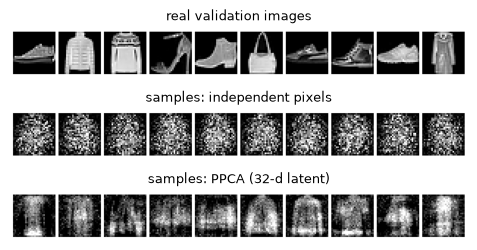

→ Lower bits/dim for 'PPCA, 32-d latent': modelling how pixels co-vary through a latent space helps both likelihood and samples.


In [3]:
dequant_g = torch.Generator().manual_seed(SEED)


def dequantize(images_u8):
    """(pixel + U(0, 1)) / 256: a continuous version of 8-bit pixels, flattened to (N, 784) float64."""
    noise = torch.rand(images_u8.shape, generator=dequant_g, dtype=torch.float64)
    return ((images_u8.double() + noise) / 256).view(len(images_u8), -1).numpy()


X_fit, X_eval = dequantize(X_train_u8[:10_000]), dequantize(X_val_u8[:2_000])
pixel_mean, pixel_std = X_fit.mean(axis=0), X_fit.std(axis=0)
ll_independent = scipy.stats.norm.logpdf(X_eval, pixel_mean, pixel_std).sum(axis=1)
ppca = PCA(n_components=32, random_state=SEED).fit(X_fit)
ll_ppca = scipy.stats.multivariate_normal(ppca.mean_, ppca.get_covariance()).logpdf(X_eval)   # PPCA = Gaussian with covariance W Wᵀ + σ² I


def bits_per_dim(ll_nats):
    return 8 - ll_nats / (784 * np.log(2))


likelihood_table = pd.DataFrame({
    "val log-likelihood (nats/image)": [ll_independent.mean(), ll_ppca.mean()],
    "bits per dimension": [bits_per_dim(ll_independent.mean()), bits_per_dim(ll_ppca.mean())],
}, index=["independent pixels", "PPCA, 32-d latent"])
print(likelihood_table.round(3).to_string())

rng = np.random.default_rng(SEED)
samples_independent = np.clip(pixel_mean + pixel_std * rng.standard_normal((10, 784)), 0, 1)
z = rng.standard_normal((10, 32))
loadings = ppca.components_ * np.sqrt(ppca.explained_variance_ - ppca.noise_variance_)[:, None]      # W = U (Λ − σ²I)^½
samples_ppca = np.clip(ppca.mean_ + z @ loadings + np.sqrt(ppca.noise_variance_) * rng.standard_normal((10, 784)), 0, 1)

fig, axes = plt.subplots(3, 1, figsize=(7, 2.6))
show_grid(to_unit(X_val_u8[:10]), title="real validation images", ax=axes[0], value_range=(0, 1))
show_grid(torch.tensor(samples_independent).view(10, 1, 28, 28), title="samples: independent pixels", ax=axes[1], value_range=(0, 1))
show_grid(torch.tensor(samples_ppca).view(10, 1, 28, 28), title="samples: PPCA (32-d latent)", ax=axes[2], value_range=(0, 1))
plt.tight_layout()
plt.show()
better = likelihood_table["bits per dimension"].idxmin()
print(f"→ Lower bits/dim for '{better}': modelling how pixels co-vary through a latent space helps both likelihood and samples.")

PPCA samples have garment-like shapes but are blurry: a *linear* map from a Gaussian can't capture sharp, multi-modal structure. VAEs make that map a deep network; diffusion models take a different route entirely.

**Why evaluating samples is hard.** A good-looking sample proves little. Here is the laziest "generator" possible: it returns random *training* images. Its samples are perfect, and it has learned nothing.

In [4]:
X_train_flat = to_unit(X_train_u8[:10_000]).view(10_000, -1)
copies = to_unit(X_train_u8[torch.randperm(10_000, generator=torch.Generator().manual_seed(1))[:200]]).view(200, -1)
ppca_many = np.clip(ppca.mean_ + rng.standard_normal((200, 32)) @ loadings, 0, 1)
fresh_real = to_unit(X_val_u8[:200]).view(200, -1)
for name, batch in [("copy-paste 'generator'", copies), ("PPCA samples", torch.tensor(ppca_many, dtype=torch.float32)), ("unseen real images", fresh_real)]:
    nearest = torch.cdist(batch, X_train_flat).min(dim=1).values
    print(f"{name:24s} median distance to the nearest training image: {nearest.median():.2f}")
print("→ The copier's distance is exactly 0: perfect-looking samples, zero novelty. Always check nearest training neighbours, not just sample quality.")

copy-paste 'generator'   median distance to the nearest training image: 0.00
PPCA samples             median distance to the nearest training image: 5.03
unseen real images       median distance to the nearest training image: 3.87
→ The copier's distance is exactly 0: perfect-looking samples, zero novelty. Always check nearest training neighbours, not just sample quality.


### ✍️ Your Turn

A model assigns an image a log-likelihood of **1,500 nats** (784 pixels scaled to [0, 1]). Convert it to **bits per dimension** on the 0–255 scale with $\text{bpd} = 8 - \frac{\log p(x)}{784 \ln 2}$. Store a float in `bpd_answer`.

In [5]:
bpd_answer = None  # TODO
check("bpd_answer", bpd_answer, 8 - 1500 / (784 * math.log(2)), hint="8 - 1500 / (784 * np.log(2))")

⏳ bpd_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
bpd_answer = 8 - 1500 / (784 * np.log(2))     # ≈ 5.24 bits per pixel
check("bpd_answer", bpd_answer, 8 - 1500 / (784 * math.log(2)))
```

Dividing nats by $\ln 2$ gives bits; dividing by 784 gives bits per pixel. The $+8$ converts a density on [0, 1] to probabilities of the 256 grey levels, since $\log_2 256 = 8$.
</details>

> 💡 **Interview angle:** "Generative vs discriminative?" — discriminative models learn $p(y\mid x)$ to separate classes; generative models learn $p(x)$ (or $p(x\mid y)$) so they can sample, and likelihood-based ones can also score. Add that implicit models (GANs) can't give likelihoods, and that good samples alone can hide memorization.

## 2. From Autoencoders to VAEs 🟡

An **autoencoder** squeezes an image through a bottleneck and rebuilds it:

```
  x (784) ──► encoder ──► z (16 numbers) ──► decoder ──► x̂ (784)          loss = reconstruction error
```

It compresses well, but it is **not a generator**. Nothing forces the codes of real images to fill a known region, so a random $z$ usually lands in a "hole" and decodes to garbage.

A **variational autoencoder (VAE)** fixes this with two changes:

1. The encoder outputs a *distribution* $q_\phi(z\mid x) = \mathcal{N}(\mu_\phi(x), \operatorname{diag}\sigma^2_\phi(x))$ instead of a point.
2. Training pulls every $q_\phi(z\mid x)$ towards the prior $p(z) = \mathcal{N}(0, I)$, so random prior samples decode to sensible images.

**The ELBO in plain words.** We want to maximise $\log p_\theta(x) = \log \int p_\theta(x\mid z)\,p(z)\,dz$, but that integral over all $z$ is intractable. Multiply and divide by $q_\phi(z\mid x)$ and apply Jensen's inequality ($\log \mathbb{E} \ge \mathbb{E} \log$):

$$\log p_\theta(x) \;\ge\; \underbrace{\mathbb{E}_{q_\phi(z\mid x)}\big[\log p_\theta(x\mid z)\big]}_{\text{reconstruction: decode a sampled code back to } x} \;-\; \underbrace{\mathrm{KL}\big(q_\phi(z\mid x)\,\|\,p(z)\big)}_{\text{keep codes close to the prior}} \;=\; \text{ELBO}$$

The gap is exactly $\mathrm{KL}\big(q_\phi(z\mid x)\,\|\,p_\theta(z\mid x)\big) \ge 0$, so a better encoder gives a tighter bound. Training maximises the ELBO, i.e. minimises **reconstruction loss + KL**.

**The reparameterization trick.** Sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ is random, and you can't backpropagate through "pick a random number". Rewrite the sample as a deterministic function of the parameters plus outside noise:

$$z = \mu + \sigma \odot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

Now $\partial z / \partial \mu = 1$ and $\partial z / \partial \sigma = \varepsilon$, so gradients flow into the encoder.

**The closed-form KL** between a diagonal Gaussian and $\mathcal{N}(0, I)$, per image, with $\log\sigma^2$ predicted for numerical stability:

$$\mathrm{KL} = -\tfrac{1}{2}\sum_{j=1}^{d}\left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

We treat each pixel intensity in [0, 1] as the probability of a Bernoulli "ink" variable, so the reconstruction term is binary cross-entropy **summed** over the 784 pixels (the same units as the KL, nats per image).

In [6]:
class MLPAutoencoder(nn.Module):
    """784 → 512 → 256 → latent → 256 → 512 → 784. variational=True makes it a VAE (encoder outputs μ and log σ²)."""

    def __init__(self, latent_dim=16, variational=True, n_labels=0):
        super().__init__()
        self.latent_dim, self.variational, self.n_labels = latent_dim, variational, n_labels
        self.encoder = nn.Sequential(nn.Linear(784 + n_labels, 512), nn.ReLU(), nn.Linear(512, 256), nn.ReLU(),
                                     nn.Linear(256, 2 * latent_dim if variational else latent_dim))
        self.decoder = nn.Sequential(nn.Linear(latent_dim + n_labels, 256), nn.ReLU(), nn.Linear(256, 512), nn.ReLU(),
                                     nn.Linear(512, 784))                                   # logits of 784 Bernoulli pixels

    def encode(self, x, y_onehot=None):
        h = x.flatten(1) if y_onehot is None else torch.cat([x.flatten(1), y_onehot], dim=1)
        out = self.encoder(h)
        if not self.variational:
            return out, None
        mu, logvar = out.chunk(2, dim=1)
        return mu, logvar.clamp(-12, 8)

    def decode(self, z, y_onehot=None):
        h = z if y_onehot is None else torch.cat([z, y_onehot], dim=1)
        return self.decoder(h).view(-1, 1, 28, 28)

    def forward(self, x, y_onehot=None):
        mu, logvar = self.encode(x, y_onehot)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu) if self.variational else mu   # reparameterization trick
        return self.decode(z, y_onehot), mu, logvar


def gaussian_kl(mu, logvar):
    """KL(N(mu, exp(logvar)) || N(0, I)) per latent dimension, shape (batch, latent_dim)."""
    return -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())


def vae_terms(model, x_unit, y_onehot=None):
    """Reconstruction (nats/image) and per-dimension KL for a batch of [0, 1] images."""
    logits, mu, logvar = model(x_unit, y_onehot)
    recon = F.binary_cross_entropy_with_logits(logits, x_unit, reduction="none").flatten(1).sum(dim=1)
    kl = gaussian_kl(mu, logvar) if model.variational else torch.zeros_like(mu)
    return recon, kl


@torch.inference_mode()
def evaluate_vae(model, images_u8, labels=None):
    model.eval()
    x = to_unit(images_u8).to(DEVICE)
    y1h = None if labels is None or not model.n_labels else F.one_hot(labels, 10).float().to(DEVICE)
    recon, kl = vae_terms(model, x, y1h)
    mu, _ = model.encode(x, y1h)
    return {"recon (nats)": recon.mean().item(), "KL (nats)": kl.sum(1).mean().item(),
            "KL per dim": kl.mean(0).cpu(), "active units": int((mu.var(0) > 0.01).sum())}


def train_autoencoder(model, epochs, beta=1.0, seed=SEED, batch_size=128, lr=1e-3):
    seed_everything(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        for idx in epoch_batches(len(X_train_dev), batch_size, torch.Generator().manual_seed(seed + epoch)):
            recon, kl = vae_terms(model, to_unit(X_train_dev[idx]))
            loss = (recon + beta * kl.sum(dim=1)).mean()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
    return model


AE_EPOCHS = 6
start = time.perf_counter()
autoencoder = train_autoencoder(MLPAutoencoder(latent_dim=16, variational=False).to(DEVICE), AE_EPOCHS)
vae = train_autoencoder(MLPAutoencoder(latent_dim=16, variational=True).to(DEVICE), AE_EPOCHS, beta=1.0)
ae_stats, vae_stats = evaluate_vae(autoencoder, X_val_u8), evaluate_vae(vae, X_val_u8)
print(f"trained an autoencoder and a VAE ({n_params(vae):,} parameters each, {AE_EPOCHS} epochs) in {time.perf_counter() - start:.0f}s")
print(pd.DataFrame({"autoencoder": {k: ae_stats[k] for k in ["recon (nats)", "KL (nats)"]},
                    "VAE": {k: vae_stats[k] for k in ["recon (nats)", "KL (nats)"]}}).round(1).to_string())
print(f"VAE validation ELBO = −(recon + KL) = {-(vae_stats['recon (nats)'] + vae_stats['KL (nats)']):.1f} nats per image (a lower bound on log p(x))")

trained an autoencoder and a VAE (1,079,600 parameters each, 6 epochs) in 22s
              autoencoder    VAE
recon (nats)        218.7  231.3
KL (nats)             0.0   12.2
VAE validation ELBO = −(recon + KL) = -243.5 nats per image (a lower bound on log p(x))


The plain autoencoder reconstructs better: it spends nothing on the KL term. The question is which one can **generate**. Below, both decoders receive the same random codes $z \sim \mathcal{N}(0, I)$.

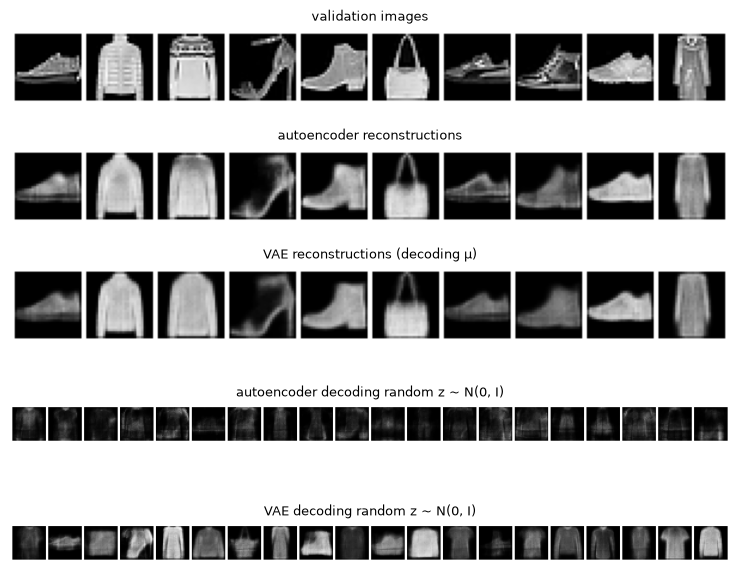

autoencoder codes: mean |value| 2.27, std per dimension 2.30  → far from N(0, I), so random z miss the data
VAE means μ      : mean |value| 0.37, std per dimension 0.47  → packed near the prior, so random z decode to clothes


In [7]:
with torch.inference_mode():
    x_show = to_unit(X_val_u8[:10]).to(DEVICE)
    ae_codes = autoencoder.encode(to_unit(X_val_u8).to(DEVICE))[0]
    vae_mu = vae.encode(to_unit(X_val_u8).to(DEVICE))[0]
    z_prior = torch.randn(20, 16, generator=torch.Generator().manual_seed(0)).to(DEVICE)
    panels = [(x_show, "validation images"),
              (torch.sigmoid(autoencoder(x_show)[0]), "autoencoder reconstructions"),
              (torch.sigmoid(vae.decode(vae.encode(x_show)[0])), "VAE reconstructions (decoding μ)"),
              (torch.sigmoid(autoencoder.decode(z_prior)), "autoencoder decoding random z ~ N(0, I)"),
              (torch.sigmoid(vae.decode(z_prior)), "VAE decoding random z ~ N(0, I)")]
fig, axes = plt.subplots(len(panels), 1, figsize=(7.5, 6.2))
for ax, (imgs, title) in zip(axes, panels):
    show_grid(imgs, nrow=10 if len(imgs) == 10 else 20, title=title, ax=ax, value_range=(0, 1))
plt.tight_layout()
plt.show()
print(f"autoencoder codes: mean |value| {ae_codes.abs().mean():.2f}, std per dimension {ae_codes.std(0).mean():.2f}  → far from N(0, I), so random z miss the data")
print(f"VAE means μ      : mean |value| {vae_mu.abs().mean():.2f}, std per dimension {vae_mu.std(0).mean():.2f}  → packed near the prior, so random z decode to clothes")

**Latent interpolation.** Walk in a straight line between the VAE codes of two real images. A smooth latent space gives plausible in-between garments. Blending *pixels* only superimposes two ghosts.

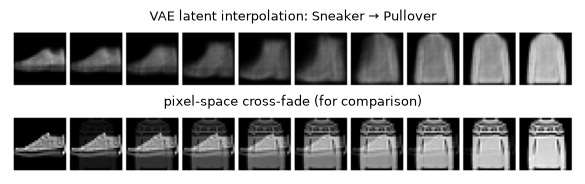

In [8]:
idx_a = int((y_val == CLASSES.index("Sneaker")).nonzero()[0])
idx_b = int((y_val == CLASSES.index("Pullover")).nonzero()[0])
alphas = torch.linspace(0, 1, 10, device=DEVICE)[:, None]
with torch.inference_mode():
    pair = to_unit(X_val_u8[[idx_a, idx_b]]).to(DEVICE)
    mu_pair = vae.encode(pair)[0]
    latent_path = torch.sigmoid(vae.decode((1 - alphas) * mu_pair[0] + alphas * mu_pair[1]))
    pixel_path = (1 - alphas.view(-1, 1, 1, 1)) * pair[0] + alphas.view(-1, 1, 1, 1) * pair[1]
fig, axes = plt.subplots(2, 1, figsize=(7, 1.9))
show_grid(latent_path, title="VAE latent interpolation: Sneaker → Pullover", ax=axes[0], value_range=(0, 1))
show_grid(pixel_path, title="pixel-space cross-fade (for comparison)", ax=axes[1], value_range=(0, 1))
plt.tight_layout()
plt.show()

VAE samples are recognisable but **blurry**. The Bernoulli/Gaussian likelihood averages over every image that matches a code, and averages are smooth. That blurriness is why modern systems use a VAE only as a *compressor* and let a diffusion model do the generating (section 11).

### ✍️ Your Turn

Apply the reparameterization trick by hand: `mu_yt = [0.5, -1.0]`, `logvar_yt = [0.0, ln 4]`, noise `eps_yt = [1.0, -0.5]`. Store $z = \mu + e^{\frac{1}{2}\log\sigma^2}\,\varepsilon$ as a tensor in `z_yt`.

In [9]:
mu_yt = torch.tensor([0.5, -1.0])
logvar_yt = torch.tensor([0.0, math.log(4.0)])
eps_yt = torch.tensor([1.0, -0.5])
z_yt = None  # TODO
check("reparameterization", z_yt, [1.5, -2.0], hint="σ = exp(0.5 · logvar), so the second σ is 2.")

⏳ reparameterization: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mu_yt = torch.tensor([0.5, -1.0])
logvar_yt = torch.tensor([0.0, math.log(4.0)])
eps_yt = torch.tensor([1.0, -0.5])
z_yt = mu_yt + torch.exp(0.5 * logvar_yt) * eps_yt      # [0.5 + 1·1, −1 + 2·(−0.5)]
check("reparameterization", z_yt, [1.5, -2.0])
```

The randomness lives in `eps_yt`, which needs no gradient; `mu_yt` and `logvar_yt` stay on the differentiable path.
</details>

> 💡 **Interview angle:** "Derive the VAE loss." — start from $\log p(x) = \log \mathbb{E}_{q}[p(x\mid z)p(z)/q(z\mid x)]$, apply Jensen to get the ELBO = reconstruction − KL, note the gap is $\mathrm{KL}(q\,\|\,p(z\mid x))$, then explain the reparameterization trick ($z = \mu + \sigma\varepsilon$) that makes the sampling step differentiable and gives low-variance gradients.

## 3. The β Trade-off and Posterior Collapse 🟡

A **β-VAE** multiplies the KL term by β: loss = reconstruction + β·KL.

- **β < 1:** codes may drift from the prior. Reconstructions are sharper, but random samples are worse.
- **β > 1:** codes hug the prior. Latents can become more "disentangled", but reconstructions blur.
- **Posterior collapse:** when the KL penalty wins, the encoder sets $q(z_j\mid x) = p(z_j)$ for some or all dimensions. Those dimensions carry **no information** (KL ≈ 0) and the decoder ignores them. It happens with large β, and with very powerful decoders (e.g. autoregressive ones) that can model $x$ without $z$.

We measure **active units** (Burda et al., 2015): a latent dimension is active if its posterior mean $\mu_j(x)$ actually varies across images, $\operatorname{Var}_x[\mu_j(x)] > 0.01$.

4 VAEs × 3 epochs in 43s
      recon (nats)  KL (nats)  ELBO (β=1 bound)  active units / 16
β                                                                 
0.5          231.1       16.6            -247.7                 16
1.0          236.2       11.5            -247.7                  7
4.0          251.4        5.5            -256.9                  5
16.0         285.6        2.4            -288.0                  4


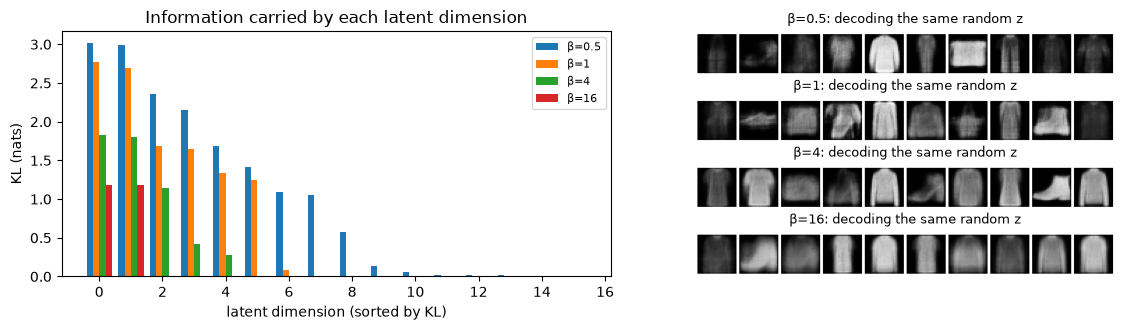

→ Raising β from 0.5 to 16 raised reconstruction loss from 231 to 286 nats and cut the KL from 17 to 2 nats.
→ At β=16, 12 of 16 latent dimensions collapsed to the prior (posterior collapse); best β=1 bound here: β=0.5.


In [10]:
BETAS = [0.5, 1.0, 4.0, 16.0]
BETA_EPOCHS = 3
beta_rows, beta_kl_per_dim, beta_samples = [], {}, {}
start = time.perf_counter()
z_fixed = torch.randn(10, 16, generator=torch.Generator().manual_seed(0)).to(DEVICE)
for beta in BETAS:
    model = train_autoencoder(MLPAutoencoder(latent_dim=16).to(DEVICE), BETA_EPOCHS, beta=beta)
    stats = evaluate_vae(model, X_val_u8)
    beta_rows.append({"β": beta, "recon (nats)": stats["recon (nats)"], "KL (nats)": stats["KL (nats)"],
                      "ELBO (β=1 bound)": -(stats["recon (nats)"] + stats["KL (nats)"]), "active units / 16": stats["active units"]})
    beta_kl_per_dim[beta] = stats["KL per dim"]
    with torch.inference_mode():
        beta_samples[beta] = torch.sigmoid(model.decode(z_fixed))
    del model
beta_table = pd.DataFrame(beta_rows).set_index("β")
print(f"{len(BETAS)} VAEs × {BETA_EPOCHS} epochs in {time.perf_counter() - start:.0f}s")
print(beta_table.round(1).to_string())

fig = plt.figure(figsize=(12, 3.4))
ax_bar = fig.add_subplot(1, 2, 1)
width = 0.2
for k, beta in enumerate(BETAS):
    ax_bar.bar(np.arange(16) + (k - 1.5) * width, np.sort(beta_kl_per_dim[beta].numpy())[::-1], width, label=f"β={beta:g}")
ax_bar.set(xlabel="latent dimension (sorted by KL)", ylabel="KL (nats)", title="Information carried by each latent dimension")
ax_bar.legend(fontsize=8)
for k, beta in enumerate(BETAS):
    show_grid(beta_samples[beta], title=f"β={beta:g}: decoding the same random z", ax=fig.add_subplot(len(BETAS), 2, 2 * k + 2), value_range=(0, 1))
plt.tight_layout()
plt.show()

collapsed_high = 16 - int(beta_table.loc[max(BETAS), "active units / 16"])
print(f"→ Raising β from {min(BETAS):g} to {max(BETAS):g} raised reconstruction loss from {beta_table['recon (nats)'].iloc[0]:.0f} to "
      f"{beta_table['recon (nats)'].iloc[-1]:.0f} nats and cut the KL from {beta_table['KL (nats)'].iloc[0]:.0f} to {beta_table['KL (nats)'].iloc[-1]:.0f} nats.")
print(f"→ At β={max(BETAS):g}, {collapsed_high} of 16 latent dimensions collapsed to the prior (posterior collapse); "
      f"best β=1 bound here: β={beta_table['ELBO (β=1 bound)'].idxmax():g}.")
del beta_samples
free_memory()

Fixes for posterior collapse you can quote: **KL annealing** (start β at 0 and ramp it to 1), **free bits** (don't penalise the first λ nats of KL per dimension), weaker decoders, and skip connections from $z$ into every decoder layer.

### ✍️ Your Turn

A colleague writes the VAE loss as `F.binary_cross_entropy(x_hat, x)` (the default **mean** over all 784 pixels) `+ kl.sum(dim=1).mean()` (**sum** over latent dimensions). Relative to the correct per-image objective (recon summed over pixels + KL), this silently rescales the balance. What **effective β** does their loss correspond to? Store an `int` in `effective_beta`.

In [11]:
effective_beta = None  # TODO
check("effective_beta", effective_beta, 784, hint="Mean over pixels = sum / 784. Multiply the whole loss by 784 to get back to summed reconstruction.")

⏳ effective_beta: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
effective_beta = 784     # mean_BCE + KL = (sum_BCE + 784 · KL) / 784
check("effective_beta", effective_beta, 784)
```

Scaling the whole loss doesn't change the optimum, so this is a β-VAE with β = 784, and it collapses almost every latent dimension (⚠️ Pitfall 4 shows it).
</details>

> 💡 **Interview angle:** "What is posterior collapse and how do you fix it?" — the KL term pushes $q(z\mid x)$ onto the prior, so latents carry no information and the decoder ignores them. Detect it with per-dimension KL or active units. Fix it with KL annealing, free bits, a weaker decoder, or a smaller β, and check the loss reductions first.

## 4. GANs: The Minimax Game and Mode Collapse 🟡

A **GAN** trains two networks against each other:

- the **generator** $G$ (a forger) turns noise $z \sim \mathcal{N}(0, I)$ into fake images,
- the **discriminator** $D$ (a detective) outputs the probability that its input is real.

```
  z ──► G ──► fake ──┐
                     ├──► D ──► P(real)        D wants: real → 1, fake → 0
  real images ───────┘                          G wants: D(fake) → 1
```

**The minimax objective** (Goodfellow et al., 2014):

$$\min_G \max_D \; \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z}[\log(1 - D(G(z)))]$$

For a fixed $G$ the best detective is $D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$. Plugging it in, $G$ minimises $2\cdot\mathrm{JSD}(p_{\text{data}}\,\|\,p_g) - \log 4$, a divergence that is zero only when the fake distribution equals the real one.

**The non-saturating trick.** Early in training $D$ easily rejects fakes, so $D(G(z)) \approx 0$. There, $\log(1 - D(G(z)))$ is flat and $G$ gets almost no gradient. In practice $G$ instead **maximises** $\log D(G(z))$: the same fixed point, with strong gradients exactly when $G$ is losing.

when D confidently rejects a fake (logit −5, D = 0.0067):
  |gradient| saturating loss     = 0.0067
  |gradient| non-saturating loss = 0.9933  → 148× stronger learning signal


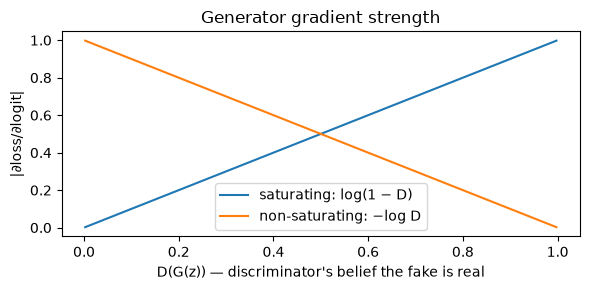

In [12]:
d_logits = torch.linspace(-6, 6, 121, requires_grad=True)       # D's raw score for a fake image (sigmoid → P(real))
saturating = torch.log1p(-torch.sigmoid(d_logits))              # G minimises log(1 − D(G(z)))
non_saturating = -F.logsigmoid(d_logits)                         # G minimises −log D(G(z))
grad_sat = torch.autograd.grad(saturating.sum(), d_logits)[0]
grad_ns = torch.autograd.grad(non_saturating.sum(), d_logits)[0]
at = int((d_logits.detach() - (-5.0)).abs().argmin())
print(f"when D confidently rejects a fake (logit −5, D = {torch.sigmoid(torch.tensor(-5.0)):.4f}):")
print(f"  |gradient| saturating loss     = {grad_sat[at].abs():.4f}")
print(f"  |gradient| non-saturating loss = {grad_ns[at].abs():.4f}  → {grad_ns[at].abs() / grad_sat[at].abs():.0f}× stronger learning signal")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(torch.sigmoid(d_logits).detach(), grad_sat.abs(), label="saturating: log(1 − D)")
ax.plot(torch.sigmoid(d_logits).detach(), grad_ns.abs(), label="non-saturating: −log D")
ax.set(xlabel="D(G(z)) — discriminator's belief the fake is real", ylabel="|∂loss/∂logit|", title="Generator gradient strength")
ax.legend()
plt.tight_layout()
plt.show()

**Why GAN training is unstable:**

1. **It's a game, not a minimisation.** Gradient steps on two players can circle around the equilibrium instead of converging, and the losses don't tell you whether samples are improving.
2. **Balance matters.** A discriminator that is too strong gives vanishing gradients. One that is too weak gives useless feedback, and $G$ exploits its blind spots.
3. **Mode collapse.** $G$ only has to fool the *current* $D$. If one kind of output fools it, $G$ can put all its samples there, ignoring the other modes (kinds of data). $D$ then learns to reject that mode, $G$ hops to another, and so on.

**A controlled demonstration.** Mode collapse is easiest to *see* in 2-D. We use a synthetic mixture of 8 Gaussians on a ring; synthetic data is deliberate here, because we know exactly where the 8 modes are. The same small MLP GAN is trained twice on the CPU: once with **balanced** learning rates, once with a **weak discriminator** (learning rate 10× lower than the generator's).

two 2-D GANs trained on CPU in 4s
                                                modes covered / 8  high-quality share  busiest-mode share
run                                       step                                                           
balanced (D lr = G lr = 1e-3)             250                   2                0.12                0.14
                                          500                   5                0.27                0.15
                                          1000                  8                0.70                0.15
                                          2000                  8                0.88                0.17
weak discriminator (D lr 1e-4, G lr 1e-3) 250                   1                0.18                1.00
                                          500                   0                0.00                1.00
                                          1000                  1                0.32                1.00
            

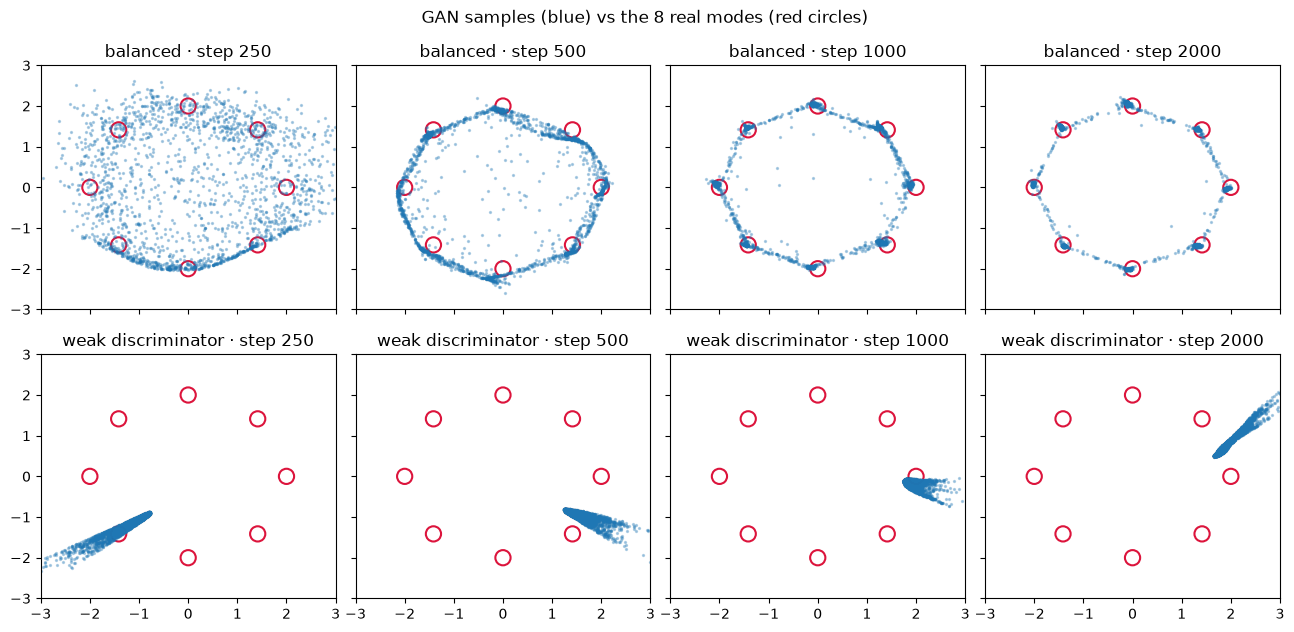

→ balanced (D lr = G lr = 1e-3): 8/8 modes at step 2000, busiest mode holds 17% of samples (healthy coverage)
→ weak discriminator (D lr 1e-4, G lr 1e-3): 0/8 modes at step 2000, busiest mode holds 54% of samples (mode collapse / failure: the generator ignores most of the data)


In [13]:
RING = torch.tensor([[2 * math.cos(2 * math.pi * k / 8), 2 * math.sin(2 * math.pi * k / 8)] for k in range(8)])


def ring_batch(n, generator):
    return RING[torch.randint(0, 8, (n,), generator=generator)] + 0.02 * torch.randn(n, 2, generator=generator)


def mode_stats(points):
    """Modes covered (≥2% of samples within 0.2 of a centre), share of high-quality samples, share in the busiest mode."""
    dist = torch.cdist(points, RING)
    nearest, good = dist.argmin(dim=1), dist.min(dim=1).values < 0.2
    counts = torch.bincount(nearest[good], minlength=8)
    return int((counts >= 0.02 * len(points)).sum()), good.float().mean().item(), torch.bincount(nearest, minlength=8).max().item() / len(points)


def mlp(n_in, n_out, hidden=128):
    return nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, n_out))


def train_ring_gan(d_lr, g_lr, steps=2000, seed=0, batch_size=256, snapshots=(250, 500, 1000, 2000)):
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    gen, disc = mlp(2, 2), mlp(2, 1)
    opt_g = torch.optim.Adam(gen.parameters(), lr=g_lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=d_lr, betas=(0.5, 0.999))
    shots = {}
    for step in range(1, steps + 1):
        real, fake = ring_batch(batch_size, g), gen(torch.randn(batch_size, 2, generator=g))
        d_loss = F.softplus(-disc(real)).mean() + F.softplus(disc(fake.detach())).mean()    # = −log D(real) − log(1 − D(fake))
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()
        g_loss = F.softplus(-disc(gen(torch.randn(batch_size, 2, generator=g)))).mean()      # non-saturating: −log D(G(z))
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()
        if step in snapshots:
            with torch.no_grad():
                shots[step] = gen(torch.randn(2000, 2, generator=g))
    return shots


start = time.perf_counter()
ring_runs = {"balanced (D lr = G lr = 1e-3)": train_ring_gan(d_lr=1e-3, g_lr=1e-3),
             "weak discriminator (D lr 1e-4, G lr 1e-3)": train_ring_gan(d_lr=1e-4, g_lr=1e-3)}
print(f"two 2-D GANs trained on CPU in {time.perf_counter() - start:.0f}s")
rows = []
for name, shots in ring_runs.items():
    for step, pts in shots.items():
        covered, quality, busiest = mode_stats(pts)
        rows.append({"run": name, "step": step, "modes covered / 8": covered, "high-quality share": quality, "busiest-mode share": busiest})
ring_table = pd.DataFrame(rows).set_index(["run", "step"])
print(ring_table.round(2).to_string())

fig, axes = plt.subplots(2, 4, figsize=(13, 6.4), sharex=True, sharey=True)
for r, (name, shots) in enumerate(ring_runs.items()):
    for c, (step, pts) in enumerate(shots.items()):
        ax = axes[r, c]
        ax.scatter(RING[:, 0], RING[:, 1], s=120, c="none", edgecolors="crimson", lw=1.5)
        ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3)
        ax.set(title=f"{name.split(' (')[0]} · step {step}", xlim=(-3, 3), ylim=(-3, 3))
plt.suptitle("GAN samples (blue) vs the 8 real modes (red circles)")
plt.tight_layout()
plt.show()

final = ring_table.xs(2000, level="step")
for name in ring_runs:
    cov = int(final.loc[name, "modes covered / 8"])
    print(f"→ {name}: {cov}/8 modes at step 2000, busiest mode holds {final.loc[name, 'busiest-mode share']:.0%} of samples "
          + ("(healthy coverage)" if cov == 8 else "(mode collapse / failure: the generator ignores most of the data)"))

With a weak discriminator, the generator finds *some* region the discriminator doesn't penalise and piles its samples there. Watch the snapshots: the pile moves over time, but it doesn't spread over all 8 modes. The same failure happens with images: "every generated garment is the same trouser".

**Fixes you should be able to name:** balance the players (learning rates, the two time-scale update rule), non-saturating or **Wasserstein** losses with a gradient penalty (WGAN-GP), **spectral normalization** in $D$, minibatch discrimination / **PacGAN** (let $D$ see several samples at once, so it can spot a lack of variety), R1 gradient penalties, EMA of generator weights, and conditioning on labels.

> 💡 **Interview angle:** "Why are GANs hard to train?" — it's a two-player game (no single loss to monitor, can oscillate), the discriminator can overpower the generator (vanishing gradients) or be too weak to guide it, and the generator only needs to fool the current discriminator, which invites **mode collapse**. Name two fixes (spectral norm, WGAN-GP, TTUR, minibatch discrimination) and how you'd *detect* collapse (sample diversity, class histograms, recall).

## 5. DCGAN on Fashion-MNIST and Conditional GANs 🟡

**DCGAN** (Radford et al., 2015) found an architecture recipe that made GANs on images train reliably:

| Rule | Generator | Discriminator |
|---|---|---|
| No pooling | transposed convs upsample (stride 2) | strided convs downsample |
| BatchNorm | yes (not on the output) | yes (not on the input) |
| Activations | ReLU, **tanh** output → images in [−1, 1] | **LeakyReLU(0.2)** |
| Optimizer | Adam, lr 2e-4, β₁ = 0.5 | same |

```
  G:  z (64) ─► ConvT 7×7 ─► 128×7×7 ─► ConvT ─► 64×14×14 ─► ConvT ─► 1×28×28 (tanh)
  D:  1×28×28 ─► Conv ─► 64×14×14 ─► Conv ─► 128×7×7 ─► Linear ─► real/fake logit
```

DCGAN: G 533,889 + D 138,689 parameters | 1500 steps in 41s


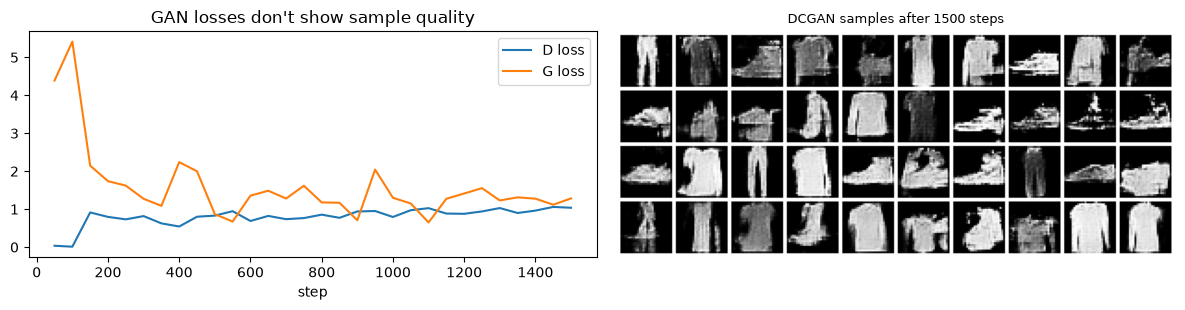

judge's class histogram of samples: {'T-shirt/top': 0.11, 'Trouser': 0.09, 'Pullover': 0.08, 'Dress': 0.11, 'Coat': 0.09, 'Sandal': 0.14, 'Shirt': 0.13, 'Sneaker': 0.07, 'Bag': 0.07, 'Ankle boot': 0.12}
class entropy 3.28 bits (max 3.32) | relative diversity 0.80


In [14]:
class DCGenerator(nn.Module):
    def __init__(self, z_dim=64, ch=64, n_classes=0, emb_dim=16):
        super().__init__()
        self.z_dim, self.n_classes = z_dim, n_classes
        self.label_emb = nn.Embedding(n_classes, emb_dim) if n_classes else None
        in_dim = z_dim + (emb_dim if n_classes else 0)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_dim, ch * 2, 7, 1, 0, bias=False), nn.BatchNorm2d(ch * 2), nn.ReLU(True),   # 1 → 7
            nn.ConvTranspose2d(ch * 2, ch, 4, 2, 1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(True),           # 7 → 14
            nn.ConvTranspose2d(ch, 1, 4, 2, 1), nn.Tanh(),                                                     # 14 → 28
        )

    def forward(self, z, labels=None):
        h = z if self.label_emb is None else torch.cat([z, self.label_emb(labels)], dim=1)
        return self.net(h[:, :, None, None])


class DCDiscriminator(nn.Module):
    def __init__(self, ch=64, n_classes=0):
        super().__init__()
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Conv2d(1 + n_classes, ch, 4, 2, 1), nn.LeakyReLU(0.2, True),                                  # 28 → 14
            nn.Conv2d(ch, ch * 2, 4, 2, 1, bias=False), nn.BatchNorm2d(ch * 2), nn.LeakyReLU(0.2, True),      # 14 → 7
            nn.Flatten(), nn.Linear(ch * 2 * 7 * 7, 1),
        )

    def forward(self, x, labels=None):
        if self.n_classes:                                          # conditional D: one-hot label planes stacked on the image
            planes = F.one_hot(labels, self.n_classes).float()[:, :, None, None].expand(-1, -1, 28, 28)
            x = torch.cat([x, planes], dim=1)
        return self.net(x)


def gan_step(gen, disc, opt_g, opt_d, real, labels=None):
    """One discriminator step and one non-saturating generator step. Returns (d_loss, g_loss) as tensors."""
    z = torch.randn(len(real), gen.z_dim, device=DEVICE)
    fake = gen(z, labels)
    d_loss = F.softplus(-disc(real, labels)).mean() + F.softplus(disc(fake.detach(), labels)).mean()
    opt_d.zero_grad(set_to_none=True)
    d_loss.backward()
    opt_d.step()
    g_loss = F.softplus(-disc(fake, labels)).mean()
    opt_g.zero_grad(set_to_none=True)
    g_loss.backward()
    opt_g.step()
    return d_loss.detach(), g_loss.detach()


def relative_diversity(images_sym, reference_feats):
    """Mean pairwise distance of judge embeddings, relative to real images (1.0 = as varied as real data)."""
    feats, _ = judge_features(images_sym)
    return torch.pdist(torch.tensor(feats)).mean().item() / torch.pdist(torch.tensor(reference_feats)).mean().item()


def class_entropy_bits(images_sym):
    """Entropy of the judge's predicted-class histogram (log2(10) ≈ 3.32 bits = perfectly balanced classes)."""
    _, probs = judge_features(images_sym)
    hist = torch.bincount(probs.argmax(1), minlength=10).float() / len(probs)
    nz = hist[hist > 0]
    return -(nz * nz.log2()).sum().item(), hist


DCGAN_STEPS = 1500
seed_everything(SEED)
dc_gen, dc_disc = DCGenerator().to(DEVICE), DCDiscriminator().to(DEVICE)
opt_g = torch.optim.Adam(dc_gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(dc_disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
g_batches = torch.Generator().manual_seed(SEED)
log = []
start = time.perf_counter()
for step in range(1, DCGAN_STEPS + 1):
    idx = torch.randint(0, len(X_train_dev), (128,), generator=g_batches).to(DEVICE)
    d_loss, g_loss = gan_step(dc_gen, dc_disc, opt_g, opt_d, to_sym(X_train_dev[idx]))
    if step % 50 == 0:
        log.append((step, d_loss.item(), g_loss.item()))
sync()
print(f"DCGAN: G {n_params(dc_gen):,} + D {n_params(dc_disc):,} parameters | {DCGAN_STEPS} steps in {time.perf_counter() - start:.0f}s")

ref_feats_500 = val_feats[:N_EVAL]
dc_gen.eval()
with torch.inference_mode():
    dcgan_samples = dc_gen(torch.randn(N_EVAL, 64, generator=torch.Generator().manual_seed(0)).to(DEVICE)).cpu()
dc_entropy, dc_hist = class_entropy_bits(dcgan_samples)
dc_div = relative_diversity(dcgan_samples, ref_feats_500)

fig = plt.figure(figsize=(12, 3.2))
ax = fig.add_subplot(1, 2, 1)
steps_, d_losses, g_losses = zip(*log)
ax.plot(steps_, d_losses, label="D loss")
ax.plot(steps_, g_losses, label="G loss")
ax.set(xlabel="step", title="GAN losses don't show sample quality")
ax.legend()
show_grid(dcgan_samples[:40], title=f"DCGAN samples after {DCGAN_STEPS} steps", ax=fig.add_subplot(1, 2, 2))
plt.tight_layout()
plt.show()
print("judge's class histogram of samples:", {c: round(float(v), 2) for c, v in zip(CLASSES, dc_hist)})
print(f"class entropy {dc_entropy:.2f} bits (max {math.log2(10):.2f}) | relative diversity {dc_div:.2f}")

**Collapse on images.** Mode collapse is the generator chasing whatever the *current* discriminator rates as real. We push that to the extreme: copy the trained GAN, **freeze the discriminator**, and let the generator keep training alone for 300 steps. Watch what it converges on.

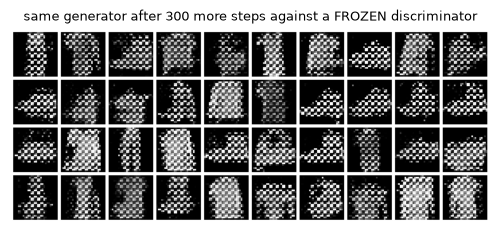

                               class entropy (bits)  relative diversity  top class share
DCGAN (both players training)                  3.28                0.80             0.14
G vs frozen D                                  2.19                0.85             0.34
→ The generator collapsed towards what the frozen discriminator likes: class entropy fell from 3.28 to 2.19 bits, and 'Shirt' now makes up 34% of samples. In the grid, the samples share one artefact pattern.
→ Note: the embedding spread did not drop (artefacts scatter the judge's features), so spread alone can miss collapse. Section 8's recall metric is designed to catch it.


In [15]:
collapse_gen, frozen_disc = copy.deepcopy(dc_gen).train(), copy.deepcopy(dc_disc).eval()
for p in frozen_disc.parameters():
    p.requires_grad_(False)
opt_collapse = torch.optim.Adam(collapse_gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
for step in range(300):
    g_loss = F.softplus(-frozen_disc(collapse_gen(torch.randn(128, 64, device=DEVICE)))).mean()
    opt_collapse.zero_grad(set_to_none=True)
    g_loss.backward()
    opt_collapse.step()
collapse_gen.eval()
with torch.inference_mode():
    collapsed_samples = collapse_gen(torch.randn(N_EVAL, 64, generator=torch.Generator().manual_seed(0)).to(DEVICE)).cpu()
col_entropy, col_hist = class_entropy_bits(collapsed_samples)
col_div = relative_diversity(collapsed_samples, ref_feats_500)
show_grid(collapsed_samples[:40], title="same generator after 300 more steps against a FROZEN discriminator")
plt.show()
print(pd.DataFrame({"class entropy (bits)": [dc_entropy, col_entropy], "relative diversity": [dc_div, col_div],
                    "top class share": [dc_hist.max().item(), col_hist.max().item()]},
                   index=["DCGAN (both players training)", "G vs frozen D"]).round(2).to_string())
if col_entropy < dc_entropy - 0.5 or col_hist.max() > 2 * dc_hist.max():
    print(f"→ The generator collapsed towards what the frozen discriminator likes: class entropy fell from {dc_entropy:.2f} to {col_entropy:.2f} bits, "
          f"and '{CLASSES[int(col_hist.argmax())]}' now makes up {col_hist.max():.0%} of samples. In the grid, the samples share one artefact pattern.")
else:
    print("→ The class mix barely changed in this run; compare the two grids by eye, and see the recall column in §8.")
if col_div >= 0.9 * dc_div:
    print("→ Note: the embedding spread did not drop (artefacts scatter the judge's features), so spread alone can miss collapse. "
          "Section 8's recall metric is designed to catch it.")
del collapse_gen, frozen_disc, opt_collapse
free_memory()

**Conditional GANs** (Mirza & Osindero, 2014) feed the label $y$ to both players: $G(z, y)$ must produce class $y$, and $D(x, y)$ must judge whether $x$ is a *real example of class y*. Our `DCGenerator(n_classes=10)` concatenates a label embedding to $z$, and `DCDiscriminator(n_classes=10)` stacks one-hot label planes onto the image. Stronger variants: **projection discriminators** (Miyato & Koyama, 2018) and **AC-GAN**, which adds an auxiliary classifier head. The project trains this conditional DCGAN.

> 💡 **Interview angle:** "How do you know if your GAN collapsed?" — the losses won't tell you. Look at sample grids, class histograms from a pretrained classifier, diversity (pairwise feature distances, LPIPS), and **recall**. Fixes: rebalance D/G, spectral norm, gradient penalties, minibatch discrimination, and label conditioning.

## 6. Diffusion: The Forward Process and Noise Schedules 🟡

Think of a photo left in the rain: over many small steps it fades into random speckle. That fading is easy to simulate. A **diffusion model** learns to run the film **backwards**, removing a little noise per step, until a clean image appears from pure static.

**Forward (noising) process**, fixed and not learned, over $T = 1000$ steps with a variance schedule $\beta_1, \dots, \beta_T$:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\big(\sqrt{1-\beta_t}\,x_{t-1},\; \beta_t I\big)$$

Shrinking by $\sqrt{1-\beta_t}$ keeps the total variance bounded. **Closed form.** Define $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \prod_{s \le t} \alpha_s$. Gaussians compose, so you can jump straight to any step:

$$q(x_t \mid x_0) = \mathcal{N}\big(\sqrt{\bar\alpha_t}\,x_0,\; (1-\bar\alpha_t) I\big) \quad\Longleftrightarrow\quad x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\;\; \varepsilon \sim \mathcal{N}(0, I)$$

This one line is why diffusion training is cheap: pick a random $t$, noise the image in one shot, train.

**Signal-to-noise ratio:** $\text{SNR}(t) = \bar\alpha_t / (1 - \bar\alpha_t)$. The schedule decides how fast SNR falls:

- **Linear** (DDPM, Ho et al., 2020): $\beta_t$ rises linearly from $10^{-4}$ to $0.02$. Images become almost pure noise well before the last step, wasting steps.
- **Cosine** (Improved DDPM, Nichol & Dhariwal, 2021): $\bar\alpha_t = f(t)/f(0)$ with $f(t) = \cos^2\!\big(\frac{t/T + s}{1 + s}\cdot\frac{\pi}{2}\big)$, $s = 0.008$, $\beta_t$ clipped at 0.999. Noise is added more evenly, which matters most for small images.

We follow the diffusers convention: timesteps are indexed $t = 0, \dots, 999$ and `alphas_cumprod[t]` $= \bar\alpha_t$ (so $t=0$ already has a tiny bit of noise).

linear: SNR drops below 1 at t = 259 | ᾱ_999 = 4.04e-05 | steps with ᾱ < 0.001 (almost pure noise): 175
cosine: SNR drops below 1 at t = 496 | ᾱ_999 = 2.43e-09 | steps with ᾱ < 0.001 (almost pure noise): 21


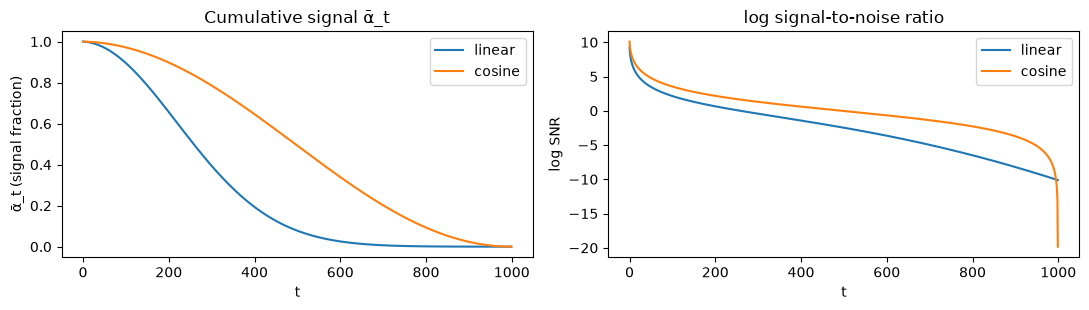

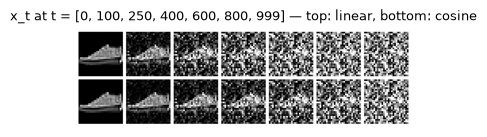

In [16]:
T_STEPS = 1000


def linear_betas(T=T_STEPS, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T, dtype=torch.float64)


def cosine_betas(T=T_STEPS, s=0.008, max_beta=0.999):
    f = lambda t: math.cos((t / T + s) / (1 + s) * math.pi / 2) ** 2
    return torch.tensor([min(1 - f(t + 1) / f(t), max_beta) for t in range(T)], dtype=torch.float64)


schedules = {"linear": torch.cumprod(1 - linear_betas(), dim=0), "cosine": torch.cumprod(1 - cosine_betas(), dim=0)}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for name, abar in schedules.items():
    axes[0].plot(abar, label=name)
    axes[1].plot(torch.log(abar / (1 - abar)), label=name)
    snr_one = int((abar / (1 - abar) < 1).nonzero()[0])
    nearly_noise = int((abar < 1e-3).sum())
    print(f"{name:6s}: SNR drops below 1 at t = {snr_one} | ᾱ_999 = {abar[-1]:.2e} | steps with ᾱ < 0.001 (almost pure noise): {nearly_noise}")
axes[0].set(xlabel="t", ylabel="ᾱ_t (signal fraction)", title="Cumulative signal ᾱ_t")
axes[1].set(xlabel="t", ylabel="log SNR", title="log signal-to-noise ratio")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

x0_img = to_sym(X_val_u8[:1])
shown_t = [0, 100, 250, 400, 600, 800, 999]
noise_img = torch.randn(x0_img.shape, generator=torch.Generator().manual_seed(0))
rows = []
for name, abar in schedules.items():
    for t in shown_t:
        a = abar[t].float()
        rows.append(a.sqrt() * x0_img + (1 - a).sqrt() * noise_img)
show_grid(torch.cat(rows), nrow=len(shown_t), title=f"x_t at t = {shown_t} — top: linear, bottom: cosine")
plt.show()

Let's verify the closed form instead of trusting it: apply the one-step process 400 times to 2,000 real images, then check that $\big(x_{399} - \sqrt{\bar\alpha_{399}}\,x_0\big) / \sqrt{1 - \bar\alpha_{399}}$ looks like standard normal noise.

In [17]:
betas_lin = linear_betas().float()
x0_batch = to_sym(X_train_u8[:2000])
x = x0_batch.clone()
g_iter = torch.Generator().manual_seed(1)
for t in range(400):
    x = (1 - betas_lin[t]).sqrt() * x + betas_lin[t].sqrt() * torch.randn(x.shape, generator=g_iter)
abar_399 = schedules["linear"][399].float()
implied_noise = (x - abar_399.sqrt() * x0_batch) / (1 - abar_399).sqrt()
print(f"after 400 single steps: implied noise mean {implied_noise.mean():+.4f}, std {implied_noise.std():.4f} (closed form says 0 and 1)")
print(f"correlation between x_399 and x_0: {np.corrcoef(x.flatten(), x0_batch.flatten())[0, 1]:.3f} "
      f"(closed form predicts √ᾱ·std(x0)/std(x_t) = {abar_399.sqrt() * x0_batch.std() / x.std():.3f})")

after 400 single steps: implied noise mean +0.0009, std 1.0002 (closed form says 0 and 1)
correlation between x_399 and x_0: 0.330 (closed form predicts √ᾱ·std(x0)/std(x_t) = 0.329)


### ✍️ Your Turn

Use the closed form. A pixel has clean value $x_0 = 0.8$, the drawn noise is $\varepsilon = -1.2$, and $\bar\alpha_t = 0.36$. Store $x_t$ as a float in `x_t_answer`.

In [18]:
x_t_answer = None  # TODO
check("x_t_answer", x_t_answer, -0.48, hint="√0.36 = 0.6 and √(1 − 0.36) = 0.8.")

⏳ x_t_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
abar = 0.36
x_t_answer = math.sqrt(abar) * 0.8 + math.sqrt(1 - abar) * (-1.2)     # 0.48 − 0.96
check("x_t_answer", x_t_answer, -0.48)
```
</details>

> 💡 **Interview angle:** "Why can diffusion training sample any timestep directly?" — the forward process is a chain of Gaussians, so $q(x_t\mid x_0) = \mathcal{N}(\sqrt{\bar\alpha_t}x_0, (1-\bar\alpha_t)I)$ in closed form. One noise draw per example is enough, with no simulation of the chain. Mention SNR and why the cosine schedule avoids wasting the last steps on pure noise.

## 7. Training and Sampling a DDPM 🔴

**What the network learns.** Given a noisy image $x_t$ and its timestep $t$, predict the noise $\varepsilon$ that was added. The DDPM paper's "simple" loss is plain mean squared error:

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{x_0,\,t,\,\varepsilon}\Big[\big\|\varepsilon - \varepsilon_\theta\big(\sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\; t\big)\big\|^2\Big]$$

That's the whole training loop: sample an image, a timestep and noise; noise the image; regress the noise. It is a stable regression problem, unlike a GAN's game. (It is a reweighted version of the ELBO; the variational derivation gives the same Gaussian terms.)

**The network** is a **U-Net**: a CNN encoder-decoder with skip connections, so it sees global shape *and* keeps pixel detail. The timestep enters as a sinusoidal embedding (like transformer positions) added inside every residual block. Ours also receives the **class label** through an embedding. With probability 15% we replace the label by a special **"null" label (index 10)**, so one network learns both $\varepsilon_\theta(x_t, t, y)$ and the unconditional $\varepsilon_\theta(x_t, t)$. Section 10 shows why that matters.

**Sampling (DDPM, Algorithm 2).** Start from $x_{T} \sim \mathcal{N}(0, I)$ and for $t = T, \dots, 1$:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t, t)\Big) + \sigma_t z, \qquad z \sim \mathcal{N}(0, I),\;\; \sigma_t^2 = \tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$$

**Link to score matching.** The *score* of the noisy data distribution, $\nabla_{x_t}\log q(x_t)$, points towards more likely images. An optimal noise predictor satisfies $\varepsilon_\theta(x_t, t) \approx -\sqrt{1-\bar\alpha_t}\,\nabla_{x_t}\log q(x_t)$. So predicting noise *is* estimating the score, and DDPM sampling is a discretised form of Langevin-style dynamics / the reverse SDE (Song et al., 2021). This view unifies diffusion with score-based models and flow matching.

TinyUNet: 633,121 parameters | training budget 3,000 steps × 128 images on mps


3,000 steps in 132s (44 ms/step) = 7.0 epochs | final loss (last 500 steps) 0.0435


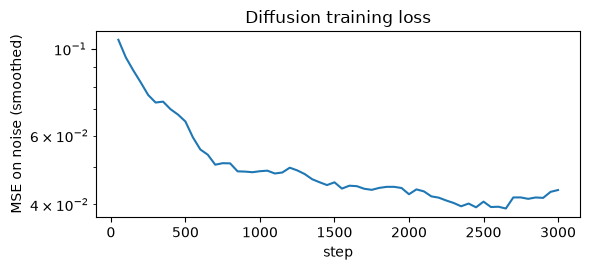

In [19]:
class ResBlock(nn.Module):
    """GroupNorm → SiLU → conv, with the time/label embedding added in the middle, plus a residual connection."""

    def __init__(self, c_in, c_out, emb_dim):
        super().__init__()
        self.norm1, self.conv1 = nn.GroupNorm(8, c_in), nn.Conv2d(c_in, c_out, 3, padding=1)
        self.emb = nn.Linear(emb_dim, c_out)
        self.norm2, self.conv2 = nn.GroupNorm(8, c_out), nn.Conv2d(c_out, c_out, 3, padding=1)
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x))) + self.emb(emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class TinyUNet(nn.Module):
    """A 0.6 M-parameter U-Net for 28×28 images: 28 → 14 → 7 → 14 → 28 with skip connections.
    Conditioning: sinusoidal timestep embedding + class embedding (index 10 = 'no label')."""

    def __init__(self, channels=(32, 64, 128), emb_dim=128, n_classes=10):
        super().__init__()
        c1, c2, c3 = channels
        self.emb_dim, self.null_label = emb_dim, n_classes
        self.time_mlp = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.label_emb = nn.Embedding(n_classes + 1, emb_dim)
        self.inc = nn.Conv2d(1, c1, 3, padding=1)
        self.down1, self.pool1 = ResBlock(c1, c1, emb_dim), nn.Conv2d(c1, c1, 3, stride=2, padding=1)
        self.down2, self.pool2 = ResBlock(c1, c2, emb_dim), nn.Conv2d(c2, c2, 3, stride=2, padding=1)
        self.mid1, self.mid2 = ResBlock(c2, c3, emb_dim), ResBlock(c3, c2, emb_dim)
        self.up2, self.up1 = ResBlock(2 * c2, c1, emb_dim), ResBlock(2 * c1, c1, emb_dim)
        self.out = nn.Sequential(nn.GroupNorm(8, c1), nn.SiLU(), nn.Conv2d(c1, 1, 3, padding=1))

    def timestep_embedding(self, t):
        half = self.emb_dim // 2
        freqs = torch.exp(-math.log(10_000) * torch.arange(half, device=t.device) / half)
        angles = t.float()[:, None] * freqs[None, :]
        return torch.cat([angles.sin(), angles.cos()], dim=1)

    def forward(self, x, t, labels):
        emb = self.time_mlp(self.timestep_embedding(t)) + self.label_emb(labels)
        h1 = self.down1(self.inc(x), emb)                                  # 28×28
        h2 = self.down2(self.pool1(h1), emb)                               # 14×14
        h = self.mid2(self.mid1(self.pool2(h2), emb), emb)                 # 7×7
        h = self.up2(torch.cat([F.interpolate(h, scale_factor=2.0), h2], dim=1), emb)
        h = self.up1(torch.cat([F.interpolate(h, scale_factor=2.0), h1], dim=1), emb)
        return self.out(h)                                                 # predicted noise, same shape as x


ddpm_scheduler = DDPMScheduler(num_train_timesteps=T_STEPS, beta_schedule="linear", clip_sample=False)
ALPHAS_CUMPROD = ddpm_scheduler.alphas_cumprod.to(DEVICE)
P_UNCOND = 0.15
seed_everything(SEED)
unet = TinyUNet().to(DEVICE)
ema_unet = copy.deepcopy(unet).requires_grad_(False)                           # exponential moving average (EMA) of the weights
unet_opt = torch.optim.AdamW(unet.parameters(), lr=1e-3, weight_decay=0.0)


@torch.no_grad()
def update_ema(ema_model, model, step, max_decay=0.999):
    """EMA with warm-up: the decay grows from 0.1 towards 0.999, so the early, poor weights are forgotten quickly."""
    decay = min(max_decay, (1 + step) / (10 + step))
    for ema_p, p in zip(ema_model.parameters(), model.parameters()):
        ema_p.lerp_(p, 1 - decay)


print(f"TinyUNet: {n_params(unet):,} parameters | training budget {BUDGET_STEPS:,} steps × 128 images on {DEVICE}")
g_diff = torch.Generator().manual_seed(SEED)
diff_losses = []
start = time.perf_counter()
for diff_step in range(BUDGET_STEPS):
    idx = torch.randint(0, len(X_train_dev), (128,), generator=g_diff).to(DEVICE)
    x0 = to_sym(X_train_dev[idx])
    labels = y_train_dev[idx]
    labels = torch.where(torch.rand(len(labels), device=DEVICE) < P_UNCOND, torch.full_like(labels, 10), labels)   # label dropout
    t = torch.randint(0, T_STEPS, (len(x0),), device=DEVICE)
    noise = torch.randn_like(x0)
    abar = ALPHAS_CUMPROD[t].view(-1, 1, 1, 1)
    x_t = abar.sqrt() * x0 + (1 - abar).sqrt() * noise                    # closed-form forward process
    loss = F.mse_loss(unet(x_t, t, labels), noise)                         # ε-prediction objective
    unet_opt.zero_grad(set_to_none=True)
    loss.backward()
    unet_opt.step()
    update_ema(ema_unet, unet, diff_step)
    if (diff_step + 1) % 50 == 0:
        diff_losses.append(loss.item())
sync()
diff_steps = BUDGET_STEPS
diffusion_train_seconds = time.perf_counter() - start
print(f"{diff_steps:,} steps in {diffusion_train_seconds:.0f}s ({diffusion_train_seconds / diff_steps * 1000:.0f} ms/step) "
      f"= {diff_steps * 128 / len(X_train_u8):.1f} epochs | final loss (last 500 steps) {np.mean(diff_losses[-10:]):.4f}")
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(np.arange(1, len(diff_losses) + 1) * 50, pd.Series(diff_losses).rolling(10, min_periods=1).mean())
ax.set(xlabel="step", ylabel="MSE on noise (smoothed)", title="Diffusion training loss", yscale="log")
plt.tight_layout()
plt.show()
denoiser = ema_unet.eval()                 # sample with the EMA weights (section 9 checks this choice)
free_memory()

Now **Algorithm 2 from scratch**: 1,000 denoising steps, no library scheduler. We generate $N_{\text{EVAL}} = 500$ class-conditional images (50 per class) and time it. Sections 8 and 9 reuse them.

1,000-step DDPM sampling of 500 images: 43.9s (88 ms per image)


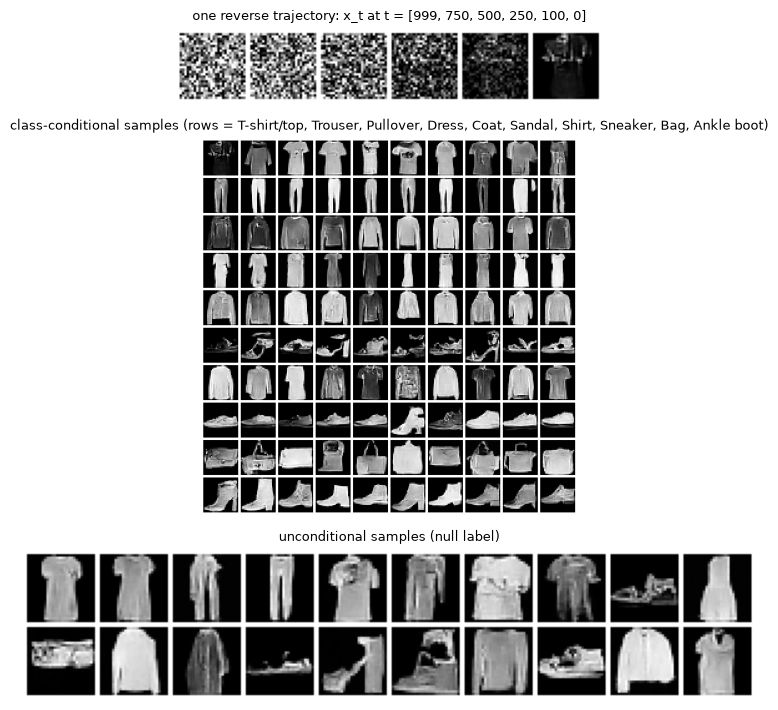

In [20]:
@torch.inference_mode()
def ddpm_sample_from_scratch(model, labels, seed=0, record=(999, 750, 500, 250, 100, 0), batch_size=250):
    """Ancestral DDPM sampling (Ho et al. 2020, Algorithm 2) with σ_t² = β̃_t. Returns images in [-1, 1] and snapshots of image 0."""
    betas = ddpm_scheduler.betas.to(DEVICE)
    alphas, abars = 1 - betas, ALPHAS_CUMPROD
    g = torch.Generator().manual_seed(seed)
    outputs, snapshots = [], []
    for k in range(0, len(labels), batch_size):
        y = labels[k:k + batch_size].to(DEVICE)
        x = torch.randn(len(y), 1, 28, 28, generator=g).to(DEVICE)
        for t in range(T_STEPS - 1, -1, -1):
            t_batch = torch.full((len(y),), t, device=DEVICE)
            eps = model(x, t_batch, y)
            mean = (x - betas[t] / (1 - abars[t]).sqrt() * eps) / alphas[t].sqrt()
            if t > 0:
                var = (1 - abars[t - 1]) / (1 - abars[t]) * betas[t]
                x = mean + var.sqrt() * torch.randn(x.shape, generator=g).to(DEVICE)
            else:
                x = mean
            if k == 0 and t in record:
                snapshots.append((t, x[:1].clamp(-1, 1).cpu()))
        outputs.append(x.clamp(-1, 1).cpu())
    return torch.cat(outputs), snapshots


EVAL_LABELS = torch.arange(10).repeat_interleave(N_EVAL // 10)          # 50 of each class
start = time.perf_counter()
ddpm1000_samples, ddpm_snapshots = ddpm_sample_from_scratch(denoiser, EVAL_LABELS)
sync()
ddpm1000_seconds = time.perf_counter() - start
unconditional_ddpm, _ = ddpm_sample_from_scratch(denoiser, torch.full((20,), 10), seed=1)
print(f"1,000-step DDPM sampling of {N_EVAL} images: {ddpm1000_seconds:.1f}s ({ddpm1000_seconds / N_EVAL * 1000:.0f} ms per image)")

fig, axes = plt.subplots(3, 1, figsize=(8, 7.2), gridspec_kw={"height_ratios": [1, 5, 2]})
show_grid(torch.cat([s for _, s in ddpm_snapshots]), nrow=len(ddpm_snapshots),
          title=f"one reverse trajectory: x_t at t = {[t for t, _ in ddpm_snapshots]}", ax=axes[0])
show_grid(ddpm1000_samples.view(10, 50, 1, 28, 28)[:, :10].reshape(100, 1, 28, 28), title="class-conditional samples (rows = " + ", ".join(CLASSES) + ")", ax=axes[1])
show_grid(unconditional_ddpm, title="unconditional samples (null label)", ax=axes[2])
plt.tight_layout()
plt.show()

**Score check.** For a single known data point $x_0$, $q(x_t) = \mathcal{N}(\sqrt{\bar\alpha_t}x_0, (1-\bar\alpha_t)I)$, so autograd can compute the true score and compare it with $-\varepsilon/\sqrt{1-\bar\alpha_t}$.

In [21]:
t_chk = 300
abar_chk = ddpm_scheduler.alphas_cumprod[t_chk].double()
x0_pt = to_sym(X_val_u8[:1]).double()
eps_true = torch.randn(x0_pt.shape, generator=torch.Generator().manual_seed(3), dtype=torch.float64)
x_t_chk = (abar_chk.sqrt() * x0_pt + (1 - abar_chk).sqrt() * eps_true).requires_grad_(True)
log_q = torch.distributions.Normal(abar_chk.sqrt() * x0_pt, (1 - abar_chk).sqrt()).log_prob(x_t_chk).sum()
true_score = torch.autograd.grad(log_q, x_t_chk)[0]
print("score from autograd == −ε / √(1 − ᾱ_t):", torch.allclose(true_score, -eps_true / (1 - abar_chk).sqrt()))

score from autograd == −ε / √(1 − ᾱ_t): True


### ✍️ Your Turn

Every sampler first estimates the clean image from the noise prediction: $\hat x_0 = \big(x_t - \sqrt{1-\bar\alpha_t}\,\hat\varepsilon\big)/\sqrt{\bar\alpha_t}$. With $x_t = 0.5$, $\hat\varepsilon = 0.2$, $\bar\alpha_t = 0.64$, store $\hat x_0$ in `x0_hat_answer`.

In [22]:
x0_hat_answer = None  # TODO
check("x0_hat_answer", x0_hat_answer, 0.475, hint="(0.5 − 0.6 · 0.2) / 0.8")

⏳ x0_hat_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
abar = 0.64
x0_hat_answer = (0.5 - math.sqrt(1 - abar) * 0.2) / math.sqrt(abar)
check("x0_hat_answer", x0_hat_answer, 0.475)
```

It is just the closed-form forward equation solved for $x_0$. DDIM (section 9) is built from this estimate.
</details>

> 💡 **Interview angle:** "How is a diffusion model trained and sampled?" — **train:** pick an image, a random $t$ and Gaussian noise, form $x_t$ in closed form, and regress the noise with MSE (U-Net conditioned on $t$). **Sample:** start from pure noise and apply the learned denoising step $T$ times, each step moving towards the predicted clean image and re-injecting a little noise. Mention that $\varepsilon$-prediction is equivalent to score estimation, and that EMA weights are used for sampling.

## 8. Evaluating Generative Models: FID, IS, Precision and Recall 🟡

There is no "correct answer" to compare a generated image with, so we measure several properties separately:

| Property | Question | Metric |
|---|---|---|
| **Fidelity** | do samples look real? | precision, FID (partly), human ratings |
| **Diversity / coverage** | are all kinds of real data produced? | recall, FID (partly), class histograms |
| **Novelty** | are samples new, not copies? | nearest-training-neighbour distances |
| **Alignment** | does the image match the class or prompt? | classifier accuracy, CLIP score, VQA-based checks |

**Fréchet Inception Distance** (FID; Heusel et al., 2017). Embed real and generated images with a pretrained network (Inception-v3's 2,048-d pool features), fit a Gaussian $\mathcal{N}(\mu, \Sigma)$ to each set, and compute the Fréchet (2-Wasserstein) distance between the two Gaussians. **Lower is better.**

$$\text{FID} = \lVert \mu_r - \mu_g \rVert^2 + \operatorname{Tr}\!\big(\Sigma_r + \Sigma_g - 2\,(\Sigma_r \Sigma_g)^{1/2}\big)$$

⚠️ **Our "feature-FID" uses the 64-d embedding of the Fashion-MNIST judge, not Inception-v3**, because Inception features are made for ImageNet photos. The formula is identical, but **these numbers are not comparable to published Inception-FID values**. They only compare models inside this notebook, with the same judge, the same reference set and the same number of samples.

**Inception Score** (IS; Salimans et al., 2016): $\exp\big(\mathbb{E}_x\,\mathrm{KL}(p(y\mid x)\,\|\,p(y))\big)$, computed from a classifier's predictions. It is high when each sample is confidently one class *and* all classes appear. It never looks at real data, so it can't tell you whether a "confident coat" looks like a real coat.

**Precision and recall for generative models** (Kynkäänniemi et al., 2019): approximate the real-data "manifold" by balls reaching each real feature's k-th nearest real neighbour. **Precision** = share of generated samples inside the real manifold (fidelity). **Recall** = share of real samples inside the generated manifold (coverage). Mode collapse shows up as low recall.

**FID pitfalls:** it is **biased by sample size** (fewer samples → higher FID, even for real data); sensitive to **resizing and JPEG details** (Parmar et al., 2022); tied to one feature extractor; blind to **memorization**; mixes fidelity and diversity into one number; and ignores prompt alignment. That is why teams still run **human evaluations** (side-by-side preference, artefact spotting) and learned preference scores before shipping.

In [23]:
def gaussian_stats(feats):
    return feats.mean(axis=0), np.cov(feats, rowvar=False)


def frechet_distance_scipy(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Reference Fréchet distance between N(mu1, sigma1) and N(mu2, sigma2) using scipy's matrix square root."""
    offset = eps * np.eye(len(mu1))
    s1, s2 = sigma1 + offset, sigma2 + offset
    root1 = scipy.linalg.sqrtm(s1).real
    cross = scipy.linalg.sqrtm(root1 @ s2 @ root1).real       # same trace as sqrtm(s1 @ s2), but symmetric → numerically stable
    return float(np.sum((mu1 - mu2) ** 2) + np.trace(s1) + np.trace(s2) - 2 * np.trace(cross))


def inception_style_score(probs):
    p_y = probs.mean(dim=0, keepdim=True)
    return (probs * (torch.log(probs + 1e-12) - torch.log(p_y + 1e-12))).sum(dim=1).mean().exp().item()


def precision_recall(real_feats, fake_feats, k=3):
    """Kynkäänniemi et al. (2019) k-NN precision and recall."""
    real, fake = torch.tensor(real_feats, dtype=torch.float32), torch.tensor(fake_feats, dtype=torch.float32)
    real_radii = torch.cdist(real, real).kthvalue(k + 1, dim=1).values      # k+1: each point's nearest neighbour is itself
    fake_radii = torch.cdist(fake, fake).kthvalue(k + 1, dim=1).values
    precision = (torch.cdist(fake, real) <= real_radii[None, :]).any(dim=1).float().mean().item()
    recall = (torch.cdist(real, fake) <= fake_radii[None, :]).any(dim=1).float().mean().item()
    return precision, recall


def within_class_diversity(feats, labels, real_class_feats):
    """Mean pairwise embedding distance inside each requested class, relative to real images of that class (1.0 = as varied)."""
    ratios = []
    for c in range(10):
        fake_c, real_c = torch.tensor(feats[(labels == c).numpy()]), torch.tensor(real_class_feats[c])
        ratios.append(torch.pdist(fake_c).mean().item() / torch.pdist(real_c).mean().item())
    return float(np.mean(ratios))


VAL_STATS = gaussian_stats(val_feats)                                      # reference for all model choices (never the test set)
REAL_PR_FEATS = val_feats[-N_EVAL:]
VAL_CLASS_FEATS = {c: val_feats[(y_val == c).numpy()][:50] for c in range(10)}


def eval_row(images_sym, labels=None):
    feats, probs = judge_features(images_sym)
    precision, recall = precision_recall(REAL_PR_FEATS, feats)
    row = {"feature-FID": frechet_distance_scipy(*gaussian_stats(feats), *VAL_STATS), "IS (judge)": inception_style_score(probs),
           "precision": precision, "recall": recall}
    if labels is not None:
        row["class accuracy"] = (probs.argmax(1) == labels).float().mean().item()
        row["within-class diversity"] = within_class_diversity(feats, labels, VAL_CLASS_FEATS)
    return row


with torch.inference_mode():
    vae_samples = torch.sigmoid(vae.decode(torch.randn(N_EVAL, 16, generator=torch.Generator().manual_seed(0)).to(DEVICE))).cpu() * 2 - 1
candidates = {
    "copy-paste 500 training images (memorizer)": to_sym(X_train_u8[:N_EVAL]),
    "VAE (§2), prior samples": vae_samples,
    "DCGAN (§5)": dcgan_samples,
    "DCGAN after collapse (§5)": collapsed_samples,
    "DDPM 1,000 steps, conditional (§7)": ddpm1000_samples,
}
eval_table = pd.DataFrame({name: eval_row(imgs) for name, imgs in candidates.items()}).T
print(f"all rows use N = {N_EVAL} samples; FID reference = 5,000 validation images; precision/recall vs 500 other validation images")
print(eval_table.round(3).to_string())
models_only = eval_table.drop(index="copy-paste 500 training images (memorizer)")
print(f"\n→ Best generator by feature-FID: {models_only['feature-FID'].idxmin()}")
print(f"→ The memorizer scores FID {eval_table.iloc[0]['feature-FID']:.1f} with perfect-looking samples: FID cannot detect copying.")
print(f"→ Collapse cut DCGAN recall from {eval_table.loc['DCGAN (§5)', 'recall']:.2f} to {eval_table.loc['DCGAN after collapse (§5)', 'recall']:.2f} "
      f"while its IS went from {eval_table.loc['DCGAN (§5)', 'IS (judge)']:.2f} to {eval_table.loc['DCGAN after collapse (§5)', 'IS (judge)']:.2f}.")

all rows use N = 500 samples; FID reference = 5,000 validation images; precision/recall vs 500 other validation images
                                            feature-FID  IS (judge)  precision  recall
copy-paste 500 training images (memorizer)       13.993       7.537      0.902   0.884
VAE (§2), prior samples                        1388.932       4.251      0.658   0.088
DCGAN (§5)                                      173.207       4.549      0.700   0.522
DCGAN after collapse (§5)                      4391.643       2.779      0.052   0.004
DDPM 1,000 steps, conditional (§7)               68.944       7.135      0.932   0.716

→ Best generator by feature-FID: DDPM 1,000 steps, conditional (§7)
→ The memorizer scores FID 14.0 with perfect-looking samples: FID cannot detect copying.
→ Collapse cut DCGAN recall from 0.52 to 0.00 while its IS went from 4.55 to 2.78.


**FID depends on N.** Even real images score worse with fewer samples, because the covariance estimate is noisier. We compare real training subsets of different sizes with the same validation reference.

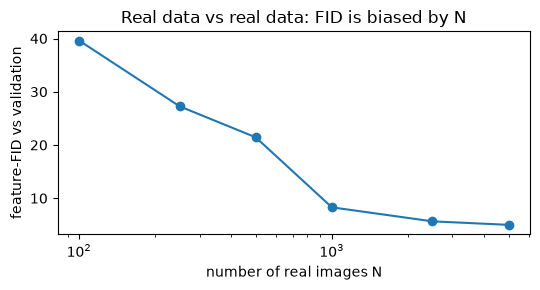

N=100: 39.62, N=250: 27.26, N=500: 21.43, N=1000: 8.29, N=2500: 5.65, N=5000: 5.00
→ Real images at N=100 score 8× the FID they get at N=5,000. Only compare FIDs computed with the same N.


In [24]:
sizes = [100, 250, 500, 1000, 2500, 5000]
real_fid_by_n = [frechet_distance_scipy(*gaussian_stats(judge_features(to_sym(X_train_u8[-n:]))[0]), *VAL_STATS) for n in sizes]
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot(sizes, real_fid_by_n, marker="o")
ax.set(xscale="log", xlabel="number of real images N", ylabel="feature-FID vs validation", title="Real data vs real data: FID is biased by N")
plt.tight_layout()
plt.show()
print(", ".join(f"N={n}: {v:.2f}" for n, v in zip(sizes, real_fid_by_n)))
print(f"→ Real images at N=100 score {real_fid_by_n[0] / real_fid_by_n[-1]:.0f}× the FID they get at N=5,000. Only compare FIDs computed with the same N.")

### ✍️ Your Turn

In one dimension the Fréchet distance between $\mathcal{N}(\mu_1, \sigma_1^2)$ and $\mathcal{N}(\mu_2, \sigma_2^2)$ is $(\mu_1-\mu_2)^2 + \sigma_1^2 + \sigma_2^2 - 2\sigma_1\sigma_2 = (\mu_1-\mu_2)^2 + (\sigma_1-\sigma_2)^2$. Compute it for $\mathcal{N}(0, 1)$ and $\mathcal{N}(1, 4)$ (variance 4, so σ = 2) and store it in `fd_1d`.

In [25]:
fd_1d = None  # TODO
check("fd_1d", fd_1d, 2.0, hint="(0 − 1)² + (1 − 2)²")

⏳ fd_1d: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mu1, sd1, mu2, sd2 = 0.0, 1.0, 1.0, 2.0
fd_1d = (mu1 - mu2) ** 2 + (sd1 - sd2) ** 2
check("fd_1d", fd_1d, 2.0)
print(frechet_distance_scipy(np.array([mu1]), np.array([[sd1 ** 2]]), np.array([mu2]), np.array([[sd2 ** 2]]), eps=0))   # same answer
```

A common slip is plugging in the variance (4) where the formula needs the standard deviation (2).
</details>

> 💡 **Interview angle:** "What's wrong with FID?" — it is biased by sample size (compare only at equal N, ideally ≥ 10k–50k), depends on the feature network and on image resizing/compression details, can't detect memorization, collapses fidelity and diversity into one number, and ignores prompt alignment. Report precision/recall, a CLIP-style alignment score and a human preference study alongside it.

## 9. Faster Sampling With DDIM 🟡

Our 1,000-step sampler took a long time for 500 tiny images. **DDIM** (Song, Meng & Ermon, 2020) samples with **the same trained network**, in far fewer steps.

**Key insight.** The DDPM loss only involves the marginals $q(x_t\mid x_0)$, never the step-by-step chain. Many different *reverse* processes share those marginals, including a **deterministic** one. From the current estimate of the clean image $\hat x_0$ and of the noise $\hat\varepsilon$, jump directly to an earlier timestep $t' < t$:

$$x_{t'} = \sqrt{\bar\alpha_{t'}}\;\hat x_0 \;+\; \sqrt{1-\bar\alpha_{t'} - \sigma_t^2}\;\hat\varepsilon \;+\; \sigma_t z, \qquad \hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\hat\varepsilon}{\sqrt{\bar\alpha_t}}$$

with $\sigma_t = \eta\sqrt{\frac{1-\bar\alpha_{t'}}{1-\bar\alpha_t}}\sqrt{1-\frac{\bar\alpha_t}{\bar\alpha_{t'}}}$. $\eta = 1$ recovers DDPM-like randomness; **$\eta = 0$ is fully deterministic**, and the timesteps can skip (e.g. 980, 960, …, 0).

| | DDPM | DDIM (η = 0) |
|---|---|---|
| Reverse process | stochastic (fresh noise every step) | deterministic (an ODE-like path) |
| Steps | ~1,000 (quality drops fast when you skip) | 10–100 |
| Same noise → same image? | no | **yes**, which enables inversion, interpolation and editing |
| Retraining needed? | — | **no**, just swap the scheduler |

Newer samplers go further: DPM-Solver++ and UniPC (higher-order ODE solvers, ~10–20 steps), and **distillation** (progressive distillation, consistency models, LCM, adversarial distillation as in SD-Turbo) reaches 1–4 steps.

In diffusers, swapping samplers is one line: `DDIMScheduler.from_config(ddpm_scheduler.config)`.

500 class-conditional images per row, same trained network (EMA weights), guidance scale 1
                                     network calls  seconds  feature-FID  class accuracy  precision  recall
sampler                                                                                                    
DDIM 5 steps                                     5    0.251      616.403           0.816      0.896   0.230
DDIM 10 steps                                   10    0.416      271.811           0.830      0.898   0.604
DDIM 25 steps                                   25    1.034      122.239           0.806      0.868   0.754
DDIM 50 steps                                   50    2.218       89.804           0.800      0.858   0.790
DDIM 100 steps                                 100    4.410       81.052           0.800      0.856   0.798
DDPM 50 steps (skipping)                        50    2.246      128.156           0.882      0.936   0.648
DDPM 1,000 steps (§7, from scratch)          

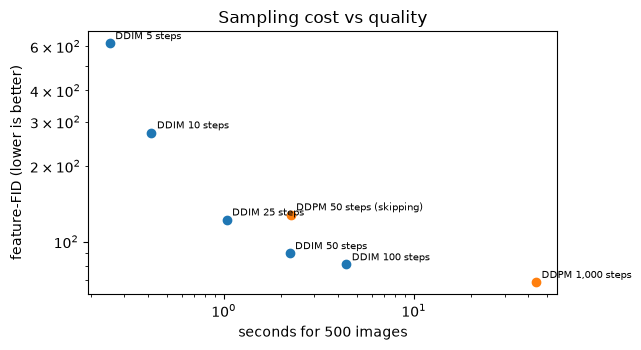

→ No DDIM setting is within 10% of the best FID (68.9, DDPM 1,000 steps (§7, from scratch)); the closest is DDIM 100 steps.
→ With only 50 steps the stochastic DDPM sampler scores FID 128.2 vs 89.8 for DDIM: skipping steps needs a sampler designed for it.
DDIM (η=0) run twice from the same starting noise → max pixel difference 0.00e+00 (deterministic)


In [26]:
@torch.inference_mode()
def sample_with_scheduler(model, scheduler, labels, num_steps, guidance_scale=1.0, seed=0, batch_size=500):
    """Sample with any diffusers scheduler. guidance_scale: 0 = unconditional, 1 = conditional, >1 = classifier-free guidance."""
    scheduler.set_timesteps(num_steps)
    g = torch.Generator().manual_seed(seed)
    outputs = []
    for k in range(0, len(labels), batch_size):
        y = labels[k:k + batch_size].to(DEVICE)
        null = torch.full_like(y, model.null_label)
        x = torch.randn(len(y), 1, 28, 28, generator=g).to(DEVICE)
        for t in scheduler.timesteps:
            t_batch = torch.full((len(y),), int(t), device=DEVICE)
            if guidance_scale == 1.0:
                eps = model(x, t_batch, y)
            elif guidance_scale == 0.0:
                eps = model(x, t_batch, null)
            else:                                                       # one batched call for both branches
                eps_uncond, eps_cond = model(torch.cat([x, x]), torch.cat([t_batch, t_batch]), torch.cat([null, y])).chunk(2)
                eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
            x = scheduler.step(eps, t, x, generator=g).prev_sample
        outputs.append(x.clamp(-1, 1).cpu())
    return torch.cat(outputs)


ddim = DDIMScheduler.from_config(ddpm_scheduler.config)          # inherits clip_sample=False from our DDPM config (see ⚠️ Pitfall 3)
lib_ddpm = DDPMScheduler.from_config(ddpm_scheduler.config)
sample_with_scheduler(denoiser, ddim, EVAL_LABELS[:10], 2)        # warm-up so the first timing isn't inflated

sampler_rows = []
for steps in [5, 10, 25, 50, 100]:
    start = time.perf_counter()
    imgs = sample_with_scheduler(denoiser, ddim, EVAL_LABELS, steps)
    sync()
    sampler_rows.append({"sampler": f"DDIM {steps} steps", "network calls": steps, "seconds": time.perf_counter() - start, **eval_row(imgs, EVAL_LABELS)})
start = time.perf_counter()
imgs = sample_with_scheduler(denoiser, lib_ddpm, EVAL_LABELS, 50)
sync()
sampler_rows.append({"sampler": "DDPM 50 steps (skipping)", "network calls": 50, "seconds": time.perf_counter() - start, **eval_row(imgs, EVAL_LABELS)})
sampler_rows.append({"sampler": "DDPM 1,000 steps (§7, from scratch)", "network calls": 1000, "seconds": ddpm1000_seconds, **eval_row(ddpm1000_samples, EVAL_LABELS)})
sampler_table = pd.DataFrame(sampler_rows).set_index("sampler")[["network calls", "seconds", "feature-FID", "class accuracy", "precision", "recall"]]
print(f"{N_EVAL} class-conditional images per row, same trained network (EMA weights), guidance scale 1")
print(sampler_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for name, row in sampler_table.iterrows():
    ax.scatter(row["seconds"], row["feature-FID"], color="tab:blue" if name.startswith("DDIM") else "tab:orange")
    ax.annotate(name.replace(" (§7, from scratch)", ""), (row["seconds"], row["feature-FID"]), fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set(xscale="log", yscale="log", xlabel=f"seconds for {N_EVAL} images", ylabel="feature-FID (lower is better)", title="Sampling cost vs quality")
plt.tight_layout()
plt.show()

best_fid = sampler_table["feature-FID"].min()
ddim_rows = sampler_table[sampler_table.index.str.startswith("DDIM")]
good_enough = ddim_rows[ddim_rows["feature-FID"] <= 1.10 * best_fid]
if len(good_enough):
    pick = good_enough["network calls"].idxmin()
    print(f"→ {pick} is within 10% of the best FID ({best_fid:.1f}) at "
          f"{ddpm1000_seconds / sampler_table.loc[pick, 'seconds']:.0f}× the speed of 1,000-step DDPM.")
else:
    pick = ddim_rows["feature-FID"].idxmin()
    print(f"→ No DDIM setting is within 10% of the best FID ({best_fid:.1f}, {sampler_table['feature-FID'].idxmin()}); the closest is {pick}.")
print(f"→ With only 50 steps the stochastic DDPM sampler scores FID {sampler_table.loc['DDPM 50 steps (skipping)', 'feature-FID']:.1f} "
      f"vs {sampler_table.loc['DDIM 50 steps', 'feature-FID']:.1f} for DDIM: skipping steps needs a sampler designed for it.")

same_a = sample_with_scheduler(denoiser, ddim, EVAL_LABELS[:10], 25, seed=123)
same_b = sample_with_scheduler(denoiser, ddim, EVAL_LABELS[:10], 25, seed=123)
print(f"DDIM (η=0) run twice from the same starting noise → max pixel difference {(same_a - same_b).abs().max():.2e} (deterministic)")

**EMA or raw weights?** We have sampled with the exponential moving average of the weights, the standard choice for diffusion models. Is it the right call for a run this short? Same sampler, same noise, both sets of weights:

In [27]:
raw_ddim_row = eval_row(sample_with_scheduler(unet.eval(), ddim, EVAL_LABELS, 25), EVAL_LABELS)
ema_ddim_row = sampler_table.loc["DDIM 25 steps"]
print(f"DDIM 25 steps → EMA weights: feature-FID {ema_ddim_row['feature-FID']:.1f}, accuracy {ema_ddim_row['class accuracy']:.3f} | "
      f"raw weights: feature-FID {raw_ddim_row['feature-FID']:.1f}, accuracy {raw_ddim_row['class accuracy']:.3f}")
if ema_ddim_row["feature-FID"] < 0.95 * raw_ddim_row["feature-FID"]:
    print("→ EMA gives clearly better samples here, at zero extra training cost.")
else:
    print(f"→ On this short run EMA is not clearly better: a decay of 0.999 averages over roughly the last 1,000 of our {BUDGET_STEPS:,} steps, "
          "so it still carries weights from earlier in training. EMA pays off on long runs (100k+ steps) or with a smaller decay; tune it on validation like any hyperparameter.")

DDIM 25 steps → EMA weights: feature-FID 122.2, accuracy 0.806 | raw weights: feature-FID 112.3, accuracy 0.776
→ On this short run EMA is not clearly better: a decay of 0.999 averages over roughly the last 1,000 of our 3,000 steps, so it still carries weights from earlier in training. EMA pays off on long runs (100k+ steps) or with a smaller decay; tune it on validation like any hyperparameter.


### ✍️ Your Turn

diffusers' default `timestep_spacing="leading"` picks inference timesteps `range(0, 1000, 1000 // steps)`, reversed. For **20** inference steps, which **first three** timesteps does DDIM visit? Store a list of ints in `first_three_timesteps` (work it out first, then check with `DDIMScheduler`).

In [28]:
first_three_timesteps = None  # TODO
_reference_sched = DDIMScheduler(num_train_timesteps=1000)
_reference_sched.set_timesteps(20)
check("first_three_timesteps", first_three_timesteps, _reference_sched.timesteps[:3].tolist(), hint="1000 // 20 = 50, so the largest is 19 · 50.")

⏳ first_three_timesteps: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
stride = 1000 // 20
first_three_timesteps = [19 * stride, 18 * stride, 17 * stride]       # [950, 900, 850]
_reference_sched = DDIMScheduler(num_train_timesteps=1000)
_reference_sched.set_timesteps(20)
check("first_three_timesteps", first_three_timesteps, _reference_sched.timesteps[:3].tolist())
```

"Leading" spacing never visits t = 999, so sampling starts from slightly-less-than-pure noise. The "trailing" option (and zero-terminal-SNR schedules) fix this for high-resolution models that must produce very dark or very bright images.
</details>

> 💡 **Interview angle:** "DDPM vs DDIM?" — same training, different sampler. DDPM's reverse process is a stochastic Markov chain that needs ~1,000 steps; DDIM defines a non-Markovian process with the same marginals whose η = 0 version is deterministic, so it can jump between widely spaced timesteps (10–50 steps) and maps each noise to a fixed image, which enables inversion and editing.

## 10. Classifier-Free Guidance 🔴

Conditional samples at guidance scale 1 are often vague: the model spreads probability over everything that *could* be a shirt. **Guidance** trades some diversity for samples that are unmistakably the requested class.

- **Classifier guidance** (Dhariwal & Nichol, 2021) adds the gradient of a separate classifier trained on *noisy* images. It works, but needs that extra classifier.
- **Classifier-free guidance (CFG)** (Ho & Salimans, 2022) trains **one** network with **label dropout** (our 15% "null" labels in §7). At sampling time it runs the network twice and extrapolates away from the unconditional prediction:

$$\hat\varepsilon = \varepsilon_\theta(x_t, \varnothing) + s\,\big(\varepsilon_\theta(x_t, y) - \varepsilon_\theta(x_t, \varnothing)\big)$$

$s = 0$ is unconditional, $s = 1$ plain conditional, $s > 1$ amplifies "what makes this a shirt". (The paper writes $w = s - 1$; diffusers' `guidance_scale` is $s$.) Because noise predictions are scaled scores, this samples roughly from $p(x\mid y)\,p(y\mid x)^{s-1}$: an *implicit classifier* sharpens the class. The costs: **2× network calls per step** (batched together), and **less diversity** as $s$ grows. Text-to-image models do the same with the prompt, using the empty prompt as $\varnothing$. A **negative prompt** replaces $\varnothing$ with text you want to steer away from.

DDIM 25 steps, 500 images per scale, identical starting noise
                seconds  feature-FID  class accuracy  within-class diversity  precision  recall
guidance scale                                                                                 
0.0               1.090      224.764             NaN                     NaN      0.812   0.674
1.0               1.068      122.239           0.806                   0.929      0.868   0.754
1.5               2.256       75.587           0.904                   0.810      0.916   0.764
2.0               2.224       61.065           0.950                   0.748      0.930   0.724
3.0               2.278       72.098           0.984                   0.680      0.928   0.630
5.0               2.247      139.724           0.998                   0.606      0.888   0.396
8.0               2.254      230.973           0.998                   0.566      0.756   0.150


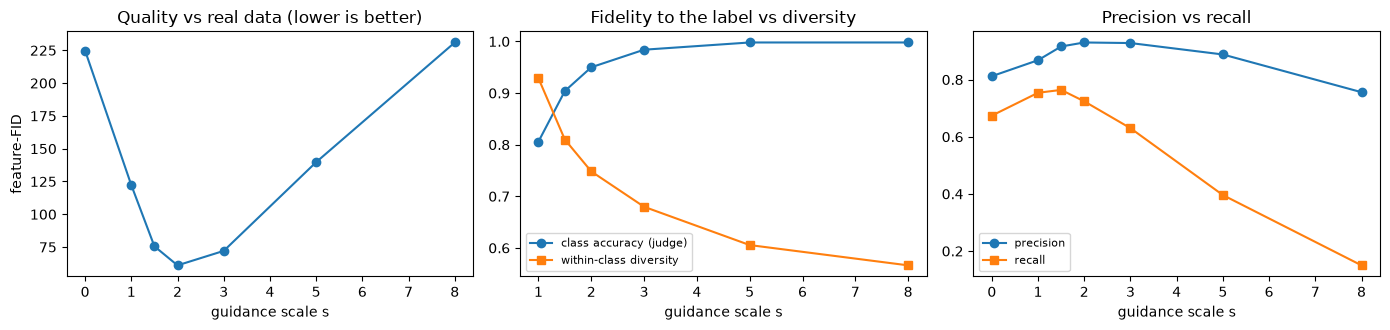

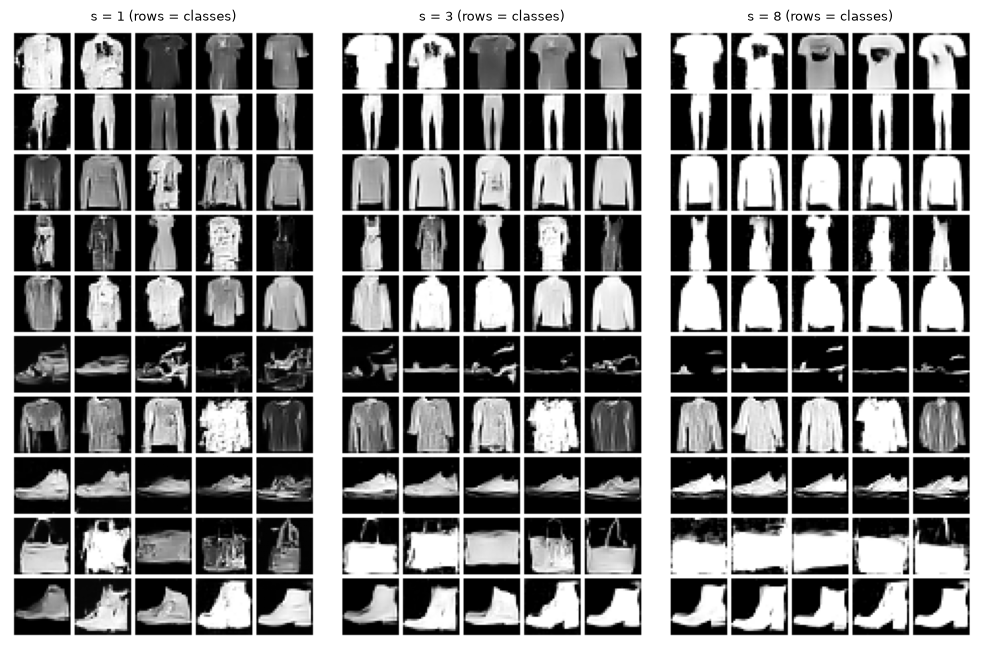

→ Best feature-FID at s = 2 (61.1 vs 122.2 at s = 1); we use s = 2 in the project.
→ From s = 1 to s = 8: class accuracy 0.81 → 1.00, within-class diversity 0.93 → 0.57, recall 0.75 → 0.15.
→ Guidance costs 2.1× the sampling time of s = 1 (two network passes per step).


In [29]:
GUIDANCE_SCALES = [0.0, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
cfg_rows, cfg_images = [], {}
for s in GUIDANCE_SCALES:
    start = time.perf_counter()
    imgs = sample_with_scheduler(denoiser, ddim, EVAL_LABELS, 25, guidance_scale=s)
    sync()
    row = {"guidance scale": s, "seconds": time.perf_counter() - start, **eval_row(imgs, EVAL_LABELS)}
    if s == 0.0:
        row["class accuracy"] = row["within-class diversity"] = float("nan")     # unconditional: the requested labels are ignored
    cfg_rows.append(row)
    cfg_images[s] = imgs
cfg_table = pd.DataFrame(cfg_rows).set_index("guidance scale")[["seconds", "feature-FID", "class accuracy", "within-class diversity", "precision", "recall"]]
print(f"DDIM 25 steps, {N_EVAL} images per scale, identical starting noise")
print(cfg_table.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].plot(cfg_table.index, cfg_table["feature-FID"], marker="o")
axes[0].set(xlabel="guidance scale s", ylabel="feature-FID", title="Quality vs real data (lower is better)")
axes[1].plot(cfg_table.index, cfg_table["class accuracy"], marker="o", label="class accuracy (judge)")
axes[1].plot(cfg_table.index, cfg_table["within-class diversity"], marker="s", label="within-class diversity")
axes[1].set(xlabel="guidance scale s", title="Fidelity to the label vs diversity")
axes[2].plot(cfg_table.index, cfg_table["precision"], marker="o", label="precision")
axes[2].plot(cfg_table.index, cfg_table["recall"], marker="s", label="recall")
axes[2].set(xlabel="guidance scale s", title="Precision vs recall")
for ax in axes[1:]:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(10, 6.4))
for ax, s in zip(axes, [1.0, 3.0, 8.0]):
    show_grid(cfg_images[s].view(10, N_EVAL // 10, 1, 28, 28)[:, :5].reshape(50, 1, 28, 28), nrow=5,
              title=f"s = {s:g} (rows = classes)", ax=ax)
plt.tight_layout()
plt.show()

guided = cfg_table.loc[cfg_table.index >= 1.0]
CFG_SCALE = float(guided["feature-FID"].idxmin())                      # chosen on VALIDATION statistics; the test set stays untouched
print(f"→ Best feature-FID at s = {CFG_SCALE:g} ({guided.loc[CFG_SCALE, 'feature-FID']:.1f} vs {guided.loc[1.0, 'feature-FID']:.1f} at s = 1); "
      f"we use s = {CFG_SCALE:g} in the project.")
print(f"→ From s = 1 to s = {max(GUIDANCE_SCALES):g}: class accuracy {guided.loc[1.0, 'class accuracy']:.2f} → {guided.loc[max(GUIDANCE_SCALES), 'class accuracy']:.2f}, "
      f"within-class diversity {guided.loc[1.0, 'within-class diversity']:.2f} → {guided.loc[max(GUIDANCE_SCALES), 'within-class diversity']:.2f}, "
      f"recall {guided.loc[1.0, 'recall']:.2f} → {guided.loc[max(GUIDANCE_SCALES), 'recall']:.2f}.")
print(f"→ Guidance costs {cfg_table.loc[3.0, 'seconds'] / cfg_table.loc[1.0, 'seconds']:.1f}× the sampling time of s = 1 (two network passes per step).")
del cfg_images
free_memory()

> 💡 **Interview angle:** "What does the guidance scale do?" — CFG mixes conditional and unconditional noise predictions, $\hat\varepsilon = \varepsilon_\varnothing + s(\varepsilon_y - \varepsilon_\varnothing)$, from one model trained with condition dropout. Raising $s$ improves alignment (accuracy, CLIP score) and often FID up to a point, then hurts FID with saturated, same-looking images as diversity and recall fall. It doubles compute per step, which is why distilled models bake guidance in.

## 11. Latent Diffusion, Text-to-Image, and Flow Matching 🔴

**Why latent?** Diffusing 512×512×3 pixels means 786,432 numbers per step, dozens of times, and self-attention cost grows with the *square* of the number of positions. **Latent Diffusion** (Rombach et al., 2022) splits the job:

1. An **autoencoder** (a KL-regularised VAE trained with perceptual and adversarial losses, so reconstructions stay sharp) compresses images by $f = 8$: 512×512×3 → **64×64×4** latents. It removes imperceptible detail.
2. The **diffusion U-Net** learns in that latent space, and the VAE decoder runs **once** at the end.

**Text conditioning.** The prompt is tokenised (77 tokens) and encoded by a **CLIP text encoder** (Radford et al., 2021), trained contrastively so captions land near their matching images (Stable Diffusion 1.x: CLIP ViT-L/14, 768-d per token; SDXL: two CLIP encoders; SD3 and FLUX add a T5 encoder).

**Cross-attention** injects the text inside the U-Net's transformer blocks. **Queries** come from image-latent positions, **keys and values** from text tokens:

$$\text{Attention}(Q, K, V) = \operatorname{softmax}\!\Big(\frac{QK^\top}{\sqrt{d}}\Big)V, \qquad Q = W_Q\,h_{\text{image}},\; K = W_K\,e_{\text{text}},\; V = W_V\,e_{\text{text}}$$

so each image location pulls in information from the words relevant to it.

```
 prompt ─► tokenizer ─► CLIP text encoder ─► 77 × 768 token embeddings ───────────────┐ keys/values
                                                                                    ▼
 z_T ~ N(0, I)  (4×64×64) ─► U-Net ε_θ(z_t, t, text)  ×  N scheduler steps (+ CFG) ─► z_0 ─► VAE decoder ─► 512×512 image
 training:  image ─► VAE encoder ─► z_0 ─► add noise (closed form) ─► U-Net predicts the noise
```

Stable Diffusion 1.5 has a ~860 M-parameter U-Net, an ~84 M VAE and a ~123 M text encoder. The small model below, **BK-SDM-Tiny** (Kim et al., 2023), removes blocks from the SD 1.4 U-Net and distils it from the original, which is why it fits a laptop.

In [30]:
image_px, f_down, latent_ch = 512, 8, 4
pixel_values = 3 * image_px ** 2
latent_values = latent_ch * (image_px // f_down) ** 2
positions_pixel, positions_latent = image_px ** 2, (image_px // f_down) ** 2
print(f"values per diffusion step : pixels {pixel_values:,} vs latents {latent_values:,} → {pixel_values / latent_values:.0f}× fewer")
print(f"self-attention matrix at full resolution: {positions_pixel ** 2:.2e} vs {positions_latent ** 2:.2e} entries → "
      f"{positions_pixel ** 2 / positions_latent ** 2:,.0f}× cheaper in latent space")

# Cross-attention from scratch: 16×16 image-latent positions attend to 77 text tokens
torch.manual_seed(0)
batch, channels, height, width = 2, 64, 16, 16
n_tokens, d_text, d_attn = 77, 768, 64
image_tokens = torch.randn(batch, height * width, channels)             # flattened U-Net feature map
text_tokens = torch.randn(batch, n_tokens, d_text)                       # stand-in for CLIP token embeddings
W_q, W_k, W_v = nn.Linear(channels, d_attn, bias=False), nn.Linear(d_text, d_attn, bias=False), nn.Linear(d_text, d_attn, bias=False)
with torch.no_grad():
    Q, K, V = W_q(image_tokens), W_k(text_tokens), W_v(text_tokens)
    attn_weights = torch.softmax(Q @ K.transpose(1, 2) / math.sqrt(d_attn), dim=-1)     # (batch, 256 image positions, 77 tokens)
    out_scratch = attn_weights @ V
    out_sdpa = F.scaled_dot_product_attention(Q, K, V)
assert torch.allclose(out_scratch, out_sdpa, atol=1e-5)
print(f"\nQ {tuple(Q.shape)} · K {tuple(K.shape)} · V {tuple(V.shape)} → weights {tuple(attn_weights.shape)} → output {tuple(out_scratch.shape)}")
print(f"each image position's weights over the 77 tokens sum to 1: {torch.allclose(attn_weights.sum(-1), torch.ones(batch, height * width))} | "
      "matches F.scaled_dot_product_attention ✅")

values per diffusion step : pixels 786,432 vs latents 16,384 → 48× fewer
self-attention matrix at full resolution: 6.87e+10 vs 1.68e+07 entries → 4,096× cheaper in latent space

Q (2, 256, 64) · K (2, 77, 64) · V (2, 77, 64) → weights (2, 256, 77) → output (2, 256, 64)
each image position's weights over the 77 tokens sum to 1: True | matches F.scaled_dot_product_attention ✅


**Flow matching in one paragraph.** Flow matching (Lipman et al., 2022) and **rectified flow** (Liu et al., 2022) learn a **velocity field** $v_\theta(x, t)$ that carries noise $x_0 \sim \mathcal{N}(0, I)$ to data $x_1$. With straight-line paths $x_t = (1-t)\,x_0 + t\,x_1$, the regression target is simply the direction $x_1 - x_0$:

$$\mathcal{L} = \mathbb{E}_{t, x_0, x_1}\big\|v_\theta(x_t, t) - (x_1 - x_0)\big\|^2$$

Sampling integrates $dx/dt = v_\theta(x, t)$ from $t = 0$ to $1$ with a few Euler steps. Like diffusion, training is simulation-free regression and very stable; diffusion is a special case with a particular curved Gaussian path. Straighter paths need fewer steps, and SD3 and FLUX are trained this way. (Conventions differ: some papers put the noise at $t = 1$.) Let's train one on the 2-D ring where the GAN collapsed.

rectified flow on the 2-D ring trained in 2s
             modes covered / 8  high-quality share  busiest-mode share
Euler steps                                                           
1                            0                0.00                0.23
2                            0                0.02                0.16
5                            8                0.71                0.15
20                           8                0.92                0.15
100                          8                0.95                0.15


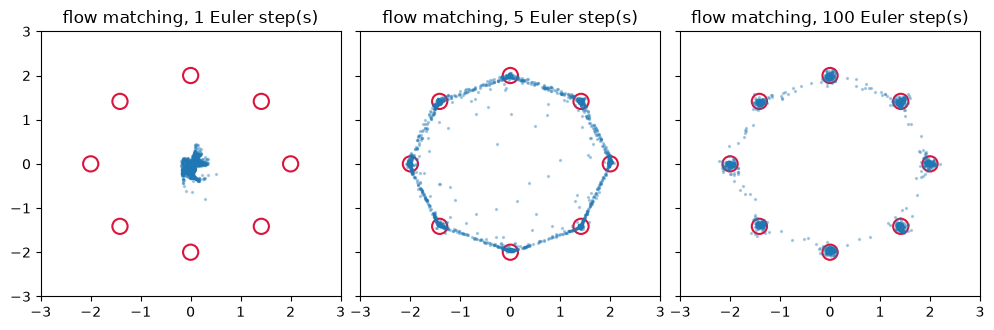

→ With 100 steps the flow covers 8/8 modes (GAN with a weak discriminator: 0/8). One Euler step gives only 0% high-quality samples: at t = 0 the network predicts the *average* direction over all 8 modes, so a single jump lands near the centre. The noise→data paths cross, so they aren't straight; reflow and distillation straighten them.


In [31]:
def train_ring_flow(steps=3000, seed=0, batch_size=256):
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    velocity = mlp(3, 2, hidden=256)                                    # input (x, y, t) → velocity (vx, vy)
    opt = torch.optim.Adam(velocity.parameters(), lr=1e-3)
    for _ in range(steps):
        x1, x0 = ring_batch(batch_size, g), torch.randn(batch_size, 2, generator=g)
        t = torch.rand(batch_size, 1, generator=g)
        x_t = (1 - t) * x0 + t * x1
        loss = F.mse_loss(velocity(torch.cat([x_t, t], dim=1)), x1 - x0)
        opt.zero_grad()
        loss.backward()
        opt.step()
    return velocity


@torch.no_grad()
def flow_sample(velocity, n, n_steps, seed=1):
    x = torch.randn(n, 2, generator=torch.Generator().manual_seed(seed))
    for i in range(n_steps):                                            # Euler integration of dx/dt = v(x, t)
        t = torch.full((n, 1), i / n_steps)
        x = x + velocity(torch.cat([x, t], dim=1)) / n_steps
    return x


start = time.perf_counter()
ring_flow = train_ring_flow()
flow_rows, flow_points = [], {}
for n_steps in [1, 2, 5, 20, 100]:
    pts = flow_sample(ring_flow, 2000, n_steps)
    covered, quality, busiest = mode_stats(pts)
    flow_rows.append({"Euler steps": n_steps, "modes covered / 8": covered, "high-quality share": quality, "busiest-mode share": busiest})
    flow_points[n_steps] = pts
flow_table = pd.DataFrame(flow_rows).set_index("Euler steps")
print(f"rectified flow on the 2-D ring trained in {time.perf_counter() - start:.0f}s")
print(flow_table.round(2).to_string())
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharex=True, sharey=True)
for ax, n_steps in zip(axes, [1, 5, 100]):
    ax.scatter(RING[:, 0], RING[:, 1], s=120, c="none", edgecolors="crimson", lw=1.5)
    ax.scatter(flow_points[n_steps][:, 0], flow_points[n_steps][:, 1], s=2, alpha=0.3)
    ax.set(title=f"flow matching, {n_steps} Euler step(s)", xlim=(-3, 3), ylim=(-3, 3))
plt.tight_layout()
plt.show()
print(f"→ With 100 steps the flow covers {flow_table.loc[100, 'modes covered / 8']}/8 modes "
      f"(GAN with a weak discriminator: {int(ring_table.xs(2000, level='step').iloc[1]['modes covered / 8'])}/8). "
      f"One Euler step gives only {flow_table.loc[1, 'high-quality share']:.0%} high-quality samples: at t = 0 the network predicts the *average* direction "
      "over all 8 modes, so a single jump lands near the centre. The noise→data paths cross, so they aren't straight; reflow and distillation straighten them.")

**Running a real text-to-image model.** The next cell runs **`nota-ai/bk-sdm-tiny`** (fp16 on MPS/CUDA) **only if** the machine has at least `T2I_MIN_FREE_GB` of free memory. It downloads only the fp16 U-Net, VAE and text encoder (~1.06 GB) and measures latency for different step counts and guidance scales.

**Licence.** BK-SDM-Tiny is released under the **CreativeML OpenRAIL-M** licence inherited from Stable Diffusion. You may use, modify and redistribute the weights (commercially too), but you accept **use restrictions** that must be passed on to anyone you share them with. Among them: no use that breaks the law, that exploits or harms minors, that generates or spreads verifiably false information to harm others, that defames or harasses people, or that discriminates against protected groups; no fully automated decisions that adversely affect people's legal rights; and no medical advice or interpretation of medical results. Read the [full licence](https://huggingface.co/spaces/CompVis/stable-diffusion-license) before using it in a product. It was trained on image–text pairs scraped from the web (a LAION-Aesthetics subset), so outputs can reproduce biases and copyrighted styles.

⚠️ To stay within the memory and download budget we load the pipeline **without its safety checker** (an NSFW image classifier) and use only a harmless product-photo prompt. A real product must add prompt and output filtering (see section 12).

weights on disk: 1,062 MB | ready in 1s | scheduler: PNDMScheduler
{'unet': '323 M params', 'vae': '84 M params', 'text_encoder': '123 M params'} | latent 4×64×64 | cross-attention dim 768 | VAE scaling factor 0.18215


 steps  guidance scale  U-Net calls  seconds  pixel std  finite image
    10             7.5           20     1.41      63.07          True
    25             7.5           50     5.18      79.69          True
    25             1.0           25     3.21      53.56          True


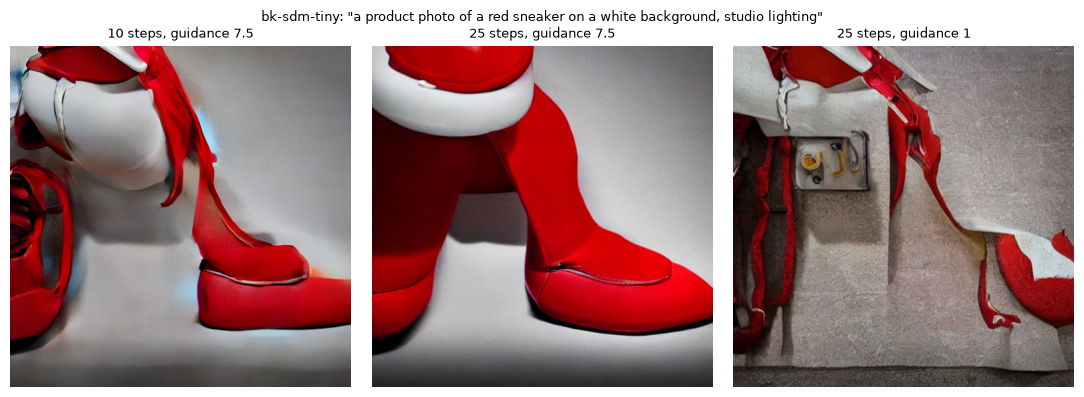

→ Guidance 1.0 skips the unconditional pass (diffusers only runs CFG when guidance_scale > 1): about half the U-Net calls, but images usually follow the prompt less closely.


In [32]:
free_gb = psutil.virtual_memory().available / 1e9
if DEVICE.type not in ("mps", "cuda"):
    print("⏭️ Skipped the text-to-image demo: it needs an Apple Silicon or CUDA GPU (a 512×512 image takes minutes on CPU). "
          "Run it on Google Colab with a GPU runtime.")
elif free_gb < T2I_MIN_FREE_GB:
    print(f"⏭️ Skipped the text-to-image demo: only {free_gb:.1f} GB of memory is free and the pipeline needs about {T2I_MIN_FREE_GB:.0f} GB of headroom. "
          "Close other applications (or lower T2I_MIN_FREE_GB at your own risk) and re-run this cell.")
else:
    import threading

    import tqdm
    from huggingface_hub import snapshot_download
    from huggingface_hub.utils import logging as hf_logging
    from diffusers import StableDiffusionPipeline

    hf_logging.set_verbosity_error()                # hide the Hub's rate-limit notice for anonymous downloads
    diffusers.utils.logging.disable_progress_bar()  # no "Loading pipeline components" progress bar in the saved output
    tqdm.tqdm.set_lock(threading.RLock())           # even disabled progress bars create a multiprocessing lock (which starts a helper process); a thread lock is enough
    start = time.perf_counter()
    local_dir = snapshot_download("nota-ai/bk-sdm-tiny", allow_patterns=[
        "model_index.json", "scheduler/*", "tokenizer/*", "feature_extractor/*",
        "text_encoder/config.json", "text_encoder/model.fp16.safetensors",
        "unet/config.json", "unet/diffusion_pytorch_model.fp16.safetensors",
        "vae/config.json", "vae/diffusion_pytorch_model.fp16.safetensors"])
    download_mb = sum(p.stat().st_size for p in Path(local_dir).rglob("*") if p.is_file()) / 1e6
    pipe = StableDiffusionPipeline.from_pretrained(local_dir, dtype=torch.float16, variant="fp16", use_safetensors=True,
                                                   safety_checker=None, requires_safety_checker=False).to(DEVICE)
    pipe.set_progress_bar_config(disable=True)
    pipe.enable_attention_slicing()                 # compute attention in chunks: lower peak memory for a small speed cost
    print(f"weights on disk: {download_mb:,.0f} MB | ready in {time.perf_counter() - start:.0f}s | scheduler: {type(pipe.scheduler).__name__}")
    print({name: f"{n_params(getattr(pipe, name)) / 1e6:.0f} M params" for name in ["unet", "vae", "text_encoder"]},
          f"| latent {pipe.unet.config.in_channels}×{pipe.unet.config.sample_size}×{pipe.unet.config.sample_size} | "
          f"cross-attention dim {pipe.unet.config.cross_attention_dim} | VAE scaling factor {pipe.vae.config.scaling_factor}")

    prompt = "a product photo of a red sneaker on a white background, studio lighting"
    pipe(prompt, num_inference_steps=2, guidance_scale=7.5, generator=torch.Generator("cpu").manual_seed(0))   # warm-up
    t2i_rows, t2i_images = [], []
    for steps, scale in [(10, 7.5), (25, 7.5), (25, 1.0)]:
        start = time.perf_counter()
        image = pipe(prompt, num_inference_steps=steps, guidance_scale=scale, generator=torch.Generator("cpu").manual_seed(0)).images[0]
        sync()
        pixels = np.asarray(image)
        t2i_rows.append({"steps": steps, "guidance scale": scale, "U-Net calls": steps * (2 if scale > 1 else 1),
                         "seconds": time.perf_counter() - start, "pixel std": pixels.std(), "finite image": bool(np.isfinite(pixels).all() and pixels.std() > 1)})
        t2i_images.append((image, f"{steps} steps, guidance {scale:g}"))
    PEAK["device_gb"] = max(PEAK["device_gb"], device_memory_gb())
    t2i_table = pd.DataFrame(t2i_rows)
    print(t2i_table.round(2).to_string(index=False))
    if t2i_table["seconds"].max() > 5 * t2i_table["seconds"].min():
        print("⚠️ One timed run was far slower than the others: the machine was probably swapping memory. Re-run this cell for clean timings.")
    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    for ax, (image, title) in zip(axes, t2i_images):
        ax.imshow(image)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    plt.suptitle(f'bk-sdm-tiny: "{prompt}"', fontsize=9)
    plt.tight_layout()
    plt.show()
    print("→ Guidance 1.0 skips the unconditional pass (diffusers only runs CFG when guidance_scale > 1): about half the U-Net calls, "
          "but images usually follow the prompt less closely.")
    del pipe, t2i_images
    free_memory()

> 💡 **Interview angle:** "Why is latent diffusion cheaper, and how does text get in?" — a pretrained autoencoder compresses images ~48× (f = 8, 4 channels), so the U-Net's convolutions and especially its attention run on 64×64 instead of 512×512. Text is encoded by CLIP/T5 into token embeddings that the U-Net reads through **cross-attention** (queries from image positions, keys and values from tokens), with CFG using the empty prompt as the unconditional branch.

## 12. Responsible Use: Licences, Deepfakes, Watermarks, Provenance 🟢

Image generators are dual-use: the model that makes a product photo can also make a fake photo of a real person.

| Topic | What to know | What engineers do |
|---|---|---|
| **Model licences** | Weights come with very different terms: OpenRAIL-M (open use plus behavioural restrictions), Apache-2.0 (e.g. FLUX.1 [schnell]), non-commercial licences (e.g. FLUX.1 [dev]), or revenue-capped community licences. LoRAs and fine-tunes inherit obligations. | Check the licence of every checkpoint, LoRA and dataset before shipping; keep a model bill of materials. |
| **Training data** | Web-scraped image–text sets contain copyrighted works and personal photos. LAION-5B was pulled in December 2023 after links to abusive material were found, and re-released as Re-LAION-5B in 2024. | Prefer licensed or consented data for commercial fine-tunes, honour opt-outs, filter data, document provenance. |
| **Deepfakes and NCII** | Realistic fakes enable fraud, harassment, election disinformation and non-consensual intimate imagery, which a growing number of laws criminalise (e.g. the US TAKE IT DOWN Act, 2025). | Block sexual or violent content involving real people and minors, filter both prompts and outputs, rate-limit, log, and provide abuse reporting. |
| **Watermarking** | Invisible signals in pixels or latents (e.g. Google DeepMind's SynthID, Meta's Stable Signature). They survive mild edits, but determined attacks can remove them, and detection needs the provider's key. | Watermark at generation time, but treat it as one signal, not proof. |
| **Content provenance** | **C2PA Content Credentials** attach a cryptographically signed manifest saying how an asset was created and edited. Metadata is easily stripped (screenshots, re-uploads), so *absence* of credentials proves nothing. | Sign outputs, preserve credentials through your pipeline, surface them in your UI. |
| **Regulation** | The EU AI Act's Article 50 requires providers of generative systems to mark synthetic images, audio, video and text in a machine-readable, detectable way, and deployers to disclose deepfakes. It applies from 2 August 2026. | Label AI-generated content, keep generation logs, follow platform disclosure rules. |

**Why naive watermarks are not enough.** A classic trick hides bits in each pixel's **least significant bit (LSB)**, changing brightness by at most 1 grey level (invisible). Let's hide a 64-bit signature in 64 of our generated images and apply everyday edits.

In [33]:
wm_images = ((ddpm1000_samples[:64, 0] + 1) * 127.5).round().to(torch.uint8)            # 64 generated images as 8-bit PNG-style pixels
signature = torch.randint(0, 2, (64,), generator=torch.Generator().manual_seed(7), dtype=torch.uint8)


def embed_lsb(images_u8, bits):
    marked = images_u8.clone()
    flat = marked.view(len(marked), -1)
    flat[:, :len(bits)] = (flat[:, :len(bits)] & 0xFE) | bits                          # overwrite the lowest bit of the first 64 pixels
    return marked


def read_lsb(images_u8, n_bits=64):
    return images_u8.view(len(images_u8), -1)[:, :n_bits] & 1


marked = embed_lsb(wm_images, signature)
noise_g = torch.Generator().manual_seed(8)
edits = {
    "no edit (lossless PNG)": marked,
    "re-quantise to 64 grey levels": (marked // 4) * 4,
    "resize 28→14→28 px": F.interpolate(F.interpolate(marked[:, None].float(), size=14, mode="bilinear", antialias=True), size=28, mode="bilinear")[:, 0].round().clamp(0, 255).to(torch.uint8),
    "add noise (σ = 2 grey levels)": (marked.float() + 2 * torch.randn(marked.shape, generator=noise_g)).round().clamp(0, 255).to(torch.uint8),
}
print(f"largest pixel change from embedding: {(marked.int() - wm_images.int()).abs().max().item()} grey level(s)")
for name, edited in edits.items():
    acc = (read_lsb(edited) == signature).float().mean().item()
    print(f"{name:32s} → signature bits recovered: {acc:.0%}" + ("" if acc > 0.9 else "  (≈ coin flipping: watermark destroyed)"))

largest pixel change from embedding: 1 grey level(s)
no edit (lossless PNG)           → signature bits recovered: 100%
re-quantise to 64 grey levels    → signature bits recovered: 53%  (≈ coin flipping: watermark destroyed)
resize 28→14→28 px               → signature bits recovered: 51%  (≈ coin flipping: watermark destroyed)
add noise (σ = 2 grey levels)    → signature bits recovered: 52%  (≈ coin flipping: watermark destroyed)


Everyday edits reduce the naive watermark to coin flips. Robust schemes spread the signal through the whole image or bake it into the generator's latents, and even those can be attacked. The practical answer is **defence in depth**: licences and usage policies, input and output safety filters, robust watermarks, signed C2PA credentials, logging, and human review for sensitive uses.

> 💡 **Interview angle:** "How would you make an image generator safer?" — policy (licences, acceptable use), prevention (prompt and output classifiers, blocking real-person likeness and minors, rate limits), attribution (robust watermarks plus C2PA provenance, knowing both can be stripped), monitoring (logs, abuse reports, red-teaming), and compliance (EU AI Act transparency marking).

## 🔧 Build It From Scratch

Three core pieces, each rebuilt without the library and **asserted** against a reference.

### 1) The DDPM forward process and noise schedules vs `diffusers.DDPMScheduler`

Our `alphas_cumprod` and `q_sample` must match diffusers' `alphas_cumprod` and `add_noise` for the same betas and the same noise. We test the linear schedule, the cosine schedule, and Stable Diffusion's "scaled linear" schedule passed in as `trained_betas`.

In [34]:
def make_alphas_cumprod(betas):
    return torch.cumprod(1.0 - betas, dim=0)


def q_sample(x0, t, noise, alphas_cumprod):
    """x_t = sqrt(ᾱ_t)·x0 + sqrt(1 − ᾱ_t)·ε, with ᾱ indexed per example."""
    abar = alphas_cumprod[t].view(-1, *([1] * (x0.ndim - 1)))
    return abar.sqrt() * x0 + (1 - abar).sqrt() * noise


scaled_linear = torch.linspace(0.00085 ** 0.5, 0.012 ** 0.5, T_STEPS, dtype=torch.float64) ** 2      # Stable Diffusion 1.x schedule
cases = [
    ("linear", linear_betas(), DDPMScheduler(num_train_timesteps=T_STEPS, beta_schedule="linear")),
    ("cosine (squaredcos_cap_v2)", cosine_betas(), DDPMScheduler(num_train_timesteps=T_STEPS, beta_schedule="squaredcos_cap_v2")),
    ("SD scaled-linear via trained_betas", scaled_linear, DDPMScheduler(num_train_timesteps=T_STEPS, trained_betas=scaled_linear.numpy())),
]
x0_check = to_sym(X_val_u8[:64])
noise_check = torch.randn(x0_check.shape, generator=torch.Generator().manual_seed(11))
t_check = torch.randint(0, T_STEPS, (64,), generator=torch.Generator().manual_seed(12))
for name, betas, library in cases:
    ours = make_alphas_cumprod(betas)
    assert torch.allclose(ours.float(), library.alphas_cumprod, atol=1e-6), name
    ours_noisy = q_sample(x0_check, t_check, noise_check, ours.float())
    lib_noisy = library.add_noise(x0_check, noise_check, t_check)
    assert torch.allclose(ours_noisy, lib_noisy, atol=1e-5), name
    print(f"✅ {name:36s} alphas_cumprod and q_sample match diffusers (max |Δ| {(ours_noisy - lib_noisy).abs().max():.1e}) | ᾱ_999 = {ours[-1]:.2e}")

✅ linear                               alphas_cumprod and q_sample match diffusers (max |Δ| 2.0e-06) | ᾱ_999 = 4.04e-05
✅ cosine (squaredcos_cap_v2)           alphas_cumprod and q_sample match diffusers (max |Δ| 1.6e-06) | ᾱ_999 = 2.43e-09
✅ SD scaled-linear via trained_betas   alphas_cumprod and q_sample match diffusers (max |Δ| 2.3e-06) | ᾱ_999 = 4.66e-03


### 2) The Fréchet distance between two Gaussians

$\operatorname{Tr}\big((\Sigma_1\Sigma_2)^{1/2}\big)$ needs a matrix square root. Without scipy: $\Sigma_1\Sigma_2$ has the same eigenvalues as the symmetric matrix $\Sigma_1^{1/2}\Sigma_2\Sigma_1^{1/2}$, so the trace is the sum of the square roots of those eigenvalues. We get $\Sigma_1^{1/2}$ from an eigendecomposition. Tests: identical Gaussians give 0; a **closed-form** case with diagonal covariances, $\lVert\mu_1-\mu_2\rVert^2 + \sum_j(\sigma_{1j}-\sigma_{2j})^2$; and the scipy reference on real judge features.

In [35]:
def sqrtm_psd(matrix):
    """Square root of a symmetric positive semi-definite matrix via eigendecomposition."""
    vals, vecs = np.linalg.eigh((matrix + matrix.T) / 2)
    return (vecs * np.sqrt(np.clip(vals, 0, None))) @ vecs.T


def frechet_distance_from_scratch(mu1, sigma1, mu2, sigma2):
    root1 = sqrtm_psd(sigma1)
    cross_eigs = np.linalg.eigvalsh(root1 @ sigma2 @ root1)                    # eigenvalues of Σ1½ Σ2 Σ1½ = eigenvalues of Σ1 Σ2
    trace_sqrt = np.sqrt(np.clip(cross_eigs, 0, None)).sum()
    return float(np.sum((mu1 - mu2) ** 2) + np.trace(sigma1) + np.trace(sigma2) - 2 * trace_sqrt)


rng_fd = np.random.default_rng(0)
A = rng_fd.normal(size=(8, 8))
spd = A @ A.T + 0.1 * np.eye(8)
mu_a = rng_fd.normal(size=8)
assert abs(frechet_distance_from_scratch(mu_a, spd, mu_a, spd)) < 1e-8
print("✅ identical Gaussians → distance 0")

sd1, sd2 = rng_fd.uniform(0.5, 2.0, 8), rng_fd.uniform(0.5, 2.0, 8)
mu_b = mu_a + rng_fd.normal(size=8)
closed_form = np.sum((mu_a - mu_b) ** 2) + np.sum((sd1 - sd2) ** 2)
ours_diag = frechet_distance_from_scratch(mu_a, np.diag(sd1 ** 2), mu_b, np.diag(sd2 ** 2))
assert np.isclose(ours_diag, closed_form, rtol=1e-10)
print(f"✅ diagonal covariances: from scratch {ours_diag:.6f} == closed form {closed_form:.6f}")

gen_feats, _ = judge_features(ddpm1000_samples)
gen_stats = gaussian_stats(gen_feats)
ours_real = frechet_distance_from_scratch(*gen_stats, *VAL_STATS)
reference_real = frechet_distance_scipy(*gen_stats, *VAL_STATS, eps=0.0)
assert np.isclose(ours_real, reference_real, rtol=1e-6, atol=1e-6)
print(f"✅ real 64-d judge features (DDPM samples vs validation): from scratch {ours_real:.6f} == scipy.linalg.sqrtm reference {reference_real:.6f}")

✅ identical Gaussians → distance 0
✅ diagonal covariances: from scratch 10.593470 == closed form 10.593470
✅ real 64-d judge features (DDPM samples vs validation): from scratch 68.944030 == scipy.linalg.sqrtm reference 68.944030


### 3) The VAE's Gaussian KL: closed form vs Monte Carlo

$\mathrm{KL}(q\,\|\,p) = \mathbb{E}_{z\sim q}[\log q(z) - \log p(z)]$. Averaging that over many samples must agree with $-\frac12\sum(1 + \log\sigma^2 - \mu^2 - \sigma^2)$ within Monte Carlo error.

In [36]:
torch.manual_seed(0)
n_mc = 400_000
for trial in range(4):
    mu_q = torch.randn(6, dtype=torch.float64) * (trial + 0.5)
    logvar_q = torch.randn(6, dtype=torch.float64)
    closed = gaussian_kl(mu_q, logvar_q).sum().item()
    q_dist = torch.distributions.Normal(mu_q, torch.exp(0.5 * logvar_q))
    z_mc = q_dist.sample((n_mc,))
    log_ratio = q_dist.log_prob(z_mc).sum(-1) - torch.distributions.Normal(0.0, 1.0).log_prob(z_mc).sum(-1)
    mc, stderr = log_ratio.mean().item(), log_ratio.std().item() / math.sqrt(n_mc)
    assert abs(mc - closed) < 4 * stderr + 1e-3, (closed, mc, stderr)
    print(f"✅ trial {trial}: closed form {closed:8.4f} | Monte Carlo {mc:8.4f} ± {stderr:.4f} (standard error)")

✅ trial 0: closed form   1.8379 | Monte Carlo   1.8399 ± 0.0030 (standard error)
✅ trial 1: closed form   6.0567 | Monte Carlo   6.0619 ± 0.0056 (standard error)
✅ trial 2: closed form  19.8410 | Monte Carlo  19.8425 ± 0.0104 (standard error)
✅ trial 3: closed form  37.1906 | Monte Carlo  37.2309 ± 0.0219 (standard error)


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Sampling with a different noise schedule than the model was trained with

The network learned what "noise level t" means under *our* linear betas. A scheduler created with library defaults or copied from another model (here a cosine schedule) feeds it noise levels that don't match the timestep numbers it receives, and nothing raises an error.

In [37]:
wrong_schedule = DDIMScheduler(num_train_timesteps=T_STEPS, beta_schedule="squaredcos_cap_v2", clip_sample=False)   # ❌ not the training schedule
right_schedule = DDIMScheduler.from_config(ddpm_scheduler.config)                                                  # ✅ the training config
for label, sched in [("❌ cosine schedule at sampling time ", wrong_schedule), ("✅ training (linear) schedule        ", right_schedule)]:
    row = eval_row(sample_with_scheduler(denoiser, sched, EVAL_LABELS, 25), EVAL_LABELS)
    print(f"{label}: feature-FID {row['feature-FID']:7.1f} | class accuracy {row['class accuracy']:.3f}")
print("→ Save the scheduler config with the weights (diffusers pipelines keep scheduler/scheduler_config.json) and rebuild samplers with from_config.")

❌ cosine schedule at sampling time : feature-FID  1876.1 | class accuracy 0.130


✅ training (linear) schedule        : feature-FID   122.2 | class accuracy 0.806
→ Save the scheduler config with the weights (diffusers pipelines keep scheduler/scheduler_config.json) and rebuild samplers with from_config.


### ❌ Pitfall 2 — Using $\alpha_t$ instead of $\bar\alpha_t$ in the forward process

One missing `cumprod` and "t = 999" is almost a clean image. The model then never learns to denoise real noise, and sampling from pure noise fails.

❌ α_t  : correlation of x_999 with the clean image = 0.981
✅ ᾱ_t  : correlation of x_999 with the clean image = 0.006


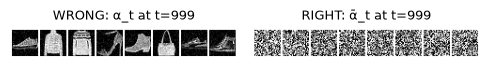

In [38]:
x0_p2 = to_sym(X_val_u8[:500])
noise_p2 = torch.randn(x0_p2.shape, generator=torch.Generator().manual_seed(0))
t_last = torch.full((500,), 999)
wrong = q_sample(x0_p2, t_last, noise_p2, ddpm_scheduler.alphas)              # ❌ per-step α_t
right = q_sample(x0_p2, t_last, noise_p2, ddpm_scheduler.alphas_cumprod)      # ✅ cumulative ᾱ_t
for label, noisy in [("❌ α_t  ", wrong), ("✅ ᾱ_t  ", right)]:
    corr = np.corrcoef(noisy.flatten(), x0_p2.flatten())[0, 1]
    print(f"{label}: correlation of x_999 with the clean image = {corr:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(5, 2))
show_grid(wrong[:8], nrow=8, title="WRONG: α_t at t=999", ax=axes[0])
show_grid(right[:8], nrow=8, title="RIGHT: ᾱ_t at t=999", ax=axes[1])
plt.tight_layout()
plt.show()

### ❌ Pitfall 3 — Leaving diffusers' default `clip_sample=True` on while using strong guidance

`DDIMScheduler()` defaults to clipping its $\hat x_0$ estimate to [−1, 1], but keeps using the *unclipped* noise prediction for the direction term. With guidance the two disagree, and samples fall apart. (Our `ddpm_scheduler` was created with `clip_sample=False`, and the DDIM scheduler inherited it.)

In [39]:
ddim_default = DDIMScheduler(num_train_timesteps=T_STEPS)                        # ❌ library default: clip_sample=True
ddim_noclip = DDIMScheduler(num_train_timesteps=T_STEPS, clip_sample=False)      # ✅
for label, sched in [("❌ clip_sample=True ", ddim_default), ("✅ clip_sample=False", ddim_noclip)]:
    imgs = sample_with_scheduler(denoiser, sched, EVAL_LABELS, 25, guidance_scale=3.0)
    row = eval_row(imgs, EVAL_LABELS)
    print(f"{label} (guidance 3): feature-FID {row['feature-FID']:7.1f} | class accuracy {row['class accuracy']:.3f}")

❌ clip_sample=True  (guidance 3): feature-FID   966.3 | class accuracy 0.564


✅ clip_sample=False (guidance 3): feature-FID    72.1 | class accuracy 0.984


### ❌ Pitfall 4 — Mismatched loss reductions in a VAE (mean over pixels + sum over latents)

`F.binary_cross_entropy(..., reduction="mean")` averages over 784 pixels, while the KL is summed over the latent dimensions. That is secretly β = 784 (your Section 3 exercise), and the posterior collapses.

In [40]:
def train_vae_variant(mean_reconstruction, epochs=2):
    seed_everything(SEED)
    model = MLPAutoencoder(latent_dim=16).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        model.train()
        for idx in epoch_batches(len(X_train_dev), 128, torch.Generator().manual_seed(SEED + epoch)):
            x = to_unit(X_train_dev[idx])
            logits, mu, logvar = model(x)
            reduction = "mean" if mean_reconstruction else "sum"
            recon = F.binary_cross_entropy_with_logits(logits, x, reduction=reduction) / (1 if mean_reconstruction else len(x))
            loss = recon + gaussian_kl(mu, logvar).sum(dim=1).mean()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
    return evaluate_vae(model, X_val_u8)


bad, good = train_vae_variant(mean_reconstruction=True), train_vae_variant(mean_reconstruction=False)
print(f"❌ mean over pixels + summed KL: active units {bad['active units']}/16 | KL {bad['KL (nats)']:.2f} nats | recon {bad['recon (nats)']:.0f} nats")
print(f"✅ sum over pixels  + summed KL: active units {good['active units']}/16 | KL {good['KL (nats)']:.2f} nats | recon {good['recon (nats)']:.0f} nats")
free_memory()

❌ mean over pixels + summed KL: active units 0/16 | KL 0.00 nats | recon 387 nats
✅ sum over pixels  + summed KL: active units 10/16 | KL 11.00 nats | recon 240 nats


### ❌ Pitfall 5 — Feeding generated images to the feature network with the wrong preprocessing

The judge was trained on images in [−1, 1]. Rescaling generated images to [0, 1] (as you would for display) before extracting features silently wrecks every metric. This is the same class of bug as real-world FID resizing and JPEG differences.

In [41]:
fid_right = eval_row(ddpm1000_samples)["feature-FID"]
fid_wrong = eval_row((ddpm1000_samples + 1) / 2)["feature-FID"]                  # ❌ [0, 1] images into a [−1, 1] network
print(f"❌ generated images in [0, 1]: feature-FID {fid_wrong:.1f}")
print(f"✅ generated images in [−1, 1]: feature-FID {fid_right:.1f}  (same images, {fid_wrong / fid_right:.0f}× 'worse' only because of preprocessing)")

❌ generated images in [0, 1]: feature-FID 3159.3
✅ generated images in [−1, 1]: feature-FID 68.9  (same images, 46× 'worse' only because of preprocessing)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Noise-schedule arithmetic
For the linear schedule $\beta_t$ = `np.linspace(1e-4, 0.02, 1000)`, compute $\bar\alpha_{499} = \prod_{s=0}^{499}(1 - \beta_s)$ with NumPy and store it in `abar_499`. Roughly what fraction of the signal's *standard deviation* is left at that step?

In [42]:
abar_499 = None  # TODO
check("abar_499", abar_499, DDPMScheduler(num_train_timesteps=1000).alphas_cumprod[499].item(), atol=1e-6,
      hint="betas = np.linspace(1e-4, 0.02, 1000); np.prod(1 - betas[:500])  (indices 0..499 are the first 500 steps)")

⏳ abar_499: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
betas = np.linspace(1e-4, 0.02, 1000)
abar_499 = float(np.prod(1 - betas[:500]))
check("abar_499", abar_499, DDPMScheduler(num_train_timesteps=1000).alphas_cumprod[499].item(), atol=1e-6)
print(f"ᾱ_499 = {abar_499:.4f} → signal std factor √ᾱ = {abar_499 ** 0.5:.3f}, noise std factor √(1−ᾱ) = {(1 - abar_499) ** 0.5:.3f}")
```

Halfway through the linear schedule only about 28% of the signal's standard deviation remains, which is why the cosine schedule was introduced.
</details>

### 🟢 Exercise 2 — The Gaussian KL term
Implement `kl_standard_normal(mu, logvar)` returning $\mathrm{KL}(\mathcal{N}(\mu, e^{\log\sigma^2})\,\|\,\mathcal{N}(0, I))$ **summed over the last dimension** (one value per example).

In [43]:
def kl_standard_normal(mu, logvar):
    return None  # TODO


_mu = torch.tensor([[1.0, 0.0], [0.3, -2.0]])
_logvar = torch.tensor([[0.0, math.log(0.25)], [1.0, -1.0]])
_ref = torch.distributions.kl_divergence(torch.distributions.Normal(_mu, torch.exp(0.5 * _logvar)), torch.distributions.Normal(0.0, 1.0)).sum(-1)
check("kl_standard_normal", kl_standard_normal(_mu, _logvar), _ref, atol=1e-5, hint="-0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(-1)")

⏳ kl_standard_normal: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def kl_standard_normal(mu, logvar):
    return -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=-1)


_mu = torch.tensor([[1.0, 0.0], [0.3, -2.0]])
_logvar = torch.tensor([[0.0, math.log(0.25)], [1.0, -1.0]])
_ref = torch.distributions.kl_divergence(torch.distributions.Normal(_mu, torch.exp(0.5 * _logvar)), torch.distributions.Normal(0.0, 1.0)).sum(-1)
check("kl_standard_normal", kl_standard_normal(_mu, _logvar), _ref, atol=1e-5)
```

First row by hand: dimension 1 gives ½(1 + 1 − 1 − 0) = 0.5; dimension 2 (σ = 0.5) gives ½(0.25 − 1 − ln 0.25) ≈ 0.318; total ≈ 0.818 nats.
</details>

### 🟢 Exercise 3 — The classifier-free guidance mix
Implement `cfg_mix(eps_uncond, eps_cond, scale)`. The checker tests scale 0 (must return the unconditional prediction), scale 1 (conditional) and scale 4.

In [44]:
def cfg_mix(eps_uncond, eps_cond, scale):
    return None  # TODO


_eu, _ec = torch.tensor([0.2, -0.1, 0.5]), torch.tensor([0.4, 0.1, 0.3])
_got = cfg_mix(_eu, _ec, 0.0)
check("cfg_mix", None if _got is None else (cfg_mix(_eu, _ec, 0.0), cfg_mix(_eu, _ec, 1.0), cfg_mix(_eu, _ec, 4.0)),
      (_eu, _ec, torch.tensor([1.0, 0.7, -0.3])), atol=1e-6, hint="eps_uncond + scale * (eps_cond - eps_uncond)")

⏳ cfg_mix: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def cfg_mix(eps_uncond, eps_cond, scale):
    return eps_uncond + scale * (eps_cond - eps_uncond)


_eu, _ec = torch.tensor([0.2, -0.1, 0.5]), torch.tensor([0.4, 0.1, 0.3])
check("cfg_mix", (cfg_mix(_eu, _ec, 0.0), cfg_mix(_eu, _ec, 1.0), cfg_mix(_eu, _ec, 4.0)), (_eu, _ec, torch.tensor([1.0, 0.7, -0.3])), atol=1e-6)
```

At scale 4 the first entry is 0.2 + 4·(0.4 − 0.2) = 1.0: guidance *extrapolates* past the conditional prediction, which is why large scales over-saturate.
</details>

### 🟡 Exercise 4 — Fréchet distance for full covariances
Implement `frechet_distance(mu1, sigma1, mu2, sigma2)` for NumPy arrays (you may use `scipy.linalg.sqrtm`; take `.real` of its result). The checker uses a diagonal closed-form case and real feature statistics from this notebook.

In [45]:
def frechet_distance(mu1, sigma1, mu2, sigma2):
    return None  # TODO


_d1, _d2 = np.array([1.0, 4.0, 9.0]), np.array([4.0, 4.0, 1.0])
_m1, _m2 = np.zeros(3), np.array([1.0, 0.0, -1.0])
_expected_diag = 2.0 + (1 - 2) ** 2 + (2 - 2) ** 2 + (3 - 1) ** 2
_fd_got = frechet_distance(_m1, np.diag(_d1), _m2, np.diag(_d2))
check("frechet_distance", None if _fd_got is None else (_fd_got, frechet_distance(*gen_stats, *VAL_STATS)),
      (_expected_diag, frechet_distance_scipy(*gen_stats, *VAL_STATS, eps=0.0)), atol=1e-4, rtol=1e-4,
      hint="np.sum((mu1-mu2)**2) + np.trace(sigma1 + sigma2 - 2 * scipy.linalg.sqrtm(sigma1 @ sigma2).real)")

⏳ frechet_distance: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def frechet_distance(mu1, sigma1, mu2, sigma2):
    root1 = scipy.linalg.sqrtm(sigma1).real
    cross = scipy.linalg.sqrtm(root1 @ sigma2 @ root1).real       # symmetric and PSD → a stable square root
    return float(np.sum((mu1 - mu2) ** 2) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(cross))


_d1, _d2 = np.array([1.0, 4.0, 9.0]), np.array([4.0, 4.0, 1.0])
_m1, _m2 = np.zeros(3), np.array([1.0, 0.0, -1.0])
_expected_diag = 2.0 + (1 - 2) ** 2 + (2 - 2) ** 2 + (3 - 1) ** 2
_fd_got = frechet_distance(_m1, np.diag(_d1), _m2, np.diag(_d2))
check("frechet_distance", (_fd_got, frechet_distance(*gen_stats, *VAL_STATS)),
      (_expected_diag, frechet_distance_scipy(*gen_stats, *VAL_STATS, eps=0.0)), atol=1e-4, rtol=1e-4)
```

`sqrtm(sigma1 @ sigma2)` also works, but that product isn't symmetric, so scipy can return tiny imaginary parts and warnings; real FID code adds a small `eps · I` when the covariance is singular.
</details>

### 🟡 Exercise 5 — One deterministic DDIM step
Implement `ddim_step(x_t, eps, abar_t, abar_prev)` for η = 0: estimate $\hat x_0$, then return $\sqrt{\bar\alpha_{\text{prev}}}\,\hat x_0 + \sqrt{1-\bar\alpha_{\text{prev}}}\,\hat\varepsilon$. The checker compares with `DDIMScheduler.step` (no clipping).

In [46]:
def ddim_step(x_t, eps, abar_t, abar_prev):
    return None  # TODO


_ddim = DDIMScheduler(num_train_timesteps=1000, clip_sample=False)
_ddim.set_timesteps(50)
_t = int(_ddim.timesteps[10])
_prev = _t - 1000 // 50
_x = torch.randn(4, 1, 8, 8, generator=torch.Generator().manual_seed(0))
_eps = torch.randn(4, 1, 8, 8, generator=torch.Generator().manual_seed(1))
check("ddim_step", ddim_step(_x, _eps, _ddim.alphas_cumprod[_t], _ddim.alphas_cumprod[_prev]), _ddim.step(_eps, _t, _x).prev_sample,
      atol=1e-5, hint="x0_hat = (x_t - (1 - abar_t).sqrt() * eps) / abar_t.sqrt()")

⏳ ddim_step: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def ddim_step(x_t, eps, abar_t, abar_prev):
    x0_hat = (x_t - (1 - abar_t).sqrt() * eps) / abar_t.sqrt()
    return abar_prev.sqrt() * x0_hat + (1 - abar_prev).sqrt() * eps


_ddim = DDIMScheduler(num_train_timesteps=1000, clip_sample=False)
_ddim.set_timesteps(50)
_t = int(_ddim.timesteps[10])
_prev = _t - 1000 // 50
_x = torch.randn(4, 1, 8, 8, generator=torch.Generator().manual_seed(0))
_eps = torch.randn(4, 1, 8, 8, generator=torch.Generator().manual_seed(1))
check("ddim_step", ddim_step(_x, _eps, _ddim.alphas_cumprod[_t], _ddim.alphas_cumprod[_prev]), _ddim.step(_eps, _t, _x).prev_sample, atol=1e-5)
```

The step "re-noises" the clean estimate to the earlier noise level using the *same* predicted noise, so no randomness is added.
</details>

### 🔴 Exercise 6 — The DDPM reverse step (interview classic)
Implement one ancestral step `ddpm_reverse_step(x_t, eps, t, betas, alphas_cumprod, z)`: the posterior mean $\frac{1}{\sqrt{\alpha_t}}\big(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\hat\varepsilon\big)$ plus $\sigma_t z$ with $\sigma_t^2 = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$ (no noise when $t = 0$). The checker compares with `DDPMScheduler.step` using the same random noise.

In [47]:
def ddpm_reverse_step(x_t, eps, t, betas, alphas_cumprod, z):
    return None  # TODO


_ddpm = DDPMScheduler(num_train_timesteps=1000, clip_sample=False)
_ddpm.set_timesteps(1000)
_x = torch.randn(4, 1, 8, 8, generator=torch.Generator().manual_seed(2))
_eps = torch.randn(4, 1, 8, 8, generator=torch.Generator().manual_seed(3))
_z = torch.randn(_x.shape, generator=torch.Generator().manual_seed(5))     # the noise diffusers draws with this generator
_results = [ddpm_reverse_step(_x, _eps, t, _ddpm.betas, _ddpm.alphas_cumprod, _z) for t in (500, 0)]
_expected = [_ddpm.step(_eps, t, _x, generator=torch.Generator().manual_seed(5)).prev_sample for t in (500, 0)]
check("ddpm_reverse_step", None if _results[0] is None else tuple(_results), tuple(_expected), atol=1e-4,
      hint="mean = (x_t - betas[t] / (1 - abar[t]).sqrt() * eps) / (1 - betas[t]).sqrt(); add var.sqrt() * z only if t > 0")

⏳ ddpm_reverse_step: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def ddpm_reverse_step(x_t, eps, t, betas, alphas_cumprod, z):
    beta_t, abar_t = betas[t], alphas_cumprod[t]
    mean = (x_t - beta_t / (1 - abar_t).sqrt() * eps) / (1 - beta_t).sqrt()
    if t == 0:
        return mean
    variance = (1 - alphas_cumprod[t - 1]) / (1 - abar_t) * beta_t     # β̃_t, the "fixed_small" posterior variance
    return mean + variance.sqrt() * z


_ddpm = DDPMScheduler(num_train_timesteps=1000, clip_sample=False)
_ddpm.set_timesteps(1000)
_x = torch.randn(4, 1, 8, 8, generator=torch.Generator().manual_seed(2))
_eps = torch.randn(4, 1, 8, 8, generator=torch.Generator().manual_seed(3))
_z = torch.randn(_x.shape, generator=torch.Generator().manual_seed(5))
_results = [ddpm_reverse_step(_x, _eps, t, _ddpm.betas, _ddpm.alphas_cumprod, _z) for t in (500, 0)]
_expected = [_ddpm.step(_eps, t, _x, generator=torch.Generator().manual_seed(5)).prev_sample for t in (500, 0)]
check("ddpm_reverse_step", tuple(_results), tuple(_expected), atol=1e-4)
```

Follow-ups interviewers ask: why $\tilde\beta_t$ vs $\beta_t$ (the lower and upper bounds on the reverse variance; Improved DDPM *learns* an interpolation between them), and why the last step adds no noise (you want the mean image, not a noisy one).
</details>

## 🚀 Mini Project: Generate Fashion-MNIST on a Laptop Budget

**Goal:** you have a laptop and a small, fixed training budget per model. Which family gives the best **class-conditional** Fashion-MNIST generator: a **conditional VAE**, a **conditional DCGAN**, or a small **conditional DDPM** sampled with DDIM and classifier-free guidance?

**Protocol (fixed before looking at any result):**
- **Same budget:** each model gets `BUDGET_STEPS` = 3,000 optimizer steps with batches of 128, i.e. the same 384,000 training images (~7 epochs of the 55,000-image training split), on the same device. We budget steps rather than seconds so the comparison is reproducible on a shared, busy laptop. A diffusion step costs more compute than a VAE step, so the table also reports training seconds. (The diffusion model is the one trained in §7 under exactly this budget. Its guidance scale was chosen in §10 on **validation** statistics.)
- **Same evaluation:** 1,000 samples per model (100 per class) from fixed seeds, scored against the **test set** (10,000 images, used here for the first and only time) with the judge trained in §1:
  feature-FID (⚠️ Fashion-MNIST judge features, not comparable to published FIDs), class-conditional accuracy, within-class diversity relative to real test images, precision/recall, sampling time for 1,000 images, and parameter count.

**Decision rule (stated up front):**
1. **Gates:** class accuracy ≥ 0.80 (it makes what you ask for) and within-class diversity ≥ 0.70 (it isn't collapsing).
2. Among models that pass, pick the **lowest feature-FID**.
3. If another passing model is within **10%** of that FID, prefer the one with the **faster sampling**.
4. If no model passes both gates, recommend the lowest FID and flag it as not production-ready.

### Step 1 — Test-set references for the judge

In [48]:
project_start = time.perf_counter()
PROJECT_LABELS = torch.arange(10).repeat_interleave(100)
test_feats, test_probs = judge_features(to_sym(X_test_u8))
TEST_STATS = gaussian_stats(test_feats)
TEST_CLASS_FEATS = {c: test_feats[(y_test == c).numpy()][:100] for c in range(10)}
TEST_PR_FEATS = test_feats[torch.randperm(len(test_feats), generator=torch.Generator().manual_seed(SEED))[:1000].numpy()]
print(f"judge accuracy on the test set: {(test_probs.argmax(1) == y_test).float().mean():.3f} (the judge itself is imperfect: keep that in mind for 'class accuracy')")


def project_metrics(images_sym, labels):
    feats, probs = judge_features(images_sym)
    precision, recall = precision_recall(TEST_PR_FEATS, feats)
    return {"feature-FID (test)": frechet_distance_scipy(*gaussian_stats(feats), *TEST_STATS),
            "class accuracy": (probs.argmax(1) == labels).float().mean().item(),
            "within-class diversity": within_class_diversity(feats, labels, TEST_CLASS_FEATS),
            "precision": precision, "recall": recall}

judge accuracy on the test set: 0.907 (the judge itself is imperfect: keep that in mind for 'class accuracy')


### Step 2 — Conditional VAE (3,000 steps)

The one-hot label is concatenated to the encoder input and to the latent code, so the decoder learns $p(x \mid z, y)$.

In [49]:
seed_everything(SEED)
cvae = MLPAutoencoder(latent_dim=16, variational=True, n_labels=10).to(DEVICE)
cvae_opt = torch.optim.AdamW(cvae.parameters(), lr=1e-3)
g_cvae = torch.Generator().manual_seed(SEED)
start = time.perf_counter()
for _ in range(BUDGET_STEPS):
    idx = torch.randint(0, len(X_train_dev), (128,), generator=g_cvae).to(DEVICE)
    recon, kl = vae_terms(cvae, to_unit(X_train_dev[idx]), F.one_hot(y_train_dev[idx], 10).float())
    loss = (recon + kl.sum(dim=1)).mean()
    cvae_opt.zero_grad(set_to_none=True)
    loss.backward()
    cvae_opt.step()
sync()                                                  # wait for queued GPU work before reading the clock
cvae_steps, cvae_seconds = BUDGET_STEPS, time.perf_counter() - start
cvae_val = evaluate_vae(cvae, X_val_u8, y_val)
print(f"CVAE: {n_params(cvae):,} params | {cvae_steps:,} steps in {cvae_seconds:.0f}s | validation recon {cvae_val['recon (nats)']:.1f} nats, "
      f"KL {cvae_val['KL (nats)']:.1f} nats, active units {cvae_val['active units']}/16")


@torch.inference_mode()
def sample_cvae(labels, seed=0):
    cvae.eval()
    z = torch.randn(len(labels), 16, generator=torch.Generator().manual_seed(seed)).to(DEVICE)
    return (torch.sigmoid(cvae.decode(z, F.one_hot(labels, 10).float().to(DEVICE))) * 2 - 1).cpu()

CVAE: 1,087,280 params | 3,000 steps in 5s | validation recon 230.5 nats, KL 9.7 nats, active units 6/16


### Step 3 — Conditional DCGAN (3,000 steps)

In [50]:
seed_everything(SEED)
cgan_gen, cgan_disc = DCGenerator(n_classes=10).to(DEVICE), DCDiscriminator(n_classes=10).to(DEVICE)
opt_cg = torch.optim.Adam(cgan_gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_cd = torch.optim.Adam(cgan_disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
g_cgan = torch.Generator().manual_seed(SEED)
start = time.perf_counter()
for _ in range(BUDGET_STEPS):
    idx = torch.randint(0, len(X_train_dev), (128,), generator=g_cgan).to(DEVICE)
    d_loss, g_loss = gan_step(cgan_gen, cgan_disc, opt_cg, opt_cd, to_sym(X_train_dev[idx]), y_train_dev[idx])
sync()
cgan_steps, cgan_seconds = BUDGET_STEPS, time.perf_counter() - start
print(f"conditional DCGAN: G {n_params(cgan_gen):,} + D {n_params(cgan_disc):,} params | {cgan_steps:,} steps in {cgan_seconds:.0f}s | "
      f"last losses D {d_loss.item():.3f}, G {g_loss.item():.3f}")


@torch.inference_mode()
def sample_cgan(labels, seed=0):
    cgan_gen.eval()
    z = torch.randn(len(labels), cgan_gen.z_dim, generator=torch.Generator().manual_seed(seed)).to(DEVICE)
    return cgan_gen(z, labels.to(DEVICE)).cpu()

conditional DCGAN: G 634,401 + D 148,929 params | 3,000 steps in 54s | last losses D 1.394, G 0.488


### Step 4 — Generate 1,000 images per model and time the samplers

In [51]:
samplers = {
    "conditional VAE": (lambda: sample_cvae(PROJECT_LABELS), n_params(cvae), n_params(cvae.decoder), cvae_steps, cvae_seconds),
    "conditional DCGAN": (lambda: sample_cgan(PROJECT_LABELS), n_params(cgan_gen) + n_params(cgan_disc), n_params(cgan_gen), cgan_steps, cgan_seconds),
    f"conditional DDPM (DDIM 25, CFG {CFG_SCALE:g})": (lambda: sample_with_scheduler(denoiser, ddim, PROJECT_LABELS, 25, guidance_scale=CFG_SCALE),
                                                     n_params(denoiser), n_params(denoiser), diff_steps, diffusion_train_seconds),
}
sample_cvae(PROJECT_LABELS[:10]), sample_cgan(PROJECT_LABELS[:10])                 # warm-ups
sample_with_scheduler(denoiser, ddim, PROJECT_LABELS[:10], 2, guidance_scale=CFG_SCALE)
project_rows, project_images = [], {}
for name, (sample_fn, total_params, sampling_params, train_steps, train_seconds) in samplers.items():
    start = time.perf_counter()
    images = sample_fn()
    sync()
    sampling_seconds = time.perf_counter() - start
    project_images[name] = images
    project_rows.append({"model": name, "params (total)": total_params, "params used to sample": sampling_params,
                         "train steps": train_steps, "train s": train_seconds, "sampling s / 1,000 images": sampling_seconds,
                         **project_metrics(images, PROJECT_LABELS)})
reference = {"model": "real training images (reference only)", **project_metrics(to_sym(X_train_u8[:1000]), y_train[:1000])}
project_table = pd.DataFrame(project_rows + [reference]).set_index("model")
print(project_table.to_string(float_format=lambda v: f"{v:,.3f}" if abs(v) < 100 else f"{v:,.0f}"))

                                       params (total)  params used to sample  train steps  train s  sampling s / 1,000 images  feature-FID (test)  class accuracy  within-class diversity  precision  recall
model                                                                                                                                                                                                       
conditional VAE                             1,087,280                540,688        3,000    5.089                      0.026               1,359           0.507                   0.821      0.483   0.142
conditional DCGAN                             783,330                634,401        3,000   54.067                      0.031              51.188           0.918                   0.896      0.816   0.678
conditional DDPM (DDIM 25, CFG 2)             633,121                633,121        3,000      132                      3.804              43.841           0.940                   

### Step 5 — Look at the samples

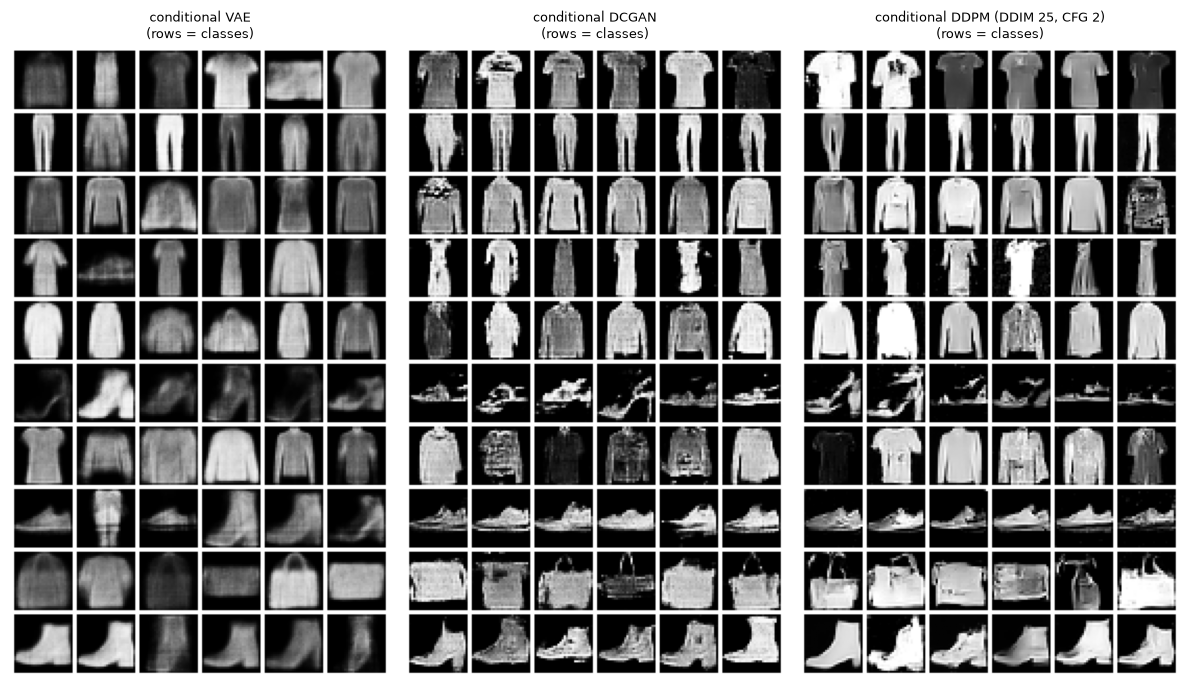

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(12, 7))
for ax, (name, images) in zip(axes, project_images.items()):
    show_grid(images.view(10, 100, 1, 28, 28)[:, :6].reshape(60, 1, 28, 28), nrow=6, title=f"{name}\n(rows = classes)", ax=ax)
plt.tight_layout()
plt.show()

### Step 6 — Apply the decision rule

In [53]:
models = project_table.drop(index="real training images (reference only)")
gates = (models["class accuracy"] >= 0.80) & (models["within-class diversity"] >= 0.70)
for name, row in models.iterrows():
    status = "passes" if gates[name] else "fails"
    print(f"• {name}: {status} the gates (accuracy {row['class accuracy']:.2f}, diversity {row['within-class diversity']:.2f}), "
          f"FID {row['feature-FID (test)']:.1f}, {row['sampling s / 1,000 images']:.2f}s per 1,000 images")
passing = models[gates]
if len(passing):
    best_fid_name = passing["feature-FID (test)"].idxmin()
    near = passing[passing["feature-FID (test)"] <= 1.10 * passing.loc[best_fid_name, "feature-FID (test)"]]
    recommendation = near["sampling s / 1,000 images"].idxmin()
    reason = ("lowest FID among models passing both gates" if recommendation == best_fid_name
              else f"within 10% of the best FID ({best_fid_name}) and faster to sample")
    print(f"\n🏆 Recommendation: {recommendation} — {reason}.")
else:
    recommendation = models["feature-FID (test)"].idxmin()
    print(f"\n⚠️ No model passed both gates. Lowest FID: {recommendation}, which is not production-ready under this budget.")
rec = models.loc[recommendation]
print(f"   It reaches FID {rec['feature-FID (test)']:.1f} (real-data floor at N=1,000: {reference['feature-FID (test)']:.1f}), "
      f"class accuracy {rec['class accuracy']:.2f}, recall {rec['recall']:.2f}, {rec['sampling s / 1,000 images']:.2f}s per 1,000 images.")
for name, row in models.drop(index=recommendation).iterrows():
    speed_ratio = row["sampling s / 1,000 images"] / rec["sampling s / 1,000 images"]
    if row["feature-FID (test)"] < rec["feature-FID (test)"]:
        print(f"   Trade-off: {name} has a lower FID ({row['feature-FID (test)']:.1f}) but samples {speed_ratio:.0f}× slower.")
    elif speed_ratio < 0.5:
        print(f"   Trade-off: {name} samples {1 / speed_ratio:.0f}× faster but scores FID {row['feature-FID (test)']:.1f}.")
free_memory()
rss_peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / (1e9 if sys.platform == "darwin" else 1e6)
print(f"\nproject time {time.perf_counter() - project_start:.0f}s | whole notebook so far {(time.perf_counter() - NOTEBOOK_START) / 60:.1f} min | "
      f"peak GPU driver memory {PEAK['device_gb']:.2f} GB | peak process RSS {rss_peak:.2f} GB")

• conditional VAE: fails the gates (accuracy 0.51, diversity 0.82), FID 1359.4, 0.03s per 1,000 images
• conditional DCGAN: passes the gates (accuracy 0.92, diversity 0.90), FID 51.2, 0.03s per 1,000 images
• conditional DDPM (DDIM 25, CFG 2): passes the gates (accuracy 0.94, diversity 0.78), FID 43.8, 3.80s per 1,000 images

🏆 Recommendation: conditional DDPM (DDIM 25, CFG 2) — lowest FID among models passing both gates.
   It reaches FID 43.8 (real-data floor at N=1,000: 8.1), class accuracy 0.94, recall 0.64, 3.80s per 1,000 images.
   Trade-off: conditional VAE samples 145× faster but scores FID 1359.4.
   Trade-off: conditional DCGAN samples 122× faster but scores FID 51.2.



project time 63s | whole notebook so far 7.3 min | peak GPU driver memory 3.68 GB | peak process RSS 0.93 GB


**Stretch goals**
1. **Budget curve:** repeat with 1,000, 3,000 and 10,000-step budgets and plot FID against training seconds for each family. Which family improves fastest with more compute?
2. **Better GAN:** add spectral normalization to the discriminator and a projection-discriminator label term. Does recall rise?
3. **Faster diffusion:** distil the 25-step DDIM sampler into fewer steps, or retrain the U-Net with the cosine schedule or v-prediction, and re-run the rule.
4. **Memorization check:** for each model, report the median distance from samples to their nearest *training* image, compared with test images.
5. **Real FID:** compute Inception-FID with `torchmetrics` or `clean-fid` on 3-channel, 299-px resized images, and see whether the ranking changes.

### 🗣️ How to talk about this in an interview
- "I compared a conditional VAE, a conditional DCGAN and a small conditional DDPM under the **same training budget** (3,000 steps of 128 images each), with a decision rule I wrote down before looking at results: gates on class accuracy and within-class diversity, then lowest FID, with sampling speed as the tie-breaker."
- "Evaluation used 1,000 samples per model and a Fréchet distance on features from a classifier I trained, which I labelled explicitly as **not comparable to Inception-FID**. Every tuning choice, like the guidance scale, used validation statistics, and the test set was touched once."
- "The table shows the classic trade-offs. The VAE trains fastest and samples in milliseconds but blurs, which shows up as low class accuracy and a high FID. The GAN also samples in one pass and is sharp, but it needs a carefully balanced game. Diffusion trains with a stable regression loss and reaches strong fidelity, but pays 25 network calls per image, doubled by guidance."
- "The rule's tie-breaker encodes a product decision: when two models are within 10% on FID, sampling cost wins, because that's what a latency budget forces in production."
- "I'd ship the recommended model behind a latency budget, and I'd next distil the diffusion sampler to 4–8 steps, add an Inception-FID or human preference check, and a nearest-neighbour memorization audit."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Compare VAEs, GANs and diffusion models. When would you pick each?**

<details><summary>Show answer</summary>

- **30-second answer:** **VAEs** are likelihood-based, stable to train, give an encoder and a smooth latent space, and sample in one pass, but samples are blurry. **GANs** sample in one pass with sharp images but train unstably and can drop modes, and they give no likelihood. **Diffusion** trains with a stable regression loss and gives the best quality and diversity (and conditioning via guidance), but needs many network calls per sample. Pick a VAE for compression, representation or anomaly scoring; a GAN for real-time, narrow-domain generation or super-resolution; diffusion or flow matching for high-quality or text-conditioned generation.
- **Go deeper:** Modern systems combine them: latent diffusion uses a VAE (trained with an adversarial loss) as a compressor and a diffusion or flow model for generation, and adversarial distillation turns diffusion into 1–4-step samplers. The "generative learning trilemma" is quality vs diversity vs speed. This notebook's project measured it at equal budget.
- **❌ Common wrong answer:** "GANs are obsolete" or "diffusion is always better". GAN losses and one-step generators are still central to fast image models.

</details>

**Q2. Derive the ELBO and explain the reparameterization trick.**

<details><summary>Show answer</summary>

- **30-second answer:** $\log p(x) = \log \mathbb{E}_{q(z\mid x)}\big[\frac{p(x\mid z)p(z)}{q(z\mid x)}\big] \ge \mathbb{E}_q[\log p(x\mid z)] - \mathrm{KL}(q(z\mid x)\,\|\,p(z))$ by Jensen. The gap is $\mathrm{KL}(q(z\mid x)\,\|\,p(z\mid x))$. We maximise reconstruction minus KL. Sampling $z\sim q$ blocks gradients, so we write $z = \mu + \sigma\odot\varepsilon$ with $\varepsilon\sim\mathcal{N}(0, I)$, making $z$ a differentiable function of the encoder outputs.
- **Go deeper:** For diagonal Gaussians vs $\mathcal{N}(0, I)$, $\mathrm{KL} = -\frac12\sum(1 + \log\sigma^2 - \mu^2 - \sigma^2)$ (asserted against Monte Carlo in 🔧). The reparameterized (pathwise) gradient has much lower variance than the score-function (REINFORCE) estimator. Discrete latents need tricks like Gumbel-softmax or straight-through estimators (VQ-VAE).
- **❌ Common wrong answer:** "The KL term is just regularization you can drop". Without it you have a plain autoencoder that can't sample from the prior.

</details>

**Q3. Why is GAN training unstable, and what is mode collapse?**

<details><summary>Show answer</summary>

- **30-second answer:** GANs solve a two-player minimax game, not a single minimisation. Simultaneous gradient steps can oscillate, a too-strong discriminator gives vanishing gradients (hence the non-saturating loss), and a too-weak one gives useless feedback. **Mode collapse** is when the generator maps many latents to a few outputs that fool the current discriminator, ignoring other modes of the data. The 2-D ring and frozen-discriminator demos in this notebook show both.
- **Go deeper:** Mitigations: two-time-scale learning rates, spectral normalization, WGAN-GP or R1 gradient penalties, minibatch discrimination and PacGAN, EMA generator weights, conditioning, data augmentation for D (ADA/DiffAugment). Detect collapse with class histograms, precision/recall and diversity metrics, not with the losses.
- **❌ Common wrong answer:** "Mode collapse means the loss diverges". Losses can look perfectly healthy while diversity collapses.

</details>

**Q4. How is a diffusion model trained and how are samples generated?**

<details><summary>Show answer</summary>

- **30-second answer:** **Training:** take a clean image $x_0$, sample $t$ uniformly and $\varepsilon\sim\mathcal{N}(0, I)$, form $x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\varepsilon$ in closed form, and minimise $\|\varepsilon - \varepsilon_\theta(x_t, t)\|^2$ with a U-Net or transformer conditioned on $t$ (and on text or class). **Sampling:** start from $x_T\sim\mathcal{N}(0, I)$ and repeatedly apply the learned reverse step (DDPM ancestral, DDIM, or an ODE solver) until $x_0$.
- **Go deeper:** ε-prediction is equivalent to learning the score, $\nabla\log q(x_t) \approx -\varepsilon_\theta/\sqrt{1-\bar\alpha_t}$. Alternatives: $x_0$-prediction and v-prediction (better behaved at high noise). Sample with EMA weights (with a decay that suits the run length; section 9 measures it), use a sensible schedule (cosine or zero-terminal-SNR), and try timestep sampling or loss weighting (min-SNR) for faster convergence.
- **❌ Common wrong answer:** "The model is trained by running the full 1,000-step chain for each image". Training uses one random timestep per example.

</details>

**Q5. DDPM vs DDIM?**

<details><summary>Show answer</summary>

- **30-second answer:** Same trained network, different samplers. DDPM's reverse process is stochastic and Markovian, so it needs ~1,000 small steps. DDIM defines a non-Markovian process with the same marginals; with η = 0 it is deterministic and can take large jumps (10–50 steps). The same noise gives the same image, enabling inversion and latent interpolation.
- **Go deeper:** DDIM is a first-order discretization of the probability-flow ODE. DPM-Solver++ and UniPC are higher-order solvers for the same ODE, and distillation (progressive, consistency, adversarial) targets 1–4 steps. In this notebook, stochastic DDPM with only 50 skipped steps scored clearly worse than DDIM at 50 steps.
- **❌ Common wrong answer:** "DDIM needs its own training procedure".

</details>

**Q6. What is classifier-free guidance, and what does the guidance scale trade off?**

<details><summary>Show answer</summary>

- **30-second answer:** Train one model with the condition randomly dropped (e.g. 10–20% of the time). At sampling, run it with and without the condition and extrapolate: $\hat\varepsilon = \varepsilon_\varnothing + s(\varepsilon_c - \varepsilon_\varnothing)$. Larger $s$ improves prompt or class alignment and perceived quality, but reduces diversity and recall. Past a point FID worsens and images over-saturate. It also doubles compute per step.
- **Go deeper:** It approximates sampling from $p(x\mid c)\,p(c\mid x)^{s-1}$, an implicit classifier, without training a noisy classifier as classifier guidance does. Practical details: negative prompts replace $\varnothing$; guidance-distilled models (e.g. FLUX-dev) take the scale as an input; high scales interact badly with $x_0$ clipping (⚠️ Pitfall 3); CFG++ and guidance intervals reduce artefacts.
- **❌ Common wrong answer:** "Guidance scale is a temperature, so higher means more random". Higher means *less* diverse.

</details>

**Q7. What is latent diffusion and why is it cheaper?**

<details><summary>Show answer</summary>

- **30-second answer:** Train an autoencoder that compresses images (e.g. 512×512×3 → 64×64×4, f = 8) while keeping perceptual detail, then run diffusion in that latent space and decode once at the end. Every U-Net step processes ~48× fewer values, and attention over positions is ~4,000× cheaper at the highest resolution, so training and sampling fit on consumer GPUs.
- **Go deeper:** The autoencoder uses KL (or VQ) regularisation plus perceptual (LPIPS) and adversarial losses. Latents are scaled (0.18215 for SD 1.x) to roughly unit variance. The trade-off is that fine detail, like small text and faces, is limited by the autoencoder, which is why newer models use 16-channel latents.
- **❌ Common wrong answer:** "Latent diffusion generates a low-resolution image and upsamples it". Latents aren't small images; they're a learned code decoded by the VAE.

</details>

**Q8. How does text conditioning work in Stable Diffusion?**

<details><summary>Show answer</summary>

- **30-second answer:** The prompt is tokenised (77 tokens) and encoded by a frozen CLIP text encoder into per-token embeddings. Inside the U-Net's transformer blocks, **cross-attention** uses queries from the image latent's spatial positions and keys and values from the text embeddings, so each location attends to relevant words. CFG uses the empty-prompt embedding as the unconditional branch.
- **Go deeper:** SDXL concatenates two CLIP encoders and adds pooled-text and size conditioning; SD3 and FLUX use MMDiT blocks where text and image tokens attend jointly, with T5 for long, compositional prompts. Cross-attention maps enable editing (Prompt-to-Prompt) and personalisation (textual inversion, LoRA on attention weights).
- **❌ Common wrong answer:** "The text embedding is concatenated to the noise image as extra channels". Channel concatenation is used for image conditioning (inpainting masks, depth), not for text.

</details>

**Q9. What is FID and what are its pitfalls?**

<details><summary>Show answer</summary>

- **30-second answer:** Embed real and generated images with Inception-v3, fit Gaussians, and compute $\lVert\mu_r-\mu_g\rVert^2 + \operatorname{Tr}(\Sigma_r+\Sigma_g-2(\Sigma_r\Sigma_g)^{1/2})$. Lower is better. Pitfalls: biased by sample size (compare at equal N), sensitive to resizing and compression implementations, ImageNet features may not suit your domain, blind to memorization, mixes fidelity with diversity, and says nothing about prompt alignment.
- **Go deeper:** Complement it with precision/recall (fidelity vs coverage), CLIP score or VQA-based alignment, human preference models or studies, and a nearest-neighbour memorization audit. KID is an unbiased alternative for small N, and DINOv2-based FD is a newer feature choice. Our notebook's feature-FID showed real images at N = 100 scoring many times their N = 5,000 value.
- **❌ Common wrong answer:** "An FID of 5 on my dataset beats the paper's 8". Different features, N or preprocessing make those numbers incomparable.

</details>

**Q10. Explain flow matching in one paragraph.**

<details><summary>Show answer</summary>

- **30-second answer:** Flow matching learns a velocity field $v_\theta(x, t)$ whose ODE carries noise to data. Choose a simple path between a noise sample $x_0$ and a data sample $x_1$, e.g. the straight line $x_t = (1-t)x_0 + tx_1$ (rectified flow), and regress $v_\theta(x_t, t)$ onto the path's velocity $x_1 - x_0$. Sampling integrates the ODE with a few solver steps. It is simulation-free and stable like diffusion, with straighter paths that need fewer steps; SD3 and FLUX use it.
- **Go deeper:** Diffusion models are flow matching with Gaussian paths and a particular weighting. "Reflow" retrains on the model's own noise–sample pairs to straighten paths further, enabling 1–2-step generation. Timestep sampling (e.g. logit-normal) matters in practice.
- **❌ Common wrong answer:** "Flow matching is the same as normalizing flows". Both are flows, but normalizing flows need invertible architectures and exact Jacobians; flow matching trains an unconstrained network by regression.

</details>

### 💻 Coding

**Q11. Write the training step of a diffusion model.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  t = torch.randint(0, T, (B,), device=device)
  noise = torch.randn_like(x0)
  abar = alphas_cumprod[t].view(-1, 1, 1, 1)
  x_t = abar.sqrt() * x0 + (1 - abar).sqrt() * noise
  loss = F.mse_loss(model(x_t, t, cond), noise)
  opt.zero_grad(); loss.backward(); opt.step(); update_ema(ema_model, model, step)
  ```
- **Go deeper:** Scale data to [−1, 1], index `alphas_cumprod` (not `alphas`), randomly drop `cond` for CFG, keep EMA weights for sampling, and consider v-prediction or min-SNR weighting. In diffusers this is `scheduler.add_noise(x0, noise, t)`.
- **❌ Common wrong answer:** Predicting $x_{t-1}$ from $x_t$ by simulating the chain, or using the same $t$ for the whole batch (valid, but a much noisier gradient).

</details>

**Q12. Implement FID given two feature matrices.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  mu1, mu2 = f1.mean(0), f2.mean(0)
  s1, s2 = np.cov(f1, rowvar=False), np.cov(f2, rowvar=False)
  covmean = scipy.linalg.sqrtm(s1 @ s2).real
  fid = ((mu1 - mu2) ** 2).sum() + np.trace(s1 + s2 - 2 * covmean)
  ```
- **Go deeper:** Add `eps·I` if a covariance is singular. The symmetric form $\operatorname{Tr}\big((\Sigma_1^{1/2}\Sigma_2\Sigma_1^{1/2})^{1/2}\big)$ is more stable. Without scipy, sum the square roots of that matrix's eigenvalues (the 🔧 section asserts equality). Use float64, since the trace difference cancels large numbers.
- **❌ Common wrong answer:** `np.sqrt(s1 @ s2)`, an element-wise square root instead of a matrix square root.

</details>

### 🐛 Debugging Scenarios

**Q13. Your diffusion samples are pure noise, or your GAN produces the same image for every z. Walk through debugging each.**

<details><summary>Show answer</summary>

- **30-second answer:** **Diffusion noise:** check the training loss fell well below 1.0 (the loss of predicting zero noise); that the forward process uses $\bar\alpha_t$ (not $\alpha_t$) and the sampler uses the *same* schedule and timestep indexing as training; that data was in [−1, 1] and outputs are un-normalised for display; that the scheduler timesteps you loop over are the ones passed to the model; and try EMA weights and more steps. **GAN collapse:** confirm with a class histogram or diversity metric, then rebalance D and G learning rates or steps, add spectral norm or a gradient penalty, use the non-saturating loss, lower learning rates, and add minibatch discrimination or conditioning.
- **Go deeper:** For diffusion, overfit a tiny batch first; visualise $\hat x_0$ at several $t$ during sampling (a good model's $\hat x_0$ at t = 500 already looks like clothing); check that the timestep embedding isn't constant (e.g. t passed as a float in [0, 1] when the model expects 0–999). For GANs, log D(real) and D(fake): D(fake) → 0 permanently means D overpowers G.
- **❌ Common wrong answer:** "Train longer" without checking schedule, indexing and scaling consistency.

</details>

**Q14. At guidance scale 7, your images are over-saturated and full of artefacts, while scale 1 looks fine. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** High guidance extrapolates the noise prediction far outside the training distribution. Check sampler settings first: $x_0$ clipping or thresholding mismatched with guidance (⚠️ Pitfall 3 measured it), too few steps, or a schedule without zero terminal SNR. Then lower the scale, try guidance rescaling (CFG-rescale), dynamic thresholding, or apply guidance only in the middle timestep interval.
- **Go deeper:** Also verify the unconditional branch is actually trained (condition dropout rate ≥ 10%) and that the null embedding matches what was dropped in training (empty-prompt embedding vs zeros). Distilled or turbo models expect guidance ≈ 0–1.
- **❌ Common wrong answer:** "The model is broken, retrain it".

</details>

### 🏗️ Design

**Q15. Design a product-photo generator for an e-commerce platform that also runs a lightweight on-device preview, with safety constraints.**

<details><summary>Show answer</summary>

- **30-second answer:** Server side: a licensed latent diffusion or flow model (check commercial terms), fine-tuned with LoRA on consented catalogue photos. Condition on the real product (image-conditioned via ControlNet or IP-Adapter, or inpainting around a segmented product) so the product itself is never hallucinated. Use a distilled 4–8-step sampler to meet latency. On device: a small distilled model (BK-SDM-style or a one-step adversarially distilled model) quantised to int8 or fp16 for low-resolution previews, with final renders on the server. Safety: prompt and output classifiers (NSFW, violence, brand and logo misuse, real-person likeness), block uploads of people unless consented, watermark and attach C2PA credentials, log generations, and rate-limit. Evaluate with FID or precision/recall on held-out catalogue images, product-fidelity checks (embedding similarity to the source product), and human review before launch.
- **Go deeper:** Cost and latency: batch requests, cache text embeddings, compile the model, pick steps × resolution on a latency budget, and use an A/B test on conversion. Compliance: EU AI Act Article 50 transparency marking and platform disclosure rules, plus a takedown process.
- **❌ Common wrong answer:** "Call the biggest text-to-image model with the product description". It will invent product details, ignore licensing, and has no safety or provenance story.

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `DDPMScheduler(num_train_timesteps=1000).alphas_cumprod[-1]` (default linear schedule) is closest to: (a) 0.02 (b) 0.5 (c) 4e-5 (d) 0
<details><summary>Answer</summary>

**(c)** `tensor(4.0358e-05)`. After 1,000 steps √ᾱ ≈ 0.006 of the signal's standard deviation is left: almost, but not exactly, pure noise.
</details>

**2.** `s = DDIMScheduler(num_train_timesteps=1000); s.set_timesteps(10); s.timesteps`
<details><summary>Answer</summary>

`tensor([900, 800, 700, 600, 500, 400, 300, 200, 100, 0])`, with the default "leading" spacing.
</details>

**3.** `torch.distributions.kl_divergence(Normal(torch.tensor(1.0), torch.tensor(1.0)), Normal(torch.tensor(0.0), torch.tensor(1.0)))`
<details><summary>Answer</summary>

`tensor(0.5000)`. With equal variances the KL is $\mu^2/2$.
</details>

**4.** A latent diffusion model with a VAE downsampling factor f = 8 and 4 latent channels generates a 768×768 RGB image. What shape is the latent the U-Net denoises (channels, height, width)?
<details><summary>Answer</summary>

`(4, 96, 96)`, since 768 / 8 = 96, and 3·768² / (4·96²) = 48× fewer values than pixels.
</details>

**5.** In diffusers' `StableDiffusionPipeline`, how many U-Net evaluations does each denoising step use with `guidance_scale=1.0`?
<details><summary>Answer</summary>

**One.** The pipeline's `do_classifier_free_guidance` is `guidance_scale > 1`, so at 1.0 it skips the unconditional branch. With 7.5 it runs two (batched).
</details>

## 📚 Resources

### 📖 Official Docs
- [Diffusers · Hugging Face](https://huggingface.co/docs/diffusers/index) — the library used for schedulers and the text-to-image pipeline
- [Understanding pipelines, models and schedulers · Hugging Face](https://huggingface.co/docs/diffusers/using-diffusers/write_own_pipeline) — how to write your own denoising loop, as in sections 9–10
- [DDIMScheduler · Hugging Face](https://huggingface.co/docs/diffusers/api/schedulers/ddim) and [DDPMScheduler · Hugging Face](https://huggingface.co/docs/diffusers/api/schedulers/ddpm) — every scheduler option, including `clip_sample` and `timestep_spacing`
- [Text-to-image · Hugging Face](https://huggingface.co/docs/diffusers/api/pipelines/stable_diffusion/text2img) — the Stable Diffusion pipeline API
- [Download files from the Hub · Hugging Face](https://huggingface.co/docs/huggingface_hub/guides/download) — `snapshot_download` and `allow_patterns`
- [nota-ai/bk-sdm-tiny · Hugging Face](https://huggingface.co/nota-ai/bk-sdm-tiny) — model card of the small text-to-image model, and its [licence](https://huggingface.co/spaces/CompVis/stable-diffusion-license)
- [C2PA | Verifying Media Content Sources](https://c2pa.org/), [Content Credentials](https://contentcredentials.org/), [SynthID — Google DeepMind](https://deepmind.google/models/synthid/) and [EU AI Act Article 50: Transparency Obligations](https://artificialintelligenceact.eu/article/50/) — provenance, watermarking and regulation from section 12

### 🎥 Videos
- [3Blue1Brown — But how do AI images and videos actually work? | Guest video by Welch Labs](https://www.youtube.com/watch?v=iv-5mZ_9CPY) — beautiful visual intuition for diffusion, CLIP and guidance; watch after section 7
- [Arxiv Insights — Variational Autoencoders](https://www.youtube.com/watch?v=9zKuYvjFFS8) — a clear walk through autoencoders, the VAE objective and the reparameterization trick; pairs with sections 2–3
- [Outlier — Diffusion Models | Paper Explanation | Math Explained](https://www.youtube.com/watch?v=HoKDTa5jHvg) — derives the DDPM forward process, the loss and sampling step by step; pairs with sections 6–7

### 📄 Papers
- [Kingma & Welling (2013) — Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) — the VAE and the reparameterization trick
- [Burda, Grosse & Salakhutdinov (2015) — Importance Weighted Autoencoders](https://arxiv.org/abs/1509.00519) — introduces the "active units" measure used in section 3
- [Goodfellow et al. (2014) — Generative Adversarial Networks](https://arxiv.org/abs/1406.2661)
- [Radford, Metz & Chintala (2015) — Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks](https://arxiv.org/abs/1511.06434) — DCGAN
- [Mirza & Osindero (2014) — Conditional Generative Adversarial Nets](https://arxiv.org/abs/1411.1784) and [Miyato & Koyama (2018) — cGANs with Projection Discriminator](https://arxiv.org/abs/1802.05637)
- [Salimans et al. (2016) — Improved Techniques for Training GANs](https://arxiv.org/abs/1606.03498) — minibatch discrimination and the Inception Score
- [Heusel et al. (2017) — GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium](https://arxiv.org/abs/1706.08500) — TTUR and FID
- [Kynkäänniemi et al. (2019) — Improved Precision and Recall Metric for Assessing Generative Models](https://arxiv.org/abs/1904.06991)
- [Parmar, Zhang & Zhu (2022) — On Aliased Resizing and Surprising Subtleties in GAN Evaluation](https://arxiv.org/abs/2104.11222) — why FID implementations disagree (clean-fid)
- [Ho, Jain & Abbeel (2020) — Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) — DDPM
- [Song, Meng & Ermon (2020) — Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502) — DDIM
- [Nichol & Dhariwal (2021) — Improved Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2102.09672) — cosine schedule, learned variances
- [Song et al. (2021) — Score-Based Generative Modeling through Stochastic Differential Equations](https://arxiv.org/abs/2011.13456) — the score / SDE view
- [Ho & Salimans (2022) — Classifier-Free Diffusion Guidance](https://arxiv.org/abs/2207.12598)
- [Rombach et al. (2022) — High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752) — Stable Diffusion
- [Radford et al. (2021) — Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020) — CLIP
- [Lipman et al. (2022) — Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747) and [Liu, Gong & Liu (2022) — Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow](https://arxiv.org/abs/2209.03003)
- [Kim et al. (2023) — BK-SDM: A Lightweight, Fast, and Cheap Version of Stable Diffusion](https://arxiv.org/abs/2305.15798) — the small model in section 11

### 📘 Books & Courses
- [Hugging Face Diffusion Models Course](https://huggingface.co/learn/diffusion-course/unit0/1) — free, hands-on course with diffusers, from training to fine-tuning and guidance
- [What are Diffusion Models? | Lil'Log](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/) — Lilian Weng's thorough maths reference for DDPM, DDIM, guidance and latent diffusion
- [Guidance: a cheat code for diffusion models – Sander Dieleman](https://sander.ai/2022/05/26/guidance.html) — the intuition behind classifier and classifier-free guidance

### 🏋️ Practice
- [Unit 1: An Introduction to Diffusion Models · Hugging Face](https://huggingface.co/learn/diffusion-course/unit1/1) — train a diffusion model from scratch and fine-tune one, in notebooks
- [zalandoresearch/fashion-mnist (GitHub)](https://github.com/zalandoresearch/fashion-mnist) — the dataset used here, with benchmarks and loaders

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Generative model | learns $p(x)$ or $p(x\mid y)$ to sample (and maybe score) | likelihood-based (VAE, flows, diffusion) vs implicit (GAN) |
| ELBO | trainable lower bound on $\log p(x)$ | $\mathbb{E}_q[\log p(x\mid z)] - \mathrm{KL}(q(z\mid x)\,\|\,p(z))$ |
| Reparameterization | differentiable sampling | $z = \mu + \sigma\odot\varepsilon$ |
| Gaussian KL | VAE regulariser | $-\frac12\sum(1 + \log\sigma^2 - \mu^2 - \sigma^2)$ |
| β-VAE / collapse | reconstruction vs KL trade-off | active units $\operatorname{Var}_x[\mu_j] > 0.01$; KL annealing, free bits |
| GAN | generator vs discriminator game | non-saturating G loss `F.softplus(-D(G(z))).mean()`; DCGAN recipe |
| Mode collapse | G covers few modes | detect with class histograms, recall, diversity; fix with SN, GP, TTUR, PacGAN |
| Forward process | noise in closed form | $x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\varepsilon$; `DDPMScheduler.add_noise` |
| Schedules | how fast SNR falls | linear β 1e-4→0.02; cosine (`squaredcos_cap_v2`); SD `scaled_linear` |
| DDPM training | ε-prediction regression | `F.mse_loss(model(x_t, t, y), noise)`; EMA weights |
| DDIM | deterministic few-step sampler | `DDIMScheduler.from_config(cfg)`, η = 0, `set_timesteps(25)` |
| Classifier-free guidance | trade diversity for alignment | train with label dropout; $\varepsilon_\varnothing + s(\varepsilon_y - \varepsilon_\varnothing)$ |
| Latent diffusion | diffuse in a VAE latent | 512²×3 → 64²×4; CLIP tokens via cross-attention; `StableDiffusionPipeline` |
| Flow matching | regress a velocity field | $x_t = (1-t)x_0 + tx_1$, target $x_1 - x_0$, Euler ODE sampling |
| FID | Fréchet distance of feature Gaussians | $\lVert\Delta\mu\rVert^2 + \operatorname{Tr}(\Sigma_1+\Sigma_2-2(\Sigma_1\Sigma_2)^{1/2})$; compare only at equal N and features |
| Precision / recall | fidelity vs coverage | k-NN manifolds (k = 3) in feature space |
| Responsible use | licences, safety, provenance | OpenRAIL-M restrictions, safety filters, watermarks, C2PA, EU AI Act Art. 50 |

## ➡️ What's Next

**[02 · Vision-Language Models & Multimodal RAG](02_Vision_Language_Models_and_Multimodal_RAG.ipynb)** — you've seen CLIP turn text into embeddings that steer image generation. Next you'll use CLIP and small vision-language models the other way round: to *understand* images, answer questions about them, and search and retrieve over images and documents.